# **Walmart**

https://www.kaggle.com/competitions/m5-forecasting-accuracy/

## **Описание проекта**


Проект посвящен предсказанию будущих продаж товаров в различных магазинах, расположенных в различных регионах, на основе исторических данный. Особенностью данных являлось большое количество нолей и пропусков в данных, а также тяжеловестность данных, требующяя больших вычислительных мощностей для работы с ними.

Данный проект относится к [соревнованию](https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fcompetitions%2Fm5-forecasting-accuracy%2F) от Walmart на платформе Кагл, но выполнялся после завершения самого соревнования.

Так как платфарма для оценки использовала метрику RMSSE, для обучения моделей я использовала метрику RMSE. Ввиду же специфики данных для обучения мною были использованы модели LGBM.

*Примечание 1: В рамках данного проекта я использую термин «ансамбль» для обозначения совокупности обученных моделей по иерархическим группам (штат-магазин-категория). Строго говоря, это не ансамблирование в классическом смысле (усреднение предсказаний нескольких моделей для одного объекта), а параллельное обучение отдельных моделей для разных групп с последующим объединением их предсказаний в единый сабмит. Однако для удобства изложения и в соответствии с общей логикой проекта я буду использовать термин «ансамбль» как собирательное понятие.*

*Примечание 2: Так как проект относится к соревновательной задаче и работа ведётся с иерархическими данными, мне показалось важным показать не только конечный результат, но и процесс развития модели — от первых экспериментов до финального пайплайна. Это привело к частичному дублированию кода в разных разделах, однако позволяет воспроизводить результаты с ключевых точек ноутбука без необходимости переключаться между частями, а также даёт возможность проследить эволюцию принятых решений. В промышленной разработке такой подход не применяется, но для исследовательских и соревновательных проектов он оправдан.*

*Примечание 3: После завершения работы над первой версией проекта (выгрузки 1 и 2) я обратила внимание, что календарь изначально содержал информацию о будущих периодах. В первых версиях я ошибочно полагала, что будущее неизвестно, и заполняла календарь самостоятельно. В текущей версии (выгрузка 3) эта некорректность исправлена — календарь используется в том виде, в котором он предоставлен исходными данными. Кроме того, в первых двух выгрузках применялся иной подход к распределению праздников: во второй тип событий попадали только 4 культурных события, тогда как в третьей версии — все события с типом Cultural. Код первых версий сохранён в черновиках и предыдущих версиях ноутбука. В приложении приведены ключевые отличия в подготовке данных и итоговые метрики. Подробные логи Optuna опущены для краткости.*

### **Описание от платформы**

**Описание**

Сколько туристического снаряжения продаст один магазин за каждый месяц в году? Непосвященному расчет продаж на таком уровне может показаться столь же сложным, как и прогноз погоды. Оба типа прогнозирования опираются на науку и исторические данные. В то время как неправильный прогноз погоды может привести к тому, что вы будете носить с собой зонт в солнечный день, неточные бизнес-прогнозы могут обернуться реальными потерями или упущенной выгодой. В этом соревновании, помимо традиционных методов прогнозирования, вам также предлагается использовать машинное обучение для повышения точности прогнозов.

Центр открытых исследований прогнозирования Макиридакиса (MOFC) при Университете Никосии проводит передовые исследования в области прогнозирования и предлагает обучение бизнес-прогнозированию. Он помогает компаниям достигать точных прогнозов, оценивать уровни неопределенности, избегать дорогостоящих ошибок и применять передовые методы прогнозирования. MOFC хорошо известен своими конкурсами Макиридакиса, первый из которых прошел в 1980-х годах.

В этом соревновании, пятом по счету, вы будете использовать иерархические данные о продажах Walmart — крупнейшей в мире компании по выручке, — чтобы прогнозировать ежедневные продажи на следующие 28 дней. Данные охватывают магазины в трех штатах США (Калифорния, Техас и Висконсин) и включают информацию на уровне товаров, отделов, товарных категорий и магазинов. Кроме того, в них присутствуют объясняющие переменные, такие как цена, акции, день недели и особые события. Вместе этот надежный набор данных может быть использован для повышения точности прогнозирования.

В случае успеха ваша работа продолжит развивать теорию и практику прогнозирования. Используемые методы могут быть применены в различных бизнес-областях, например, для установления соответствующих уровней запасов или сервиса. Благодаря своей поддержке бизнеса и обучению MOFC будет способствовать распространению инструментов и знаний, чтобы другие могли достигать более точных и качественных прогнозов, сокращать потери и лучше понимать неопределенность и связанные с ней риски.


**Примечание:** Это одно из двух дополняющих друг друга соревнований, которые вместе составляют конкурс прогнозирования M5. Сможете ли вы максимально точно оценить точечные прогнозы продаж в единицах различных товаров, продаваемых в США компанией Walmart? Если вас интересует оценка распределения неопределенности для реализованных значений тех же рядов, обязательно ознакомьтесь с сопутствующим соревнованием.

**Благодарности:** Особая благодарность другим организациям-партнерам и спонсорам призов — Национальному техническому университету Афин (NTUA), INSEAD, Google, Uber и IIF.

### **Описание набора данных**

В рамках соревнования было необходимо предсказать продажи товаров в магазинах, расположенных в различных регионах, за два 28-дневных периода. Информация о данных содержится в [Руководстве участника M5](https://mofc.unic.ac.cy/m5-competition/).

**Файлы**

- **calendar.csv** — содержит информацию о датах, в которые продаются товары.
- **sales_train_validation.csv** — содержит исторические данные о ежедневных продажах в единицах товара по каждому товару и магазину [d_1 — d_1913].
- **sample_submission.csv** — правильный формат для файлов ответов. Дополнительная информация приведена на вкладке «Оценка» (Evaluation).
- **sell_prices.csv** — содержит информацию о ценах на продаваемые товары по каждому магазину и дате.
- **sales_train_evaluation.csv** — включает данные о продажах [d_1 — d_1941] (метки, используемые для публичного лидерборда).

#### **Оценка**

В этом соревновании (в рамках платформы Кагл) используется взвешенная корневая среднеквадратичная масштабированная ошибка (Weighted Root Mean Squared Scaled Error — RMSSE). Подробная информация о метрике, масштабировании и весах приведена в [Руководстве участника M5](https://mofc.unic.ac.cy/m5-competition/).

Я же использовала RMSE как наиболее близкую к ней из доступных.

#### **Файл ответа**

Каждая строка содержит идентификатор `id`, который представляет собой объединение `item_id` и `store_id`, а также указание на тип данных: `validation` (соответствует публичному лидерборду) или `evaluation` (соответствует приватному лидерборду). Для каждой строки необходимо предсказать продажи товаров за 28 дней прогноза (F1–F28). Для строк типа `validation` это соответствует дням с d_1914 по d_1941, а для строк типа `evaluation` — дням с d_1942 по d_1969. (Примечание: за месяц до завершения соревнования были предоставлены истинные значения для строк типа `validation`.)

Файлы должны содержать заголовок и иметь следующий вид:

```
id,F1,...F28
HOBBIES_1_001_CA_1_validation,0,...,2
HOBBIES_1_002_CA_1_validation,2,...,11
...
HOBBIES_1_001_CA_1_evaluation,3,...,7
HOBBIES_1_002_CA_1_evaluation,1,...,4
```

### **Дополнительное описание из руководства учатника**

**Конкурс M5 проводился со 2 марта по 30 июня 2020 года.** Он отличался от четырёх предыдущих конкурсов по шести важным аспектам, некоторые из которых были предложены участниками обсуждений конкурса M4.

1. В нём использовались иерархические данные о продажах, любезно предоставленные компанией Walmart, начиная с уровня отдельных товаров и агрегируясь до уровней отделов, товарных категорий и магазинов в трёх географических регионах США: Калифорния, Техас и Висконсин.

2. Помимо данных временных рядов, он также включал объясняющие переменные, такие как цена, акции, день недели и особые события (например, Супербоул, День святого Валентина и Православная Пасха), которые влияют на продажи и используются для повышения точности прогнозирования.

3. Оценка распределения неопределённости проводилась путём запроса у участников информации о четырёх показательных прогнозных интервалах и медиане.

4. Большинство из 42 840 временных рядов демонстрируют прерывистость (эпизодические продажи, включая нулевые значения).

5. Вместо единого конкурса для оценки как точечных прогнозов, так и распределения неопределённости, было организовано два параллельных трека с использованием одного и того же набора данных: первый требовал точечных прогнозов на 28 дней вперёд, а второй — вероятностных прогнозов на 28 дней вперёд для медианы и четырёх прогнозных интервалов (50%, 67%, 95% и 99%).

6. Впервые основное внимание было уделено рядам, демонстрирующим прерывистость, то есть эпизодическому спросу, включающему нулевые значения.

[Источник](https://www.unic.ac.cy/iff/research/forecasting/m-competitions/m5/
)

## **Подготовка окружения**

Прежде чем приступать к работе необходимо подготовить среду. В будущем необходимые библиотеки будут записаны и сохранены в файл requirements.

In [1]:
# загружаем недостающие библиотеки
# "выключаем звук" (строчки с текстом по мере загрузки) с помощью -q

# визуализация
!pip install missingno -q # удобная визуализация пропусков
# перебор признаков
!pip install optuna -q # Оптуна
# модели
!pip install lightgbm -q # LightGBM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 9.4 MB/s eta 0:00:00


In [3]:
# основные библиотеки
import pandas as pd          # Библиотека для обработки и анализа табличных данных (DataFrame, Series)
import zipfile               # Модуль для создания, чтения и распаковки ZIP-архивов
import gc # сборщик мусора в пайтон

# замер времени
import time # расчет времени выполнения функций

# создание чекпойнтов и сохранение результатов обучения
import pickle # встроенная библиотека Python для сериализации (сохранения) объектов Python в файл и обратной загрузки.
from datetime import datetime # для создание временных меток для имён файлов
import json # для сохранения дополнительной копии метрик

# математика и статистика
import numpy as np # математические операции и работа с массивами
from scipy.stats import norm # работа со статистикой

# визуализация данных
import seaborn as sns # для некоторых графиков и матриц
import matplotlib.pyplot as plt # для некоторых графиков
import missingno as msno # для удобной визуализации пропусков

# подготовка данных и работа с моделями
from sklearn.metrics import mean_squared_error # метрики
import lightgbm as lgb # модель lgbm
import optuna # оптуна как переборщик гиперпараметров

In [4]:
# монтируем гугл диск
from google.colab import drive
drive.mount('/content/drive')
# чтобы потом можно было сохранить на диск напрямую
import os # встроенная библиотека Python для взаимодействия с операционной системой (файлы, папки, переменные окружения)
import shutil # встроенная библиотека Python для работы с файлами и папками (операции высокого уровня)

Mounted at /content/drive


In [5]:
# задаем настройки отображения
# дисплей не расширяем, так как очень много столбцов, не рационально
from IPython.display import display

# Отключаем научную нотацию для всех чисел
# иначе числа sell_prices.describe() окажутся через e
pd.set_option('display.float_format', '{:.2f}'.format)

# исключаем предупреждения о будущих версиях
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# задаем класс для стилизации вывода метода .print()
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   # добавила более темный желтый/оранжевый
   NEWYELLOW = '\033[33m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
# задаем константы
# для фиксации объектов тренировочной и тестовой выборок, а также в некоторых рандомах
RANDOM_STATE = 42

In [ ]:
# ============================================================
# ГЛОБАЛЬНЫЕ ПУТИ
# ============================================================
DRIVE_BASE = '/content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Walmart/'

# Папки внутри
MODELS_PATH = DRIVE_BASE + 'm5_models_data/' # Агрегированные данные (файлы для обучения моделей)
PROCESSED_PATH = DRIVE_BASE + 'm5_processed_data/'#  Подготовленные исходные данные (обработанные версии исходных CSV)

# Работа с первой моделью (с удалением строк с пропусками)
# использовалась для получения моделей для выгрузки 1 и 3
# Папка для сохранения всех результатов исследования
STUDY_PATH = f'{DRIVE_BASE}m5_study/'
# Папка для чекпоинтов (внутри STUDY_PATH)
CHECKPOINT_PATH = f'{STUDY_PATH}checkpoints/'

In [ ]:
# ============================================================
# ГЛОБАЛЬНЫЕ НАСТРОЙКИ (по результатам дальнейшей работы)
# ============================================================

# Признаки, которые НЕ используются в модели
# 'item_id', 'id', 'd'- идентификаторы товара, этого товара в конкретном магазине конкретного штата и дня
# 'sales' - целевой
# 'cat_id', 'store_id', 'state_id' - одинаковые в выборке под одну модель
EXCLUDE_COLS = ['id', 'item_id', 'd', 'sales', 'cat_id', 'store_id', 'state_id']

# Категориальные признаки для LightGBM
# LightGBM умеет работать с категориями напрямую (быстрее и точнее one-hot)
# Это столбцы, которые содержат не числа, а категории (день недели, месяц, события)
CAT_FEATURES = ['wday', 'month', 'n_events', 'dept_id',
                'event_name_1_adapt', 'event_type_1_adapt', 'event_name_2_adapt']

# Параметры разбиения данных
TRAIN_START = 366   # Первый день для обучения (после удаления NaN)
TRAIN_END = 1913    # Последний день для обучения
TEST_START = 1914   # Первый день для теста
TEST_END = 1941     # Последний день для теста
FUTURE_START = 1942 # Первый день для будущего (сабмит)
FUTURE_END = 1969   # Последний день для будущего (сабмит)

# Параметры для лагов и скользящих средних
LAGS = [1, 7, 14, 28, 30, 365]        # Лаги — прошлые значения продаж
WINDOWS = [7, 14, 28, 30, 365]        # Скользящие средние — сглаженный тренд

### **Выводы**

Я загрузила и подключила необходимые для работы библиотеки, настроила отображение, задала константу разбиения, пути и иные, необходимые для будущей работы, параметры.

## **Загрузка данных и первичное ознакомление**

### **Создание функции краткого ознакомления**

Чтобы не делать работу вручную каждый раз, создам удобную функцию для краткого обзора данных.

In [ ]:
# функция для краткого обзора и описания
def first_discr(data, titl, num):

  print(color.BLUE + color.BOLD + f"\n === Первые {num} строк в {titl}: ===\n" + color.END)
  display(data.head(num))

  print(color.BLUE + color.BOLD + f"\n === Общая информация о данных в {titl}: ===\n" + color.END)
  display(data.info())

  print(color.BLUE + color.BOLD + f"\n === Размер датасета {titl}:===\n" + color.END + f"    {data.shape}\n")

  print(color.BLUE + color.BOLD + f"\n === Явные дубликаты в {titl}:===" + color.END)
  print(color.BLUE + color.BOLD +f"Количество: "+ color.END + f"{data.duplicated().sum()}")
  print(color.BLUE + color.BOLD +f"Процент: "+ color.END +
      f"{data.duplicated().sum()/len(data)*100:.2f} %")

  return

### **Загрузка и обзор**

Архив соревнования содержит несколько различных файлов, часть из которых потенциально (исходя из описания данных) необходимо будет объединять между собой (продажи товаров+календарь+цены) для получения максимального количества данных для каждого из товаров.

Но прежде чем приступать к этому, необходимо загрузить сами файлы, кратко ознакомиться с ними, и (при необходимости) дополнительно подготовить.

Начну с загрузки и распаковки помещенного ранее на диск архива.

In [ ]:
# 1. Подключаем Google Диск (чтобы получить доступ к архиву) (было выше)
# 2. Указываем путь к ZIP-архиву на Диске
# zip_path = '/content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Walmart/m5-forecasting-accuracy.zip'  # длинный путь
zip_path = DRIVE_BASE + 'm5-forecasting-accuracy.zip'  # сокращенный путь

# 3. Указываем папку для распаковки во временном хранилище Colab
extract_path = '/content/m5_data'  # или любое другое имя папки

# 4. Распаковываем архив
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(color.GREEN + color.BOLD + f"V Распаковка завершена! Файлы находятся в: " + color.END + f"{extract_path}")
except:
    print(color.RED + color.BOLD + f"X Ошибка при распаковке архива" + color.END)

V Распаковка завершена! Файлы находятся в: /content/m5_data


Теперь по-очередb взгляну на подгруженные файлы с помощью ранее созданной функции.

In [ ]:
# Читаем файлы из временной папки
calendar = pd.read_csv('/content/m5_data/calendar.csv')

# вызов описательной функции discr_num и ее вывод
first_discr(calendar,'calendar', 15)


 === Первые 15 строк в calendar: ===



,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0



 === Общая информация о данных в calendar: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


None


 === Размер датасета calendar:===
    (1969, 14)


 === Явные дубликаты в calendar:===
Количество: 0
Процент: 0.00 %


Типы данных в части столбцов не соответствуют содержимому, что требует преобразования. Также в некоторых столбцах (связанных с событиями) имеются множество пропусков, которые, вероятно, обозначают отсутствие этого самого события, что требует дополнительного изучения перед обработкой пропусков.

Столбцы `'weekday'` и `'wday'` дублируют друг друга, лишь в первом указано название дня недели, а во втором - его порядковый номер. Но следует учесть, что неделя начинается не с понедельника, а с субботы.

Столбец `'wm_yr_wk'`, вероятно, означает неделю наблюдения (год и неделю о порядку наблюдения), и, возможно, может быть исключен из работы в будущем.

Также на основе дат уже извлечены дополнительные признаки (день недели,месяц и год), а также получен признак на ее основе, обозначающий неделю наблюдения. В зависимости от модели их необходимо будет либо сохранить ("неспециализированные", например, деревянные), либо можно будет попробовать эти признаки удалить ("специализированные", например, Prophet).

Явных дубликатов не обнаружено.

In [ ]:
# Читаем файлы из временной папки
sales_train_eval = pd.read_csv('/content/m5_data/sales_train_evaluation.csv')

# вызов описательной функции discr_num и ее вывод
first_discr(sales_train_eval,'sales_train_eval', 15)


 === Первые 15 строк в sales_train_eval: ===



,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0
5,HOBBIES_1_006_CA_1_evaluation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,0,0,1,0,0,5,2,0
6,HOBBIES_1_007_CA_1_evaluation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,0,0,0,1,0,1,1,0
7,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,15,0,0,...,7,0,6,0,15,5,4,1,40,32
8,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,0,7,3,...,1,0,0,0,0,0,0,0,1,0
9,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,...,0,0,1,0,2,1,1,0,0,1



 === Общая информация о данных в sales_train_eval: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


None


 === Размер датасета sales_train_eval:===
    (30490, 1947)


 === Явные дубликаты в sales_train_eval:===
Количество: 0
Процент: 0.00 %


In [ ]:
# Читаем файлы из временной папки
sales_train_valid = pd.read_csv('/content/m5_data/sales_train_validation.csv')

# вызов описательной функции discr_num и ее вывод
first_discr(sales_train_valid,'sales_train_valid', 15)


 === Первые 15 строк в sales_train_valid: ===



,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4
5,HOBBIES_1_006_CA_1_validation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,0,1,0,0,0,2,0,0
6,HOBBIES_1_007_CA_1_validation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,1,0,1,0,0,1,1
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,15,0,0,...,0,0,1,37,3,4,6,3,2,1
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,0,7,3,...,0,0,1,1,6,0,0,0,0,0
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,...,1,0,0,0,0,0,0,2,0,2



 === Общая информация о данных в sales_train_valid: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


None


 === Размер датасета sales_train_valid:===
    (30490, 1919)


 === Явные дубликаты в sales_train_valid:===
Количество: 0
Процент: 0.00 %


У обоих датасетов столбец `'id'` перекликается с `'item_id'` и `'store_id'` (что согласуется с описанием данных), а разнообразие вариантов значений в столбцах `'dept_id'` и `'cat_id'` требует уточнения.

Также, судя по всему, столбцы с `'d_1'` по `'d_n'` это дни наблюдения (причем количество дней у evaluation набора больше, чем у validation - то есть количество столбцов разное), а вот количество строк одинаковое, то есть скорее всего, что это одни и те же товары, только evaluation-набор включает в себя те дни, которых не хватает в validation (соответсвенно, для обучения можно будет использовать validation-данные (d_1-d_1913), а для теста - данные из evaluation, не вошедшие в validation (d_1914-1941). Можно было бы для сокращения занимаемой памяти "лишний" датасет evaluation удалить после получения тестового набора на его основе, но практичнее будет сохранить  evaluation, отделяя от него данные, соответствующие validation, при необходимости.

Номера дней могут пригодиться для получения данных-признаков из календаря.

Типы данных в обоих датасетах соответствуют содержимому, явных дубликатов не обнаружено.

In [ ]:
# Читаем файлы из временной папки
sell_prices = pd.read_csv('/content/m5_data/sell_prices.csv')

# вызов описательной функции discr_num и ее вывод
first_discr(sell_prices,'sell_prices', 15)


 === Первые 15 строк в sell_prices: ===



,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
5,CA_1,HOBBIES_1_001,11330,8.26
6,CA_1,HOBBIES_1_001,11331,8.26
7,CA_1,HOBBIES_1_001,11332,8.26
8,CA_1,HOBBIES_1_001,11333,8.26
9,CA_1,HOBBIES_1_001,11334,8.26



 === Общая информация о данных в sell_prices: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


None


 === Размер датасета sell_prices:===
    (6841121, 4)


 === Явные дубликаты в sell_prices:===
Количество: 0
Процент: 0.00 %


Цены здесь за каждую неделю для каждого товара, что следует учитывать при объединении датасетов (то есть признак `'wm_yr_wk'` пригодится для объединения, и может быть удален в будущем).

Типы данных соответствуют содержимому, явных дубликатов не обнаружено.

In [ ]:
# Читаем файлы из временной папки
sample_submission = pd.read_csv('/content/m5_data/sample_submission.csv')

# вызов описательной функции discr_num и ее вывод
first_discr(sample_submission,'sample_submission', 15)


 === Первые 15 строк в sample_submission: ===



,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,HOBBIES_1_006_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,HOBBIES_1_007_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,HOBBIES_1_008_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,HOBBIES_1_009_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,HOBBIES_1_010_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



 === Общая информация о данных в sample_submission: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60980 entries, 0 to 60979
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      60980 non-null  object
 1   F1      60980 non-null  int64 
 2   F2      60980 non-null  int64 
 3   F3      60980 non-null  int64 
 4   F4      60980 non-null  int64 
 5   F5      60980 non-null  int64 
 6   F6      60980 non-null  int64 
 7   F7      60980 non-null  int64 
 8   F8      60980 non-null  int64 
 9   F9      60980 non-null  int64 
 10  F10     60980 non-null  int64 
 11  F11     60980 non-null  int64 
 12  F12     60980 non-null  int64 
 13  F13     60980 non-null  int64 
 14  F14     60980 non-null  int64 
 15  F15     60980 non-null  int64 
 16  F16     60980 non-null  int64 
 17  F17     60980 non-null  int64 
 18  F18     60980 non-null  int64 
 19  F19     60980 non-null  int64 
 20  F20     60980 non-null  int64 
 21  

None


 === Размер датасета sample_submission:===
    (60980, 29)


 === Явные дубликаты в sample_submission:===
Количество: 0
Процент: 0.00 %


In [ ]:
# смотрим хвост
sample_submission.tail()

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
60975,FOODS_3_823_WI_3_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
60976,FOODS_3_824_WI_3_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
60977,FOODS_3_825_WI_3_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
60978,FOODS_3_826_WI_3_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
60979,FOODS_3_827_WI_3_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Так должен будет выглядеть файл с предсказаниями для участия в соревновании.

Также в будущем, после агрегации, метки d_n возможно можно будет или переименовать содержимое в n, оставив даты, либо напротив, удалить d_n, оставив лишь даты.

Также стоит учесть, что так как я собираюсь использовать для работы файл sales_train_eval как более "широкий" по датам, то для правильной "сборки" файла предсказания потребуется переименование строк в "предсказания-компонентах", так как предсказания для первых 28 дней после 1913 у меня будут носить постфикс evaluation (а в файле для выгрузки им сответствуют строки validation), а данному постфиксу в файле выгрузки соотвествуют строки для неизвестного нам по данным будущего (последним 28 дням).



### **Удаление**

В работе потребуются не все файлы. Поэтому часть ранее подгруженного можно удалить, чтобы освободить память.

Для начала удалю и файл `'sales_train_valid'`, так как информация из него уже содержится в файле `'sales_train_eval'`, и, чтобы не делать двойную работу, лучше подготовить более полный файл, а потом фильтровать его по датам при обучении, тестировании и предсказании будущего.

Так как файл с примером потребуется не скоро, то я также удалю его в будущем, но после небольшого дополнительного осмотра.

In [ ]:
# Удаляем sales_train_valid (освобождаем память)
# без gc.collect() память может освободиться не сразу,
# и это может привести к переполнению ОЗУ при работе с большими данными
del sales_train_valid
gc.collect() # принудительно освободили память

0

По результатам первичного ознакомления можно сказать, что предсказывать придется поведение не одного временного ряда, а сразу многих. И для получения максимально полной информации будет необходимо оставшиеся таблицы объединить.

Но перед эти необходимо эти данные правильно подготовить, для чего может потребоваться их анализ.

### **Выводы**

Полученные файлы с данными первично осмотрены с помощью специально созданной функции. Их содержимое соответствует описанию, явных пропусков и явных дубликатов не обнаружено.

Типы данных в ряде случаев соответствуют содержимому, но большинство требуют как минимум оптимизации в будущем (например, для экономии памяти в данных формата M5 для различны типов id экономичнее использовать тип данных "категория").

Один файл с продажами (`'sales_train_valid'`, содержит данные за период с 1 по 1914 дни) перекрывает другой (`'sales_train_eval'`, содержит данные за период с 1 по 1941 дни) по содержимому, поэтому он был удален, а для дальнейшей работы сохранен более полный.

Файлы с продажами занимают большие объемы памяти, что приведет к еще большему их росту при разворачивании формата и агрегации с календарем и ценами. Это потребует усиленной подготовки данных для возможности работы с ними с учетом доступных вычислительных мощностей.

Также ввиду этого потребуется своевременное удаление лишних загруженных датафреймов и созданных переменных для освобождения оперативной памяти.

Для правильной "сборки" файла для выгрузки потребуется переименование строк(изменение постфиксов id товаров) для файла с предсказаниями первых 28 дней после 1913-го.

В дальнейшей работе будут использованы файлы `'sales_train_eval'`, `'calendar'` и `'sell_prices'`.

Файл с образцом выгрузки также будет удален после краткого осмотра.

## **Первичная подготовка данных и анализ датасетов**

Для того, чтобы перейти к анализу, необходимо провести сначала несколько подготовительных работ.

Учитывая структуру данных, удобнее будет работать с каждым из датасетов по-отдельности.

*Примечание: Хорошим тоном было бы делать копию датасета, прежде чем его изменять (чтобы иметь возможность в любой момент вернутся к оригиналу), но ввиду ограничения по памяти этого делаться не будет.*


### **Создание функций**

Для того, чтобы не повторять один  тот же код несколько раз, создам функции, которые могут быть полезны для анализа.

In [ ]:
# функция для изучения пропусков
def pass_miss(data, titl):

  #print(color.BLUE + color.BOLD + f"\n === Общая информация о {titl} данных: ===\n" + color.END)
  #data.info()

  # считаем пропуски
  # находим количество и долю пропусков в каждом столбце
    empty_qty = []
    empty_part = []
    for col in data.columns:
        empty_qty.append(data[col].isna().sum())
        empty_part.append(round(data[col].isna().sum() / data.shape[0] * 100, 2))

    # сохраняем результаты в словаре
    results = {
        'Количество': empty_qty,
        'Доля, %': empty_part
    }

    # выводим на экран таблицу с результатами
    print(color.BLUE + color.BOLD + f"Количество и доля пропусков в {titl}:"+ color.END)
    display(pd.DataFrame(results, index=data.columns))
    print()

    # визуализация пропусков
    # с помощью библиотеки seaborn
    #print(color.BLUE + color.BOLD + f"\n === Визуализация пропусков в {titl}: ===" + color.END + '\n')
    #plt.figure(figsize=(16,10))
    #sns.heatmap(data.isna())
    #plt.show()

    # с помощью библиотеки missingno
    print(color.BLUE + color.BOLD + f"\n === Визуализация пропусков в {titl}: ===" + color.END + '\n')
    msno.matrix(data, labels=True)
    # поворачиваем подписи колонок на 90 градусов
    plt.xticks(rotation=90, ha='right')
    pass  # чтоб не было лишнего текста при выводе

    return

In [ ]:
# функция для ознакомления с уникальными значениями
# с дополнительными возможностями
def count_unique_values_upd(df, max_examples=5):
    """
    Подсчитывает уникальные значения в каждом столбце датафрейма и выводит примеры.
    Также выводит типы данных, наличие пропусков и их количество и процент
    С цветовым выделением некоторых строк

    Parameters:
    df (pd.DataFrame): Входной датафрейм
    max_examples (int): Максимальное количество примеров для показа (по умолчанию 5)
    """
    print(color.BLUE + color.BOLD + f"Уникальные значения по столбцам:" + color.END)
    print("=" * 50)

    for column in df.columns:
        unique_count = df[column].nunique()
        unique_values = df[column].dropna().unique()
        missing_count = df[column].isnull().sum()
        has_missing = missing_count > 0
        dtype = df[column].dtype
        missing_percent = (missing_count / len(df)) * 100

        print(color.BLUE + color.BOLD + f"\nСтолбец: " + color.END + f"{column}")
        print(f"Тип данных: {dtype}")

        # Выделяем цветом в зависимости от количества уникальных значений
        if unique_count == 1:
            print(color.RED + color.BOLD + f"Количество уникальных значений: {unique_count}" + color.END)
        elif unique_count == 2:
            print(color.GREEN + color.BOLD + f"Количество уникальных значений: {unique_count}" + color.END)
        elif unique_count < 15:
            print(color.NEWYELLOW + color.BOLD + f"Количество уникальных значений: {unique_count}" + color.END)
        else:
            print(f"Количество уникальных значений: {unique_count}")

        # Информация о пропусках
        if has_missing:
            print(f"Пропуски: {missing_percent:.2f}% ({missing_count} пропущенных значений)")
        else:
            print(color.GREEN + color.BOLD + f"Пропуски: нет" + color.END)

        if unique_count > 0:
            # Определяем количество примеров для показа
            examples_to_show = min(unique_count, max_examples)

            print(f"Примеры уникальных значений:")

            # Показываем примеры значений
            for i, value in enumerate(unique_values[:examples_to_show]):
                # Форматируем вывод для длинных строк
                value_str = str(value)
                if len(value_str) > 50:
                    value_str = value_str[:47] + "..."
                print(f"  {i+1}. {value_str}")

In [ ]:
# Функция для визуализации категориальных и бинарных признаков с помощью круговых диаграмм
# Автоматически находит категориальные признаки (object/category) или работает с переданным списком
# Поддерживает сравнение распределений по бинарному целевому признаку
# Оптимизирована для единообразного отображения бинарных признаков
# Может использоваться с дискретными признаками, но для них рекомендованы другие методы визуализации
def plot_categorical_pie_charts_up(data, categorical_columns=None, target_column=None, plot_type="категориальных"):
    """
    Строит круговые диаграммы для категориальных и бинарных признаков.
    Автоматически определяет категориальные колонки если не указаны (только object и category).
    Если указан target_column - сравнивает распределения по группам,
    иначе показывает распределение по всему датасету.

    Параметры:
    ----------
    data : pandas.DataFrame
        Датафрейм с данными для анализа
    categorical_columns : list, optional (default=None)
        Список категориальных столбцов для визуализации. Если None - определяет автоматически.
    target_column : str, optional (default=None)
        Название столбца с бинарным признаком. Если None - показывает весь датасет.
    plot_type : str, optional (default="категориальных")
        Тип признаков для заголовка ("бинарных", "категориальных", "дискретных" и т.д.)
    """

    # Автоматически определяем категориальные колонки если не указаны
    if categorical_columns is None:
        # Берем ТОЛЬКО object и category типы
        categorical_columns = data.select_dtypes(include=['object', 'category']).columns.tolist()

        # Исключаем target_column если он указан
        if target_column and target_column in categorical_columns:
            categorical_columns.remove(target_column)

    print(color.BLUE + color.BOLD + f"Найдено {plot_type} признаков: " \
          + color.END + f"{len(categorical_columns)}")
    print(color.BLUE + color.BOLD + f"Признаки: " \
          + color.END + f"{categorical_columns}")

    if not categorical_columns:
        print(f"В данных нет {plot_type} признаков для визуализации")
        return

    # Разделяем данные если указан target_column
    if target_column:
        target_1 = data[data[target_column] == 1]
        target_0 = data[data[target_column] == 0]
        n_cols = 2  # Две колонки для сравнения групп
    else:
        n_cols = 1  # Одна колонка для всего датасета

    n_rows = len(categorical_columns)

    # Создаем фигуру с динамическим размером
    fig_width = 8 * n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, 5 * n_rows))

    # Общий заголовок с учетом типа признаков
    if target_column:
        fig.suptitle(f'Анализ {plot_type} признаков с разделением по "{target_column}"',
                    y=1.02, fontsize=16, fontweight='bold')
    else:
        fig.suptitle(f'Анализ {plot_type} признаков (весь датасет)',
                    y=1.02, fontsize=16, fontweight='bold')

    # Обработка разных случаев размерности axes
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    # Строим диаграммы для каждого категориального признака
    for i, col in enumerate(categorical_columns):

        # Проверяем, является ли признак бинарным (только 0 и 1)
        unique_vals = data[col].dropna().unique()
        is_binary = set(unique_vals).issubset({0, 1}) and len(unique_vals) == 2

        if target_column:
            # =============================================
            # СЛУЧАЙ С РАЗДЕЛЕНИЕМ ПО ГРУППАМ
            # =============================================

            # Получаем все уникальные категории для текущего столбца (из обеих групп)
            all_categories = sorted(pd.concat([target_0[col], target_1[col]]).unique())

            # СОЗДАЕМ ЦВЕТОВУЮ КАРТУ В ЗАВИСИМОСТИ ОТ ТИПА ПРИЗНАКА
            if is_binary:
                # Для бинарных признаков: фиксированные цвета
                color_map = {0: 'lightblue', 1: 'coral'}  # 0 - светлый, 1 - яркий
            else:
                # Для небинарных признаков: стандартная цветовая схема
                colors = plt.cm.tab20(range(len(all_categories)))
                color_map = {cat: colors[j] for j, cat in enumerate(all_categories)}

            # Функция для форматирования подписей с % и абсолютным числом
            def make_autopct(values):
                def my_autopct(pct):
                    total = sum(values)
                    val = int(round(pct*total/100.0))
                    return f'{pct:.1f}%\n({val})'
                return my_autopct

            # График для target=1 (слева)
            counts_1 = target_1[col].value_counts()
            if not counts_1.empty:
                wedges_1, _, autotexts_1 = axes[i, 0].pie(
                    counts_1,
                    colors=[color_map[cat] for cat in counts_1.index],
                    autopct=make_autopct(counts_1),
                    startangle=90,
                    pctdistance=0.85,
                )
                for text in autotexts_1:
                    text.set_fontsize(9)
            axes[i, 0].set_title(f'{col}\n({target_column}=1)')

            # График для target=0 (справа)
            counts_0 = target_0[col].value_counts()
            if not counts_0.empty:
                wedges_0, _, autotexts_0 = axes[i, 1].pie(
                    counts_0,
                    colors=[color_map[cat] for cat in counts_0.index],
                    autopct=make_autopct(counts_0),
                    startangle=90,
                    pctdistance=0.85,
                )
                for text in autotexts_0:
                    text.set_fontsize(9)
            axes[i, 1].set_title(f'{col}\n({target_column}=0)')

            # Общая легенда между графиками
            unique_categories = list(set(counts_1.index.tolist() + counts_0.index.tolist()))
            patches = [plt.Rectangle((0,0),1,1, fc=color_map[cat]) for cat in unique_categories]

            # Для бинарных признаков улучшаем подписи легенды
            if is_binary:
                legend_labels = []
                for cat in unique_categories:
                    if cat == 0:
                        legend_labels.append(f'0 (Нет/Отсутствует)')
                    elif cat == 1:
                        legend_labels.append(f'1 (Да/Присутствует)')
                    else:
                        legend_labels.append(str(cat))
            else:
                legend_labels = unique_categories

            axes[i, 0].legend(
                patches,
                legend_labels,
                title=col,
                loc='center',
                bbox_to_anchor=(1.25, 0.5),
                fontsize=10,
                frameon=False
            )

        else:
            # =============================================
            # СЛУЧАЙ БЕЗ РАЗДЕЛЕНИЯ (ВЕСЬ ДАТАСЕТ)
            # =============================================
            counts = data[col].value_counts()

            # СОЗДАЕМ ЦВЕТОВУЮ КАРТУ В ЗАВИСИМОСТИ ОТ ТИПА ПРИЗНАКА
            if is_binary:
                # Для бинарных признаков: фиксированные цвета
                color_map = {0: 'lightblue', 1: 'coral'}  # 0 - светлый, 1 - яркий
            else:
                # Для небинарных признаков: стандартная цветовая схема
                colors = plt.cm.tab20(range(len(counts)))
                color_map = {cat: colors[j] for j, cat in enumerate(counts.index)}

            # Функция для форматирования подписей
            def make_autopct(values):
                def my_autopct(pct):
                    total = sum(values)
                    val = int(round(pct*total/100.0))
                    return f'{pct:.1f}%\n({val})'
                return my_autopct

            # Строим одну круговую диаграмму
            if not counts.empty:
                wedges, _, autotexts = axes[i, 0].pie(
                    counts,
                    colors=[color_map[cat] for cat in counts.index],
                    autopct=make_autopct(counts),
                    startangle=90,
                    pctdistance=0.85,
                )
                for text in autotexts:
                    text.set_fontsize(9)

            # Легенда справа
            if is_binary:
                legend_labels = []
                for cat in counts.index:
                    if cat == 0:
                        legend_labels.append(f'0 (Нет/Отсутствует)')
                    elif cat == 1:
                        legend_labels.append(f'1 (Да/Присутствует)')
                    else:
                        legend_labels.append(str(cat))
            else:
                legend_labels = counts.index

            axes[i, 0].legend(
                [plt.Rectangle((0,0),1,1, fc=color_map[cat]) for cat in counts.index],
                legend_labels,
                title=col,
                loc='center left',
                bbox_to_anchor=(1, 0, 0.5, 1),
                fontsize=10,
                frameon=False
            )

            axes[i, 0].set_title(f'{col}')

    # Автоматически регулируем отступы
    plt.tight_layout()
    if target_column:
        plt.subplots_adjust(wspace=0.4)
    else:
        plt.subplots_adjust(wspace=0.3)

    plt.show()

In [ ]:
# функция для визуализации числовых признаков
# может работать и со списком, а также делить по целевому (но только если там два класса)
def visualize_numeric_auto(data, numeric_columns=None, target_column=None):
    """
    Визуализирует числовые признаки. Автоматически определяет числовые колонки если не указаны.
    Если указан target_column - разделяет по группам, иначе показывает весь датасет.

    Параметры:
    ----------
    data : pandas.DataFrame
        Исходный датафрейм с данными
    numeric_columns : list, optional (default=None)
        Список числовых столбцов для визуализации. Если None - определяет автоматически.
    target_column : str, optional (default=None)
        Название столбца с бинарным признаком для разделения. Если None - весь датасет.
    """
    # Автоматически определяем числовые колонки если не указаны
    if numeric_columns is None:
        # Берем ТОЛЬКО числовые типы
        numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

        # Исключаем target_column если он указан
        if target_column and target_column in numeric_columns:
            numeric_columns.remove(target_column)

    print(color.BLUE + color.BOLD + "Найдено числовых признаков: "\
          + color.END + f"{len(numeric_columns)}")
    print(color.BLUE + color.BOLD + "Признаки: " \
          + color.END + f"{numeric_columns}")

    if not numeric_columns:
        print(color.BLUE + color.BOLD +
              "В данных нет числовых признаков для визуализации" + color.END)
        return

    # Создаем фигуру с динамическим размером
    n_features = len(numeric_columns)
    fig = plt.figure(figsize=(16, 6 * n_features), constrained_layout=True)

    # Определяем заголовок в зависимости от наличия разделения
    if target_column:
        # Разделяем данные по значению target
        target_1 = data[data[target_column] == 1]
        target_0 = data[data[target_column] == 0]
        title = f'Анализ числовых признаков с разделением по "{target_column}"'
        palette = {0: 'skyblue', 1: 'salmon'}
    else:
        title = '\nАнализ числовых признаков (весь датасет)'
        palette = {'all': 'lightsteelblue'}

    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)

    # Создаем grid layout
    gs = fig.add_gridspec(n_features * 2, 2, height_ratios=[3, 1]*n_features)

    for i, col in enumerate(numeric_columns):
        # Индексы для текущего признака
        row_graph = i * 2
        row_table = i * 2 + 1

        # =============================================
        # Гистограмма распределения
        # =============================================
        ax_hist = fig.add_subplot(gs[row_graph, 0])

        if target_column:
            # Гистограмма с разделением по группам
            sns.histplot(
                data=target_0[col].dropna(),
                bins=50,
                color=palette[0],
                kde=True,
                alpha=0.5,
                label=f'{target_column}=0',
                ax=ax_hist,
                stat='density',
                common_norm=False
            )
            sns.histplot(
                data=target_1[col].dropna(),
                bins=50,
                color=palette[1],
                kde=True,
                alpha=0.5,
                label=f'{target_column}=1',
                ax=ax_hist,
                stat='density',
                common_norm=False
            )
        else:
            # Гистограмма для всего датасета
            sns.histplot(
                data=data[col].dropna(),
                bins=50,
                color=palette['all'],
                kde=True,
                alpha=0.7,
                ax=ax_hist,
                stat='density'
            )

        ax_hist.set_title(f'{col}: Гистограмма распределения')
        ax_hist.set_ylabel('Плотность вероятности')
        if target_column:
            ax_hist.legend(title='Группа')

        # =============================================
        # Boxplot
        # =============================================
        ax_box = fig.add_subplot(gs[row_graph, 1])

        if target_column:
            # Boxplot с разделением по группам
            plot_data = pd.melt(
                data[[col, target_column]].dropna(),
                id_vars=target_column,
                value_vars=[col]
            )
            sns.boxplot(
                data=plot_data,
                x='value',
                y='variable',
                hue=target_column,
                palette=palette,
                orient='h',
                ax=ax_box
            )
        else:
            # Boxplot для всего датасета
            plot_data = pd.melt(
                data[[col]].dropna(),
                value_vars=[col]
            )
            sns.boxplot(
                data=plot_data,
                x='value',
                y='variable',
                color=palette['all'],
                orient='h',
                ax=ax_box
            )

        ax_box.set_title(f'{col}: Boxplot распределения')
        ax_box.set_xlabel(col)
        if target_column:
            ax_box.legend(title='Группа')

        # =============================================
        # Таблица с описательной статистикой
        # =============================================
        ax_stats = fig.add_subplot(gs[row_table, :])
        ax_stats.axis('off')

        if target_column:
            # Статистики по группам
            stats_0 = target_0[col].describe().to_frame(f'{target_column}=0')
            stats_1 = target_1[col].describe().to_frame(f'{target_column}=1')
            stats = pd.concat([stats_1, stats_0], axis=1)
        else:
            # Статистики для всего датасета
            stats = data[col].describe().to_frame('Статистика')

        # Форматируем числа
        stats = stats.map(lambda x: f"{x:,.2f}" if isinstance(x, (int, float))\
                                                else str(x))

        # Создаем таблицу
        table = ax_stats.table(
            cellText=stats.values,
            rowLabels=stats.index,
            colLabels=stats.columns,
            loc='center',
            cellLoc='center',
            bbox=[0, 0, 1, 1]
        )

        # Настройка стиля таблицы
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.8)

    plt.show()

### `'sample_submission'`

#### **Краткий анализ**

Взляну немного на структуру образца, чтобы понимать, к чему стремиться и как с ним работать.

In [ ]:
# 1. Проверяем, что в шаблоне изначально все нули (как и положено)
#    Проверяем все колонки F1-F28 на равенство 0
all_zero = (sample_submission.iloc[:, 1:] == 0).all().all()
if all_zero:
    print(color.GREEN + color.BOLD + f"   V Шаблон заполнен нулями (как и ожидалось)" + color.END)
else:
    # Если вдруг нет — выводим предупреждение
    non_zero_cols = (sample_submission.iloc[:, 1:] != 0).any()
    non_zero_names = non_zero_cols[non_zero_cols].index.tolist()
    print(color.NEWYELLOW + color.BOLD + f"    ВНИМАНИЕ! В шаблоне есть ненулевые значения в колонках: {non_zero_names}" + color.END)

# 2. Выводим информацию об id (без сохранения в переменную)
print(f"\n   Уникальных id в шаблоне: {sample_submission['id'].nunique():,}")

# 3. Проверяем суффиксы (validation / evaluation)
validation_count = sample_submission['id'].str.endswith('_validation').sum()
evaluation_count = sample_submission['id'].str.endswith('_evaluation').sum()
print(f"   id с _validation: {validation_count:,}")
print(f"   id с _evaluation: {evaluation_count:,}")
# 4. общий размер
print(f"\n   Общий размер: {sample_submission.shape}")

   V Шаблон заполнен нулями (как и ожидалось)

   Уникальных id в шаблоне: 60,980
   id с _validation: 30,490
   id с _evaluation: 30,490

   Общий размер: (60980, 29)


Здесь действительно два набора id с одинаковым количеством строк. Значения продаж в шаблоне нулевые, поэтому можно будет использовать его для сборки файла для выгрузки предсказания на платформу в будущем.

#### **Удаление**

Так как в данный момент мне не нужен шаблон, для экономии памяти я удалю его.  А в случае необходимости в будущем загружу еще раз.

In [ ]:
# Удаляем sample_submission
# без gc.collect() память может освободиться не сразу,
# и это может привести к переполнению ОЗУ при работе с большими данными.
del sample_submission, all_zero, validation_count, evaluation_count
gc.collect() # принудительно освободили память

2926

### **`'calendar'`**

Начну с календарного датасета как наиболее простого.

#### **Начальная подготовка**

В данном датасете дата не имела необходимого формата, что необходимо исправить.

В будущем я ее удалю, после наблюдений, но пока она может потенциально пригодиться.

In [ ]:
# Преобразование date в datetime
calendar['date'] = pd.to_datetime(calendar['date'])

Признаки на основе даты уже получены и имеют формат int. Признак же `'weekday'` (как более тяжеловесный) можно удалить как дублирующий `'wday'`, не забыв, что первому дню в имеющейся системе отсчета соответствует суббота.

In [ ]:
# Удаление столбца 'weekday'
calendar = calendar.drop('weekday', axis=1)

In [ ]:
# проверяем результат
# вызов функции discr_num и ее вывод
first_discr(calendar,'calendar', 15)


 === Первые 15 строк в calendar: ===



,date,wm_yr_wk,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0



 === Общая информация о данных в calendar: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[ns]
 1   wm_yr_wk      1969 non-null   int64         
 2   wday          1969 non-null   int64         
 3   month         1969 non-null   int64         
 4   year          1969 non-null   int64         
 5   d             1969 non-null   object        
 6   event_name_1  162 non-null    object        
 7   event_type_1  162 non-null    object        
 8   event_name_2  5 non-null      object        
 9   event_type_2  5 non-null      object        
 10  snap_CA       1969 non-null   int64         
 11  snap_TX       1969 non-null   int64         
 12  snap_WI       1969 non-null   int64         
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 200.1+ KB


None


 === Размер датасета calendar:===
    (1969, 13)


 === Явные дубликаты в calendar:===
Количество: 0
Процент: 0.00 %


Для уменьшения веса датасета int и object-признаки тоже будет необходимо преобразовать в будущем. Но для выбора более подходящего формата требуется узнать значения их содержимого более подробно.

Также изучение данных полезно и для понимания того, как ведут себя признаки, какие из них могут быть полезны и так далее.

#### **Анализ данных**

Теперь посмотрю, сколько же у меня уникальных вариантов значений в столбцах.

In [ ]:
# применение функции уникальных значений
count_unique_values_upd(calendar, max_examples=6)

Уникальные значения по столбцам:

Столбец: date
Тип данных: datetime64[ns]
Количество уникальных значений: 1969
Пропуски: нет
Примеры уникальных значений:
  1. 2011-01-29 00:00:00
  2. 2011-01-30 00:00:00
  3. 2011-01-31 00:00:00
  4. 2011-02-01 00:00:00
  5. 2011-02-02 00:00:00
  6. 2011-02-03 00:00:00

Столбец: wm_yr_wk
Тип данных: int64
Количество уникальных значений: 282
Пропуски: нет
Примеры уникальных значений:
  1. 11101
  2. 11102
  3. 11103
  4. 11104
  5. 11105
  6. 11106

Столбец: wday
Тип данных: int64
Количество уникальных значений: 7
Пропуски: нет
Примеры уникальных значений:
  1. 1
  2. 2
  3. 3
  4. 4
  5. 5
  6. 6

Столбец: month
Тип данных: int64
Количество уникальных значений: 12
Пропуски: нет
Примеры уникальных значений:
  1. 1
  2. 2
  3. 3
  4. 4
  5. 5
  6. 6

Столбец: year
Тип данных: int64
Количество уникальных значений: 6
Пропуски: нет
Примеры уникальных значений:
  1. 2011
  2. 2012
  3. 2013
  4. 2014
  5. 2015
  6. 2016

Столбец: d
Тип данных: object
Количе

In [ ]:
# смотрим максимальную неделю для будущего соспоставления
print(color.BLUE + color.BOLD + f"Максимальная неделя в calendar: " + color.END + f"{calendar['wm_yr_wk'].max()}")
# проверяем первый день для будущего соспоставления
print(color.BLUE + color.BOLD + f"\nПервый день в calendar: " + color.END)
display(calendar[['date', 'd', 'wm_yr_wk']].head(1))
# проверяем последний день для будущего соспоставления
print(color.BLUE + color.BOLD + f"\nПоследний день в calendar: " + color.END)
display(calendar[['date', 'd', 'wm_yr_wk']].tail(1))

# первый день неизвестного будущего
print(color.BLUE + color.BOLD + f"\nПервый день предсказания будущего (d=1942) в calendar: " + color.END)
display(calendar[calendar['d'] == "d_1942"])

Максимальная неделя в calendar: 11621

Первый день в calendar: 


,date,d,wm_yr_wk
0,2011-01-29,d_1,11101



Последний день в calendar: 


,date,d,wm_yr_wk
1968,2016-06-19,d_1969,11621



Первый день предсказания будущего (d=1942) в calendar: 


,date,wm_yr_wk,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1941,2016-05-23,11617,3,5,2016,d_1942,NaN,NaN,NaN,NaN,0,0,0


"Календарные" столбцы (день недели, месяц, год) выглядят корректно.

Количество дней наблюдения превосходит таковое у `'sales_train_eval'`: максимальная неделя в `'calendar'` - 11621, последний день - 1969. То есть потенциально имеется необходимая информация для будущего.

В каждом из трех штатов действует соцпрограмма SNAP. Но с учетом разной структуры населения в разных штатах, и разных днях активности для магазинов конкретного штата агрегировать признак не выйдет.

Посмотрю на структуру пропусков.

Количество и доля пропусков в calendar:


,Количество,"Доля, %"
date,0,0.00
wm_yr_wk,0,0.00
wday,0,0.00
month,0,0.00
year,0,0.00
d,0,0.00
event_name_1,1807,91.77
event_type_1,1807,91.77
event_name_2,1964,99.75
event_type_2,1964,99.75




 === Визуализация пропусков в calendar: ===



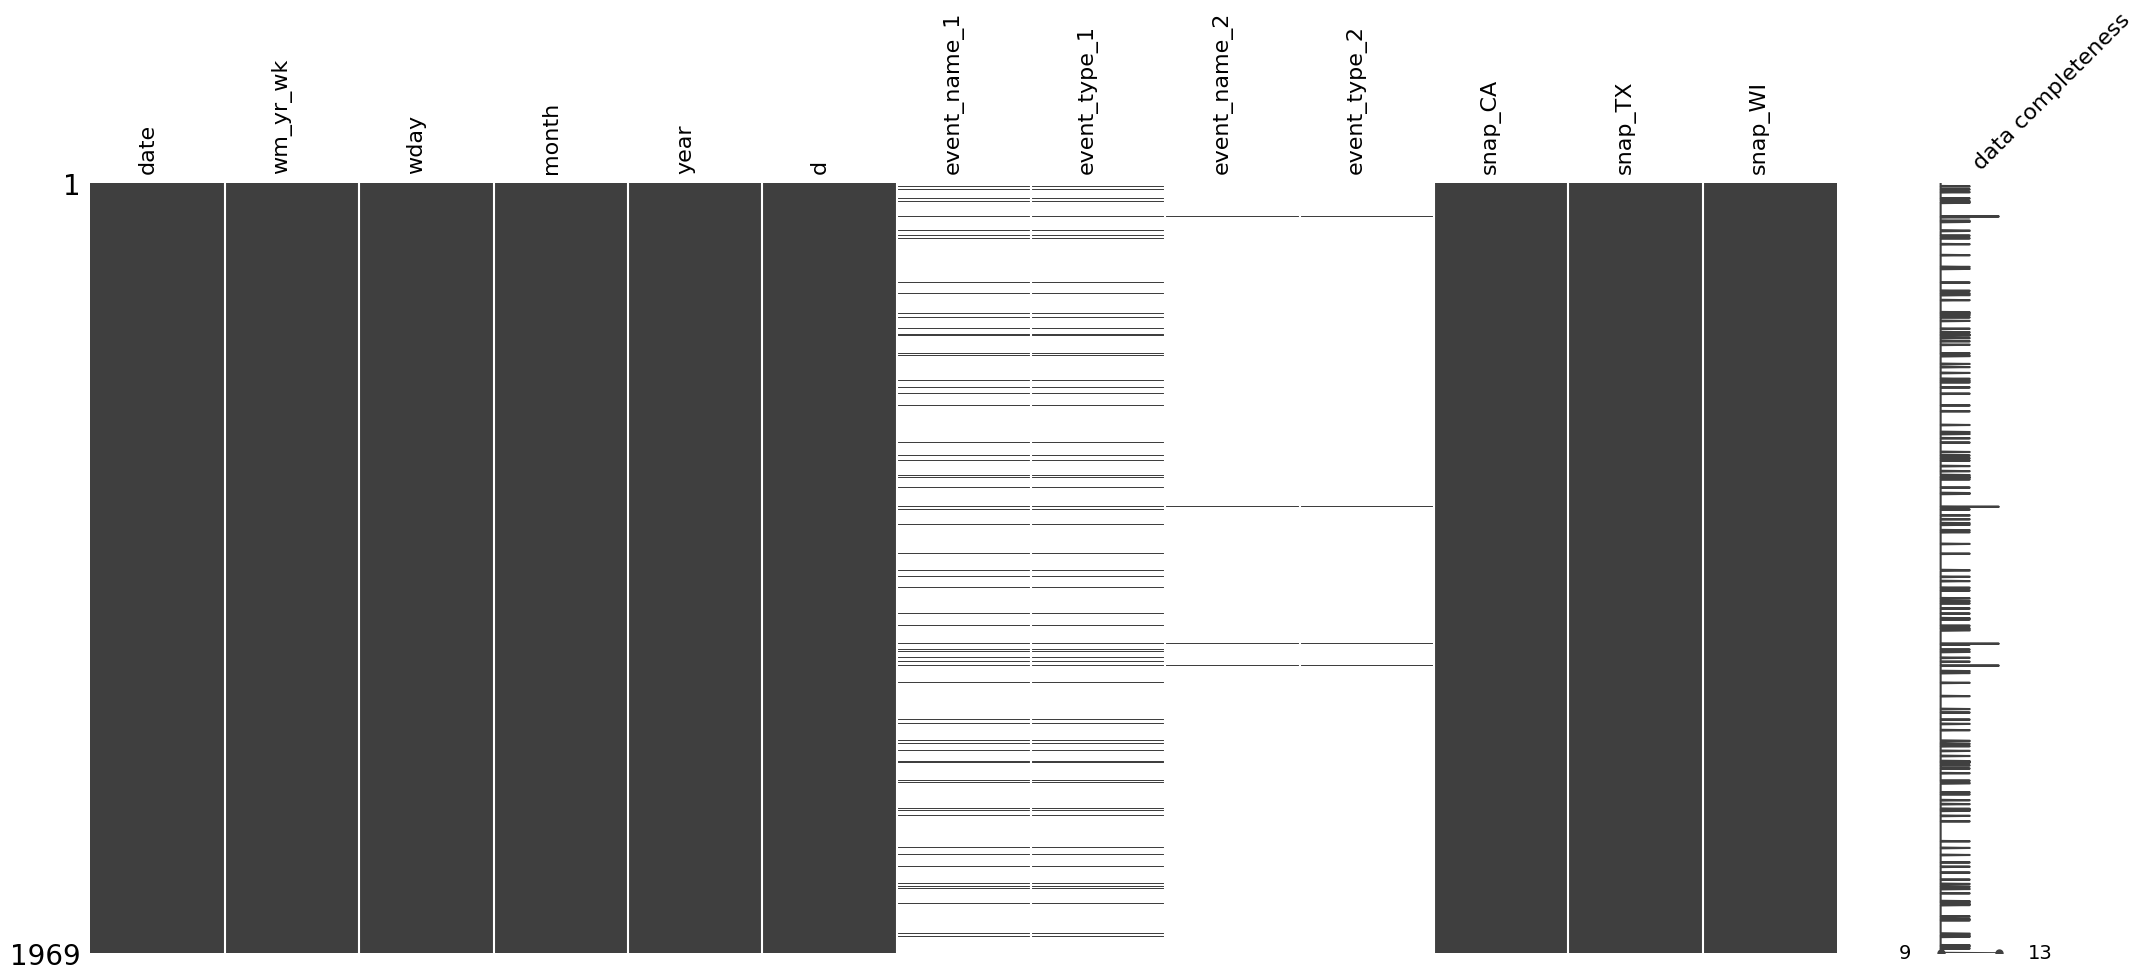

In [ ]:
# смотрим структуру пропусков
pass_miss(calendar,'calendar')

Исходя из графика и ранее увиденного списка уникальных события подверждается, что пропуски - это отсутствие событий. И становится понятно, что "дополнительные" столбцы для событий появились потому что на некоторые дни приходилось целых два события. То есть потенциально пропуски можно заполнить значениями "нет событий", и ввести дополнительно признак по количеству событий в день (0-2).

Пока выведу строку с событием второго типа.

In [ ]:
# вывожу строки без пропусков во втором событии
calendar[calendar['event_name_2'].notna()]

,date,wm_yr_wk,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
85,2011-04-24,11113,2,4,2011,d_86,OrthodoxEaster,Religious,Easter,Cultural,0,0,0
827,2013-05-05,11315,2,5,2013,d_828,OrthodoxEaster,Religious,Cinco De Mayo,Cultural,1,1,1
1177,2014-04-20,11412,2,4,2014,d_1178,Easter,Cultural,OrthodoxEaster,Religious,0,0,0
1233,2014-06-15,11420,2,6,2014,d_1234,NBAFinalsEnd,Sporting,Father's day,Cultural,0,1,1
1968,2016-06-19,11621,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


Здесь видно, что праздники 'OrthodoxEaster' и 'Easter' дублируют друг друга, и могли попасть либо в event_1, либо event_2, причем первая бьется как Religious, а вторая как Cultural.

Посмотрю Пасхи чуть подробнее.

In [ ]:
# вывожу столбцы с Пасхами
calendar[calendar['event_name_1'].isin(['Easter', 'OrthodoxEaster'])]

,date,wm_yr_wk,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
85,2011-04-24,11113,2,4,2011,d_86,OrthodoxEaster,Religious,Easter,Cultural,0,0,0
435,2012-04-08,11211,2,4,2012,d_436,Easter,Cultural,NaN,NaN,1,0,1
442,2012-04-15,11212,2,4,2012,d_443,OrthodoxEaster,Religious,NaN,NaN,0,1,1
792,2013-03-31,11310,2,3,2013,d_793,Easter,Cultural,NaN,NaN,0,0,0
827,2013-05-05,11315,2,5,2013,d_828,OrthodoxEaster,Religious,Cinco De Mayo,Cultural,1,1,1
1177,2014-04-20,11412,2,4,2014,d_1178,Easter,Cultural,OrthodoxEaster,Religious,0,0,0
1527,2015-04-05,11510,2,4,2015,d_1528,Easter,Cultural,NaN,NaN,1,1,1
1534,2015-04-12,11511,2,4,2015,d_1535,OrthodoxEaster,Religious,NaN,NaN,0,1,1
1884,2016-03-27,11609,2,3,2016,d_1885,Easter,Cultural,NaN,NaN,0,0,0
1919,2016-05-01,11614,2,5,2016,d_1920,OrthodoxEaster,Religious,NaN,NaN,1,1,0


Видимо, во второй столбец попадала православная Пасха, если не совпадала с католической. Вероятно, подобная же ситуация и остальными праздниками.

In [ ]:
# посмотрю на распространенность праздников и их типов
# с группировкой, без сброса индекса (для наглядности групп)
# первый тип
print(color.BLUE + color.BOLD + f"Группировка событий 1 по типам:" + color.END)
display(calendar.groupby(['event_type_1', 'event_name_1']).size())

# второй тип
print(color.BLUE + color.BOLD + f"\nГруппировка событий 2 по типам:" + color.END)
display(calendar.groupby(['event_type_2', 'event_name_2']).size())

Группировка событий 1 по типам:


event_type_1  event_name_1       
Cultural      Cinco De Mayo          5
              Easter                 5
              Father's day           4
              Halloween              5
              Mother's day           6
              StPatricksDay          6
              ValentinesDay          6
National      Christmas              5
              ColumbusDay            5
              IndependenceDay        5
              LaborDay               5
              MartinLutherKingDay    5
              MemorialDay            6
              NewYear                5
              PresidentsDay          6
              Thanksgiving           5
              VeteransDay            5
Religious     Chanukah End           5
              Eid al-Fitr            5
              EidAlAdha              5
              LentStart              6
              LentWeek2              6
              OrthodoxChristmas      5
              OrthodoxEaster         5
              Pesach End             6
              Purim End              6
              Ramadan starts         6
Sporting      NBAFinalsEnd           6
              NBAFinalsStart         6
              SuperBowl              6
dtype: int64


Группировка событий 2 по типам:


event_type_2  event_name_2  
Cultural      Cinco De Mayo     1
              Easter            1
              Father's day      2
Religious     OrthodoxEaster    1
dtype: int64

Видно, что праздники из разных культур и религий, и каждое мероприятие входили по 5-6 раз (но за счет совпадения дат могли попасть в разные столбцы, системы определения который в какой не имеется, как видно по тем же Пасхам).

Идеально было бы сделать бинарное кодирование для празничных признаков, но это приведет к росту данных, но не факт, что качество предсказаний за счет этого вырастет, а вот требования к вычислительным мощностям точно возрастет.

Поэтому пока создам агрегированный признак "количество событий" со значениями от 0 до 2.

In [ ]:
# создаю агрегированный признак
calendar['n_events'] = calendar['event_name_1'].notna().astype(int) + calendar['event_name_2'].notna().astype(int)

Также на всякий случай взгляну, внесены ли в календарь будущих 28 дней праздники.

In [ ]:
# проверка праздников
calendar.tail(28)

,date,wm_yr_wk,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,n_events
1941,2016-05-23,11617,3,5,2016,d_1942,NaN,NaN,NaN,NaN,0,0,0,0
1942,2016-05-24,11617,4,5,2016,d_1943,NaN,NaN,NaN,NaN,0,0,0,0
1943,2016-05-25,11617,5,5,2016,d_1944,NaN,NaN,NaN,NaN,0,0,0,0
1944,2016-05-26,11617,6,5,2016,d_1945,NaN,NaN,NaN,NaN,0,0,0,0
1945,2016-05-27,11617,7,5,2016,d_1946,NaN,NaN,NaN,NaN,0,0,0,0
1946,2016-05-28,11618,1,5,2016,d_1947,NaN,NaN,NaN,NaN,0,0,0,0
1947,2016-05-29,11618,2,5,2016,d_1948,NaN,NaN,NaN,NaN,0,0,0,0
1948,2016-05-30,11618,3,5,2016,d_1949,MemorialDay,National,NaN,NaN,0,0,0,1
1949,2016-05-31,11618,4,5,2016,d_1950,NaN,NaN,NaN,NaN,0,0,0,0
1950,2016-06-01,11618,5,6,2016,d_1951,NaN,NaN,NaN,NaN,1,1,0,0


События и snap заполнены.

Теперь создам столбцы на основе исходных событий, вынеся совпадавшие праздники так, чтобы все их значения приходились лишь на один столбец избегая путаницы (то есть, например, православная Пасха отмечалась только в первом столбце, а католическая - только во втором). В процессе попытаюсь использовать некоторую систему, чтобы сократить количество вариантов будущих категорий в рамках одного столбца.

В текущем варианте удобнее будет собрать все культурные мероприятия в столбец 2 (сейчас этот тип там преобладает), чтобы сократить количество имен первых событий, и упразднить столбец с типом вторых событий.

*Примечание: Возможно, стоило перенести каждый тип событий в свой отдельный столбец и удалить типы, получив 4 name, а не только отделить культурные. Но так как данная идея пришла ко мне уже после завершения работы над проектом, проводить данный эксперимент я не стала. Но, вероятно, она могла бы улучшить качество предсказаний, снизив количества вариантов на признак, а общее количество признаков увеличилось бы лишь на один.*

In [ ]:
# перераспределяю события
# 1. Создаём пустые адаптированные столбцы
calendar[['event_name_1_adapt', 'event_type_1_adapt', 'event_name_2_adapt', 'event_type_2_adapt']] = None

# 2. Определяем, какие типы событий считаются культурными
cultural_types = ['Cultural']

# 3. Копируем все события из event_1 в event_1_adapt (кроме культурных)
mask_rest_1 = (
    calendar['event_name_1'].notna() &
    ~calendar['event_type_1'].isin(cultural_types)
)
calendar.loc[mask_rest_1, 'event_name_1_adapt'] = calendar.loc[mask_rest_1, 'event_name_1']
calendar.loc[mask_rest_1, 'event_type_1_adapt'] = calendar.loc[mask_rest_1, 'event_type_1']

# 4. Копируем все события из event_2 в event_1_adapt (кроме культурных)
mask_rest_2 = (
    calendar['event_name_2'].notna() &
    ~calendar['event_type_2'].isin(cultural_types)
)
calendar.loc[mask_rest_2, 'event_name_1_adapt'] = calendar.loc[mask_rest_2, 'event_name_2']
calendar.loc[mask_rest_2, 'event_type_1_adapt'] = calendar.loc[mask_rest_2, 'event_type_2']

# 5. Все культурные события из event_1 → event_2_adapt
mask_cultural_1 = calendar['event_type_1'].isin(cultural_types) & calendar['event_name_1'].notna()
calendar.loc[mask_cultural_1, 'event_name_2_adapt'] = calendar.loc[mask_cultural_1, 'event_name_1']
calendar.loc[mask_cultural_1, 'event_type_2_adapt'] = calendar.loc[mask_cultural_1, 'event_type_1']

# 6. Все культурные события из event_2 → event_2_adapt
mask_cultural_2 = calendar['event_type_2'].isin(cultural_types) & calendar['event_name_2'].notna()
calendar.loc[mask_cultural_2, 'event_name_2_adapt'] = calendar.loc[mask_cultural_2, 'event_name_2']
calendar.loc[mask_cultural_2, 'event_type_2_adapt'] = calendar.loc[mask_cultural_2, 'event_type_2']

# 7. Проверка
print(color.BLUE + color.BOLD + f"=== Проверка распределения ===\n" + color.END)

# Смотрим, какие события переехали в event_2_adapt
cultural_in_2 = calendar[calendar['event_type_2_adapt'].isin(cultural_types)]
print(color.BLUE + color.BOLD + f"Культурные события в event_2_adapt:"+ color.END)
display(cultural_in_2[['event_name_2_adapt', 'event_type_2_adapt']].drop_duplicates())

# Смотрим, сколько осталось культурных в event_1_adapt (должно быть 0)
cultural_in_1 = calendar[calendar['event_type_1_adapt'].isin(cultural_types)]
print(color.BLUE + color.BOLD + f"Культурных событий в event_1_adapt (должно быть 0): "+ color.END + f"{len(cultural_in_1)}")

# Общее количество событий в каждом адаптированном столбце
print(f"Всего событий в event_1_adapt: {calendar['event_name_1_adapt'].notna().sum()}")
print(f"Всего событий в event_2_adapt: {calendar['event_name_2_adapt'].notna().sum()}")

=== Проверка распределения ===

Культурные события в event_2_adapt:


,event_name_2_adapt,event_type_2_adapt
16,ValentinesDay,Cultural
47,StPatricksDay,Cultural
85,Easter,Cultural
96,Cinco De Mayo,Cultural
99,Mother's day,Cultural
141,Father's day,Cultural
275,Halloween,Cultural


Культурных событий в event_1_adapt (должно быть 0): 0
Всего событий в event_1_adapt: 126
Всего событий в event_2_adapt: 41


In [ ]:
# проверяю результат
# вывожу строки без пропусков во втором событии
calendar[calendar['event_name_2'].notna()]

,date,wm_yr_wk,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,n_events,event_name_1_adapt,event_type_1_adapt,event_name_2_adapt,event_type_2_adapt
85,2011-04-24,11113,2,4,2011,d_86,OrthodoxEaster,Religious,Easter,Cultural,0,0,0,2,OrthodoxEaster,Religious,Easter,Cultural
827,2013-05-05,11315,2,5,2013,d_828,OrthodoxEaster,Religious,Cinco De Mayo,Cultural,1,1,1,2,OrthodoxEaster,Religious,Cinco De Mayo,Cultural
1177,2014-04-20,11412,2,4,2014,d_1178,Easter,Cultural,OrthodoxEaster,Religious,0,0,0,2,OrthodoxEaster,Religious,Easter,Cultural
1233,2014-06-15,11420,2,6,2014,d_1234,NBAFinalsEnd,Sporting,Father's day,Cultural,0,1,1,2,NBAFinalsEnd,Sporting,Father's day,Cultural
1968,2016-06-19,11621,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0,2,NBAFinalsEnd,Sporting,Father's day,Cultural


Теперь, после перестановки, праздники должны несколько упорядочиться, перестав попадать в разные столбцы. И теперь для второго столбца останется лишь один тип событий, а значит можно будет избавиться от этого столбца в будущем.

Проверю еще раз распределение событий в новых столбцах.

In [ ]:
# посмотрю на распространенность праздников и их типов
# с группировкой, без сброса индекса (для наглядности групп)
# первый тип
print(color.BLUE + color.BOLD + f"Группировка событий 1 (adapt) по типам:" + color.END)
display(calendar.groupby(['event_type_1_adapt', 'event_name_1_adapt']).size())

# второй тип
print(color.BLUE + color.BOLD + f"\nГруппировка событий 2 (adapt) по типам:" + color.END)
display(calendar.groupby(['event_type_2_adapt', 'event_name_2_adapt']).size())

Группировка событий 1 (adapt) по типам:


event_type_1_adapt  event_name_1_adapt 
National            Christmas              5
                    ColumbusDay            5
                    IndependenceDay        5
                    LaborDay               5
                    MartinLutherKingDay    5
                    MemorialDay            6
                    NewYear                5
                    PresidentsDay          6
                    Thanksgiving           5
                    VeteransDay            5
Religious           Chanukah End           5
                    Eid al-Fitr            5
                    EidAlAdha              5
                    LentStart              6
                    LentWeek2              6
                    OrthodoxChristmas      5
                    OrthodoxEaster         6
                    Pesach End             6
                    Purim End              6
                    Ramadan starts         6
Sporting            NBAFinalsEnd           6
                    NBAFinalsStart         6
                    SuperBowl              6
dtype: int64


Группировка событий 2 (adapt) по типам:


event_type_2_adapt  event_name_2_adapt
Cultural            Cinco De Mayo         6
                    Easter                6
                    Father's day          6
                    Halloween             5
                    Mother's day          6
                    StPatricksDay         6
                    ValentinesDay         6
dtype: int64

Перенос произошел корректно, а вариант типа события у обновленного второго столбца событий лишь один (культурный), а потому этот столбец можно будет удалить.

Также можно будет удалить и исходные столбцы в будущем.

Дополнительно можно заметить, что спортивных событий - меньшинство.

Заполню пропуски в столбцах с событиями и их типами, а также преобразую их тип данных в категорию и визуализирую получившийся результат.

In [ ]:
# Создаю список обрабатываемых столбцов
ch_col = ['event_name_1_adapt', 'event_type_1_adapt', 'event_name_2_adapt', 'event_type_2_adapt']

# Заполняю пропуски и сразу преобразую в категорию
calendar[ch_col] = calendar[ch_col].fillna('None').astype('category')

Найдено типов событий признаков: 2
Признаки: ['event_type_1_adapt', 'event_type_2_adapt']


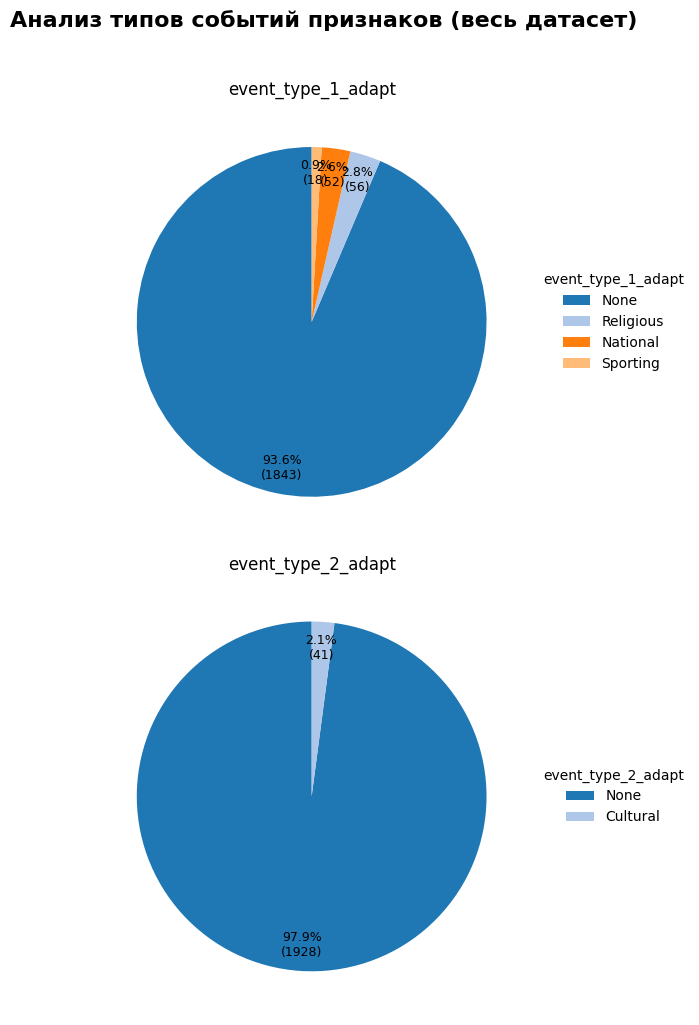

In [ ]:
# Визуализация
plot_categorical_pie_charts_up(calendar, categorical_columns=['event_type_1_adapt', 'event_type_2_adapt'], plot_type="типов событий")

Здесь еще раз более наглядно заметно, что большинство дней - обычные. Среди же событий большинство у религиозных праздников.

Взгляну дополнительно на статистическое описание числовых данных (что-то из этого уже наблюдалось ранее).

In [ ]:
# статистическое описание
# можно было бы не делать, учитывая характер данных, но наблюдения нужны для будущего
# плюс дополнительно убедиться, что нет ошибок в календарных признаках
# тем более, что в будущем будем преобразовывать int
calendar.describe()

,date,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI,n_events
count,1969,1969.00,1969.00,1969.00,1969.00,1969.00,1969.00,1969.00,1969.00
mean,2013-10-09 00:00:00,11347.09,4.00,6.33,2013.29,0.33,0.33,0.33,0.08
min,2011-01-29 00:00:00,11101.00,1.00,1.00,2011.00,0.00,0.00,0.00,0.00
25%,2012-06-04 00:00:00,11219.00,2.00,3.00,2012.00,0.00,0.00,0.00,0.00
50%,2013-10-09 00:00:00,11337.00,4.00,6.00,2013.00,0.00,0.00,0.00,0.00
75%,2015-02-13 00:00:00,11502.00,6.00,9.00,2015.00,1.00,1.00,1.00,0.00
max,2016-06-19 00:00:00,11621.00,7.00,12.00,2016.00,1.00,1.00,1.00,2.00
std,NaN,155.28,2.00,3.42,1.58,0.47,0.47,0.47,0.29


Здесь можно наблюдать, что 11 - в начале wm_yr_wk - это не конкретно год, а видимо метка, что отсчет наблюдения ведется с 11 года.

Месяцы, дни и недели выглядят логично.

Взгляну на распределение соцпрограммы.

Найдено бинарных признаков: 3
Признаки: ['snap_CA', 'snap_TX', 'snap_WI']


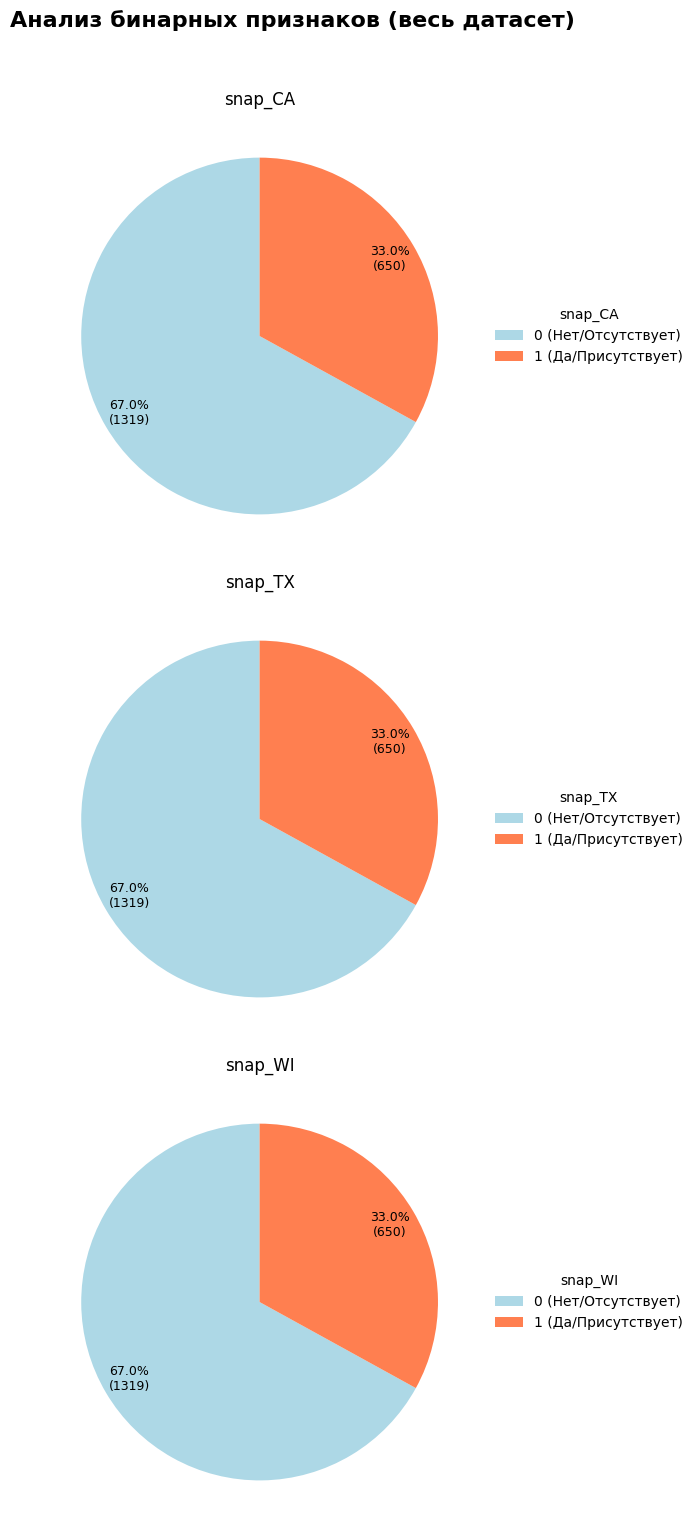

In [ ]:
# Визуализация соцпрограммы
plot_categorical_pie_charts_up(calendar, categorical_columns=['snap_CA', 'snap_TX', 'snap_WI'], plot_type="бинарных")

Можно наблюдать что во всех трех имеющихся в данных штатах одинаковое соотношение дней действия snap (может это закон или политика компании) хоть и действует она иногда в разные дни.

#### **Дополнительная обработка**

Можно было бы удалить признак с точной датой, так как все полезное из нее уже получено, а для отслеживания ряда есть дни по-порядку. Тем более, что декомпозировать же временные ряды ввиду их большого количества корректно не выйдет. Однако дата нужна будет еще для сопоставления диапазона данных в будущем, поэтому удалю ее позже.

А сейчас можно удалить год, так как он тоже не несет информации для будущего (для отслеживания используются дни), и не требуется для агрегирования (признак же с неделей наблюдения также будет удален в будущем).

In [ ]:
# Удаляем year из calendar
calendar = calendar.drop('year', axis=1)

Также удалю исходные признаки событий и тип события для обновленного второго списка событий.

In [ ]:
# Удаляем лишние данные по событиям из calendar
calendar = calendar.drop(['event_name_1', 'event_type_1','event_name_2', 'event_type_2', 'event_type_2_adapt'], axis=1)

In [ ]:
# промежуточная проверка
calendar.columns

Index(['date', 'wm_yr_wk', 'wday', 'month', 'd', 'snap_CA', 'snap_TX',
       'snap_WI', 'n_events', 'event_name_1_adapt', 'event_type_1_adapt',
       'event_name_2_adapt'],
      dtype='object')

In [ ]:
# меняю порядок столбцов для удобства
calendar = calendar[['date', 'wm_yr_wk', 'wday', 'month', 'd', 'n_events',
                     'event_name_1_adapt', 'event_type_1_adapt',
                     'event_name_2_adapt', 'snap_CA', 'snap_TX', 'snap_WI']]
# промежуточная проверка
calendar.head()

,date,wm_yr_wk,wday,month,d,n_events,event_name_1_adapt,event_type_1_adapt,event_name_2_adapt,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,1,1,d_1,0,None,None,None,0,0,0
1,2011-01-30,11101,2,1,d_2,0,None,None,None,0,0,0
2,2011-01-31,11101,3,1,d_3,0,None,None,None,0,0,0
3,2011-02-01,11101,4,2,d_4,0,None,None,None,1,1,0
4,2011-02-02,11101,5,2,d_5,0,None,None,None,1,0,1


Также можно преобразовать типы данных у признаков snap_x в bool для уменьшения памяти, хотя в обычном случае это не требуется,ведь что на скорость работы с моделью преобразование практически не повлияет.

Но так как датасет получается на выходе потенциально очень большой, то все же преобразую для еще большей экономии ОЗУ в будущем.

In [ ]:
# Используем bool - потенциально экономит память и работает быстро
ch_col = ['snap_CA', 'snap_TX', 'snap_WI']
calendar[ch_col] = calendar[ch_col].astype(bool)

Также оптимизирую содержимое в столбце `'d'`, чтобы превратить его из object в int также для экономии памяти.

In [ ]:
# преобразуем 'd' из 'd_n' в число и меняем тип
calendar['d'] = calendar['d'].str.replace('d_', '').astype(int)

И оптимизирую типы данных у оставшихся int, превратив их в uint (так как значения у нас только положительные) меньшей разрядности (чтобы занимали меньше места).

In [ ]:
# uint8 - хранимый диапазон от 0 до 255, место 1 байт
# wday (1-7), month (1-12), n_events (0-2) → uint8
calendar[['wday', 'month', 'n_events']] = calendar[['wday', 'month', 'n_events']].astype('uint8')

# uint16 - хранимый диапазон от 0 до 65,535, место 2 байта
# wm_yr_wk (11101-11621), d (1-1969) → uint16
calendar['wm_yr_wk'] = calendar['wm_yr_wk'].astype('uint16')
calendar['d'] = calendar['d'].astype('uint16')

In [ ]:
# проверяем результаты
# вызов функции discr_num и ее вывод
first_discr(calendar,'calendar', 15)


 === Первые 15 строк в calendar: ===



,date,wm_yr_wk,wday,month,d,n_events,event_name_1_adapt,event_type_1_adapt,event_name_2_adapt,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,1,1,1,0,None,None,None,False,False,False
1,2011-01-30,11101,2,1,2,0,None,None,None,False,False,False
2,2011-01-31,11101,3,1,3,0,None,None,None,False,False,False
3,2011-02-01,11101,4,2,4,0,None,None,None,True,True,False
4,2011-02-02,11101,5,2,5,0,None,None,None,True,False,True
5,2011-02-03,11101,6,2,6,0,None,None,None,True,True,True
6,2011-02-04,11101,7,2,7,0,None,None,None,True,False,False
7,2011-02-05,11102,1,2,8,0,None,None,None,True,True,True
8,2011-02-06,11102,2,2,9,1,SuperBowl,Sporting,None,True,True,True
9,2011-02-07,11102,3,2,10,0,None,None,None,True,True,False



 === Общая информация о данных в calendar: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                1969 non-null   datetime64[ns]
 1   wm_yr_wk            1969 non-null   uint16        
 2   wday                1969 non-null   uint8         
 3   month               1969 non-null   uint8         
 4   d                   1969 non-null   uint16        
 5   n_events            1969 non-null   uint8         
 6   event_name_1_adapt  1969 non-null   category      
 7   event_type_1_adapt  1969 non-null   category      
 8   event_name_2_adapt  1969 non-null   category      
 9   snap_CA             1969 non-null   bool          
 10  snap_TX             1969 non-null   bool          
 11  snap_WI             1969 non-null   bool          
dtypes: bool(3), category(3), datetime64[ns](1), uint16(2), 

None


 === Размер датасета calendar:===
    (1969, 12)


 === Явные дубликаты в calendar:===
Количество: 0
Процент: 0.00 %


Размер датасета заметно уменьшился относительно исходного 215.5+ KB.

### `'sell_prices'`

#### **Анализ данных**

In [ ]:
# применение функции уникальных значений
count_unique_values_upd(sell_prices[['item_id','store_id']], max_examples=10)

Уникальные значения по столбцам:

Столбец: item_id
Тип данных: object
Количество уникальных значений: 3049
Пропуски: нет
Примеры уникальных значений:
  1. HOBBIES_1_001
  2. HOBBIES_1_002
  3. HOBBIES_1_003
  4. HOBBIES_1_004
  5. HOBBIES_1_005
  6. HOBBIES_1_006
  7. HOBBIES_1_007
  8. HOBBIES_1_008
  9. HOBBIES_1_009
  10. HOBBIES_1_010

Столбец: store_id
Тип данных: object
Количество уникальных значений: 10
Пропуски: нет
Примеры уникальных значений:
  1. CA_1
  2. CA_2
  3. CA_3
  4. CA_4
  5. TX_1
  6. TX_2
  7. TX_3
  8. WI_1
  9. WI_2
  10. WI_3


Магазины наблюдаются те же, товары потенциально те же.

Посмотрю на периоды, а также на возможность сопоставления с остальными датасетами.

In [ ]:
# сравниваю периоды
print(color.BLUE + color.BOLD + f"ВРЕМЕННОЙ ПРОМЕЖУТОК В calendar" + color.END)
# первая неделя
print(color.BLUE + color.BOLD + f"\n===== Первая неделя: ===== " + color.END)
display(calendar[['date', 'd', 'wm_yr_wk']].head(1))
print(color.BLUE + color.BOLD + f"совпадает с sell_prices:" + color.END)
display(sell_prices['wm_yr_wk'].min() == calendar[['date', 'd', 'wm_yr_wk']]['wm_yr_wk'].head(1))

# последняя неделя
print(color.BLUE + color.BOLD + f"\n=====  Последняя неделя: ===== " + color.END)
display(calendar[['date', 'd', 'wm_yr_wk']].tail(1))
print(color.BLUE + color.BOLD + f"\nсовпадает с sell_prices:" + color.END)
display(sell_prices['wm_yr_wk'].max() == calendar[['date', 'd', 'wm_yr_wk']]['wm_yr_wk'].tail(1))

ВРЕМЕННОЙ ПРОМЕЖУТОК В calendar

===== Первая неделя: ===== 


,date,d,wm_yr_wk
0,2011-01-29,1,11101


совпадает с sell_prices:


,wm_yr_wk
0,True



=====  Последняя неделя: ===== 


,date,d,wm_yr_wk
1968,2016-06-19,1969,11621



совпадает с sell_prices:


,wm_yr_wk
1968,True


Цены также имеются для будущего периода, а сам период сопоставим с таковым в календаре.

Товаров и цен имеется много, но попробую все же взглянуть на статистическое описание цен. Это позволит в будущем подобрать более оптимальный тип данных для соответствующего столбца.

Найдено числовых признаков: 1
Признаки: ['sell_price']


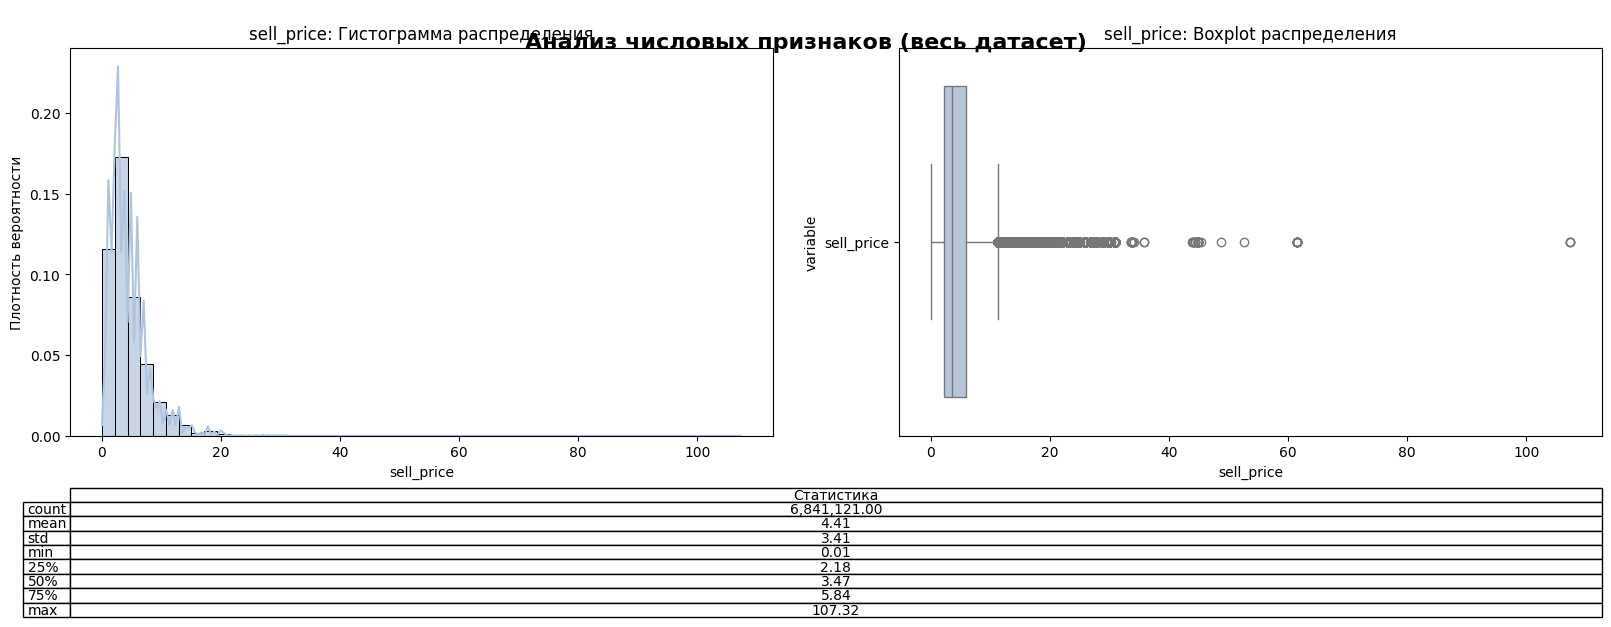

In [ ]:
# Визуализация
# если не отключать (в самом начале) научную нотацию чисел, результат будет через e
# чего не требуется в данном проекте, так как цены не могут быть мельче 1 цента
visualize_numeric_auto(sell_prices[['sell_price']])

В выборке очень много недорогих товаров: большая их часть дешевле 6 долларов.

Но также есть и выбросы. Возможно, ошибкой является самая яркая аномалия, поэтому взгляну на нее поближе.

In [ ]:
# считаем товары дороже 60
print(color.BLUE + color.BOLD + f"Количество товаров дороже 60 долларов: "
+ color.END +f"{len(sell_prices[sell_prices['sell_price'] >= 60])}")

print(color.BLUE + color.BOLD +f"Процент: "+ color.END +
      f"{len(sell_prices[sell_prices['sell_price'] >= 60])/len(sell_prices)*100:.5f} %")

Количество товаров дороже 60 долларов: 16
Процент: 0.00023 %


In [ ]:
# выводим товары 60 и выше
print(color.BLUE + color.BOLD + f"=== Товары с ценой продажи 60 долларов и выше ==="+ color.END)
sell_prices[sell_prices['sell_price'] >= 60]

=== Товары с ценой продажи 60 долларов и выше ===


,store_id,item_id,wm_yr_wk,sell_price
5805271,WI_2,HOUSEHOLD_2_406,11237,61.46
5805272,WI_2,HOUSEHOLD_2_406,11238,61.46
5805273,WI_2,HOUSEHOLD_2_406,11239,61.46
5805274,WI_2,HOUSEHOLD_2_406,11240,61.46
5805275,WI_2,HOUSEHOLD_2_406,11241,61.46
5805276,WI_2,HOUSEHOLD_2_406,11242,61.46
5805277,WI_2,HOUSEHOLD_2_406,11243,61.46
5805278,WI_2,HOUSEHOLD_2_406,11244,61.46
5805279,WI_2,HOUSEHOLD_2_406,11245,61.46
5805280,WI_2,HOUSEHOLD_2_406,11246,61.46


Аномальным является один и тот же товар, в двух магазинах, в разные периоды, причем в WI_2 в свой период он был дешевле, как будто акция. Но теперь видно, что цена - настоящая.

На всякий случай взглянем, а был ли он в наличие в остальных магазинах в принципе?

In [ ]:
# проверяем, везде ли он был в продаже
print(color.BLUE + color.BOLD + f"Список магазинов, в которых продавался данный товар:" + color.END)
sell_prices[sell_prices['item_id'] == 'HOUSEHOLD_2_406']['store_id'].unique()

Список магазинов, в которых продавался данный товар:


array(['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1',
       'WI_2', 'WI_3'], dtype=object)

Да, данный товар появлялся в продаже во всех магазинах в наблюдаемый период, но там его цена по каким-то причинам была меньше.

Также попробуем узнать, для всех ли товаров всегда есть цена.

In [ ]:
# Берём товар и магазин, для которых нет цены
# данная позиция всплыла дальше, поэтому использую ее тут как образец
item = 'FOODS_1_004'
store = 'CA_1'
week = 11101 # первая неделя наблюдений

# 1. Проверяем, есть ли цена в sell_prices
price = sell_prices[
    (sell_prices['item_id'] == item) &
    (sell_prices['store_id'] == store) &
    (sell_prices['wm_yr_wk'] == week)
]

print(color.BLUE + color.BOLD + f"Цена для {item}, {store}, неделя {week}:"+ color.END)
display(price)

# 2. Проверяем, есть ли этот товар в sell_prices вообще
all_prices = sell_prices[sell_prices['item_id'] == item]
print(color.BLUE + color.BOLD + f"\nВсе цены для {item}:" + color.END)
display(all_prices[['item_id', 'store_id', 'wm_yr_wk', 'sell_price']].head(10))

# 3. Проверяем, есть ли этот товар в sales_train_eval
sales_item = sales_train_eval[sales_train_eval['item_id'] == item]
print(color.BLUE + color.BOLD + f"\nТовар {item} в sales_train_eval: {len(sales_item)} записей"+ color.END)
# d_1 и d_7 соответствут первому и последнему дням первой недели наблюдения
display(sales_item[['id', 'item_id', 'store_id', 'd_1', 'd_7']].head())

Цена для FOODS_1_004, CA_1, неделя 11101:


,store_id,item_id,wm_yr_wk,sell_price



Все цены для FOODS_1_004:


,item_id,store_id,wm_yr_wk,sell_price
369592,FOODS_1_004,CA_1,11206,1.78
369593,FOODS_1_004,CA_1,11207,1.78
369594,FOODS_1_004,CA_1,11208,1.78
369595,FOODS_1_004,CA_1,11209,1.78
369596,FOODS_1_004,CA_1,11210,1.78
369597,FOODS_1_004,CA_1,11211,1.78
369598,FOODS_1_004,CA_1,11212,1.78
369599,FOODS_1_004,CA_1,11213,1.78
369600,FOODS_1_004,CA_1,11214,1.78
369601,FOODS_1_004,CA_1,11215,1.78



Товар FOODS_1_004 в sales_train_eval: 10 записей


,id,item_id,store_id,d_1,d_7
1615,FOODS_1_004_CA_1_evaluation,FOODS_1_004,CA_1,0,0
4664,FOODS_1_004_CA_2_evaluation,FOODS_1_004,CA_2,0,0
7713,FOODS_1_004_CA_3_evaluation,FOODS_1_004,CA_3,0,0
10762,FOODS_1_004_CA_4_evaluation,FOODS_1_004,CA_4,0,0
13811,FOODS_1_004_TX_1_evaluation,FOODS_1_004,TX_1,0,0


Видно, что цены присутствуют не на все товары и не всегда. Например, данный товар отсутствовал в продаже как минимум в первую неделю наблюдения.

То есть в агрегированных данных будут пропуски и это нормально. Но стоит учесть при выборе модели.

#### **Дополнительная обработка**

Также поработаю с типами столбцов для экономии памяти.

In [ ]:
# Преобразуем категориальные столбцы одной строкой
# для M5 преобразование item_id и id товаров является хорошей практикой
sell_prices[['store_id', 'item_id']] = sell_prices[['store_id', 'item_id']].astype('category')

In [ ]:
# float16 - хранимый диапазон от ~6.1 × 10⁻⁵ (0.000061)	до ~65,504,
# точность ~0.001 (3 знака), место 2 байта
# так как максимум цены чуть ниже 108 долларов, хватит и его, даже "на вырост"
sell_prices['sell_price'] = sell_prices['sell_price'].astype('float16')
# преобразую тип по аналогии с другим датасетом
sell_prices['wm_yr_wk'] = sell_prices['wm_yr_wk'].astype('uint16')

In [ ]:
# проверяю
# вызов описательной функции discr_num и ее вывод
first_discr(sell_prices,'sell_prices', 5)


 === Первые 5 строк в sell_prices: ===



,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26



 === Общая информация о данных в sell_prices: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype   
---  ------      -----   
 0   store_id    category
 1   item_id     category
 2   wm_yr_wk    uint16  
 3   sell_price  float16 
dtypes: category(2), float16(1), uint16(1)
memory usage: 45.8 MB


None


 === Размер датасета sell_prices:===
    (6841121, 4)


 === Явные дубликаты в sell_prices:===
Количество: 0
Процент: 0.00 %


Размер датасета также значительно относительно исходных 208.8+ MB.

### **`'sales_train_eval'`**

#### **Анализ данных**

Типы данных у него, как можно было увидеть ранее, соответствуют друг содержимому, "лишних" признаков потенциально не имеется (так как каждая часть иерархии как категоризации самого товара, так и магазина, в котором он продается, может вносить свой вклад в предсказание). Поэтому дополнительнеы преобразования не треьбуются.

Также можно посмотреть на уникальные значения и их распределение.

In [ ]:
# применение функции уникальных значений
count_unique_values_upd(sales_train_eval[['id','item_id','dept_id','cat_id','store_id','state_id']], max_examples=10)

Уникальные значения по столбцам:

Столбец: id
Тип данных: object
Количество уникальных значений: 30490
Пропуски: нет
Примеры уникальных значений:
  1. HOBBIES_1_001_CA_1_evaluation
  2. HOBBIES_1_002_CA_1_evaluation
  3. HOBBIES_1_003_CA_1_evaluation
  4. HOBBIES_1_004_CA_1_evaluation
  5. HOBBIES_1_005_CA_1_evaluation
  6. HOBBIES_1_006_CA_1_evaluation
  7. HOBBIES_1_007_CA_1_evaluation
  8. HOBBIES_1_008_CA_1_evaluation
  9. HOBBIES_1_009_CA_1_evaluation
  10. HOBBIES_1_010_CA_1_evaluation

Столбец: item_id
Тип данных: object
Количество уникальных значений: 3049
Пропуски: нет
Примеры уникальных значений:
  1. HOBBIES_1_001
  2. HOBBIES_1_002
  3. HOBBIES_1_003
  4. HOBBIES_1_004
  5. HOBBIES_1_005
  6. HOBBIES_1_006
  7. HOBBIES_1_007
  8. HOBBIES_1_008
  9. HOBBIES_1_009
  10. HOBBIES_1_010

Столбец: dept_id
Тип данных: object
Количество уникальных значений: 7
Пропуски: нет
Примеры уникальных значений:
  1. HOBBIES_1
  2. HOBBIES_2
  3. HOUSEHOLD_1
  4. HOUSEHOLD_2
  5. FOODS_1
  6.

Еще раз виден составной характер идентификатора товара. Верхних категорий всего три, а вот подкатегорий нескольких уровней - гораздо больше.

В данных имеются три штата (что совпадает с описанием), и всего 10 магазинов.

То есть товар предсказываются продажи не всего позиции, а еще и в разрезе конкретных магазинов, что согласуется с описанием.

Однако, ввиду большого размера датасета, возможно придется либо агрегировать товары по группам, либо предсказывать частями по магазинам/категориям или еще каким образом оптимизировать вычисления. Причем, подобное разбиение с построением отдельных  моделей потенциально может дать лучший результат по качеству, чем попытка создать одну универсальную.

Найдено категориальных признаков: 4
Признаки: ['dept_id', 'cat_id', 'store_id', 'state_id']


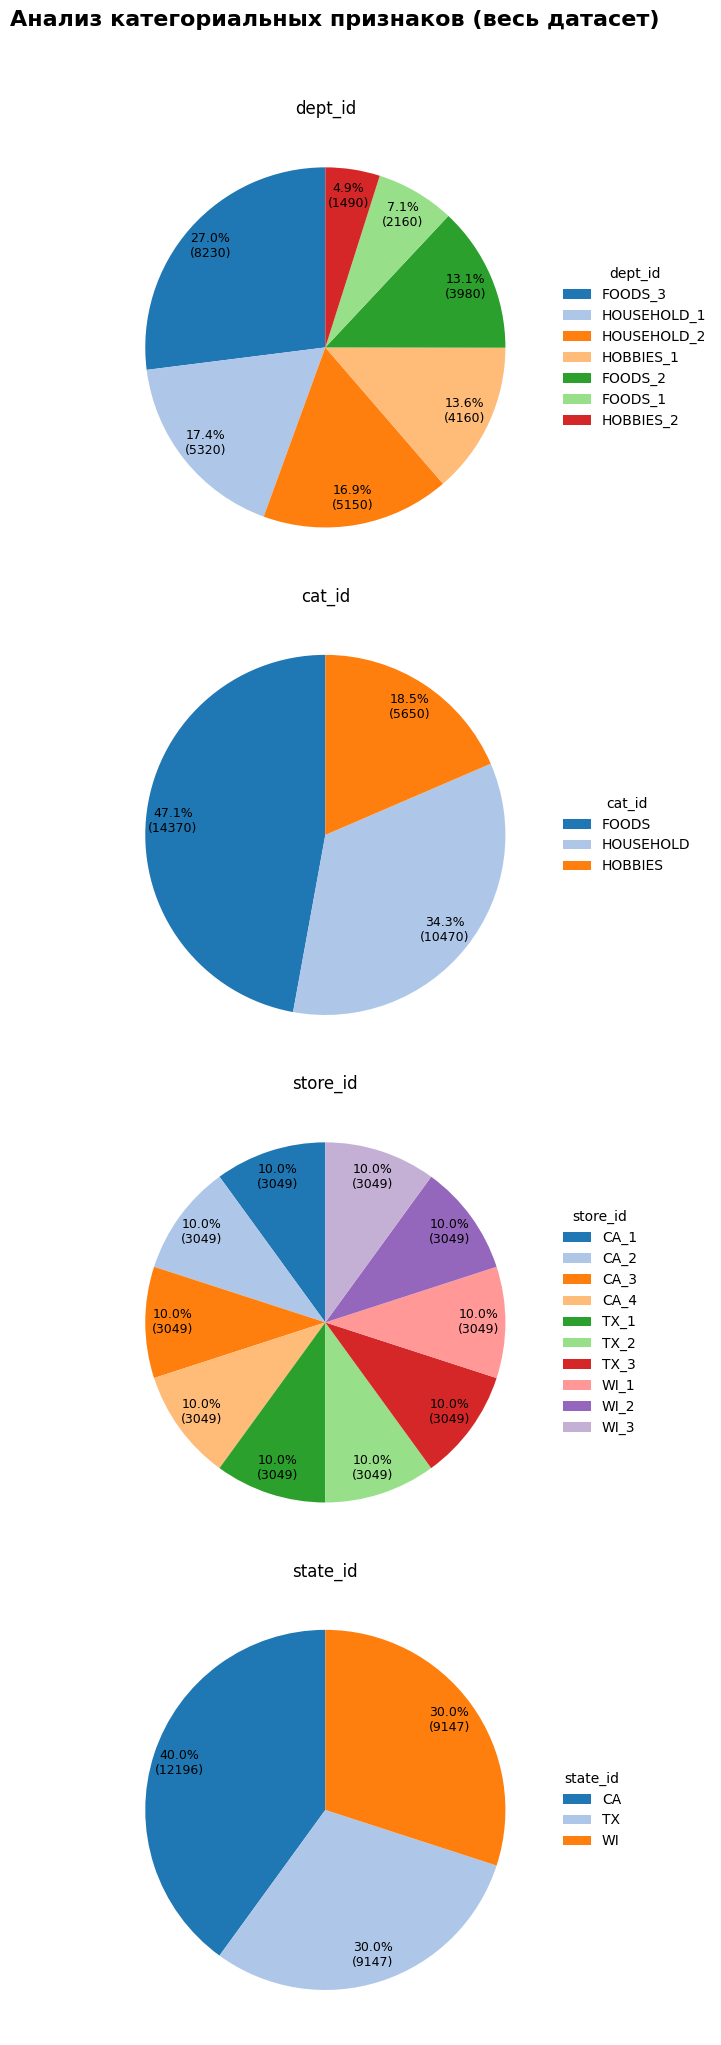

In [ ]:
# Визуализация категорий
plot_categorical_pie_charts_up(sales_train_eval, categorical_columns=['dept_id','cat_id','store_id','state_id'], plot_type="категориальных")

Еда, что логично - преобладает. Товары для хобби же уступают и товарам для дома, что также логично.

В рамках магазинов представленность товаров равномерная, а по штатам Калифорния превосходит на 10 процентов остальные, ввиду того, что там 4 магазина, а не 3, как у остальных штатов.

Ввиду большого количества столбцов посмотреть описательную статистику по дням будет проблематично. Но так как товаров имеется очень много и они достаточно разные, то такой осмотр вероятно не принес бы потенциально полезной информации.

Также взгляну, во всех ли магазинах представлены все категории.

In [ ]:
# Проверю, есть ли все комбинации
print(color.BLUE + color.BOLD + f"Группировка товаров по магазинам и категории" + color.END)
print(sales_train_eval.groupby(['store_id', 'cat_id']).size())


Группировка товаров по магазинам и категории
store_id  cat_id   
CA_1      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
CA_2      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
CA_3      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
CA_4      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
TX_1      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
TX_2      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
TX_3      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
WI_1      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
WI_2      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
WI_3      FOODS        1437
          HOBBIES       565
          HOUSEHOLD    1047
dtype: int64


Во всех магазинах - все категории, и в равных для разных магазинов количествах. То есть с большой долей вероятности в разных магазинах это одни и те же товары.

И посмотрю из интереса на тот дорогостоящий товар. Выведу его продажи во втором магазине (где он был дороже, но период высокой цены бы меньше).

In [ ]:
# получаю список дней
d_cols_11317 = [f'd_{d}' for d in calendar[calendar['wm_yr_wk'] == 11317]['d'].values]
d_cols_11318 = [f'd_{d}' for d in calendar[calendar['wm_yr_wk'] == 11318]['d'].values]
d_cols_11319 = [f'd_{d}' for d in calendar[calendar['wm_yr_wk'] == 11319]['d'].values]
# вывожу эти дни
print(color.BLUE + color.BOLD + f"Продажи HOUSEHOLD_2_406 в WI_3 в период высокой цены" + color.END)
display(
    sales_train_eval[
        sales_train_eval['id'] == 'HOUSEHOLD_2_406_WI_3_evaluation'
    ][['id'] + d_cols_11317 + d_cols_11318]
)

Продажи HOUSEHOLD_2_406 в WI_3 в период высокой цены


,id,d_841,d_842,d_843,d_844,d_845,d_846,d_847,d_848,d_849,d_850,d_851,d_852,d_853,d_854
28942,HOUSEHOLD_2_406_WI_3_evaluation,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [ ]:
# Освобождаем память
del d_cols_11317, d_cols_11318, d_cols_11319
gc.collect()

27809

То есть несмотря на высокую цену данный товар даже один раз продался.

#### **Дополнительная обработка**

Переименую столбцы с днями для будущей совместимости.

In [ ]:
# Переименовываем столбцы d_n → n (числа)
# создаем словарь для переименования
rename_dict = {f'd_{i}': i for i in range(1, 1942)}
# переименовываем
sales_train_eval = sales_train_eval.rename(columns=rename_dict)

Для экономии памяти преобразую типы данных в категорию в части иерархии магазинов и товара.

In [ ]:
# Преобразуем категориальные столбцы одной строкой
# для M5 преобразование item_id и id товаров является хорошей практикой
# список
ch_col = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
# преобразование
sales_train_eval[ch_col] = sales_train_eval[ch_col].astype('category')

И также преобразую int64 в uint16 (немного навырост, и возможно подошел бы и uint8, но отстается вероятность, что продажи могут превысить его максимум 255).

In [ ]:
# Преобразуем все int64 в uint16 одной строкой
# uint16 - все положительные, максимум 65 535
# возможно подошел бы uint8 с 255
sales_train_eval[sales_train_eval.select_dtypes(include=['int64']).columns] = sales_train_eval.select_dtypes(include=['int64']).astype('uint16')

In [ ]:
# проверяем результат
# вызов описательной функции discr_num и ее вывод
first_discr(sales_train_eval,'sales_train_eval', 15)


 === Первые 15 строк в sales_train_eval: ===



,id,item_id,dept_id,cat_id,store_id,state_id,1,2,3,4,...,1932,1933,1934,1935,1936,1937,1938,1939,1940,1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0
5,HOBBIES_1_006_CA_1_evaluation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,0,0,1,0,0,5,2,0
6,HOBBIES_1_007_CA_1_evaluation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,0,0,0,1,0,1,1,0
7,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,15,0,0,...,7,0,6,0,15,5,4,1,40,32
8,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,0,7,3,...,1,0,0,0,0,0,0,0,1,0
9,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,...,0,0,1,0,2,1,1,0,0,1



 === Общая информация о данных в sales_train_eval: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to 1941
dtypes: category(6), uint16(1941)
memory usage: 114.4 MB


None


 === Размер датасета sales_train_eval:===
    (30490, 1947)


 === Явные дубликаты в sales_train_eval:===
Количество: 0
Процент: 0.00 %


После преобразований размер датасета также заметно уменьшился относительно исходных 452.9+ MB.

### **Расширение данных**

В календаре и ценах есть данные за весь необходимый период (с 1 по 1969 день). А вот в данных о продажах лишь с 1 по до 1941 день, период же 1942-1969  (наше будущее) требуют предсказания для получения части файла для выгрузки.

Для удобства работы в будущем "нарощу" файл с продажами, так как именно к нему я буду присоединять оставшиеся датасеты.


In [ ]:
# ============================================================
# 1. РАСШИРЯЕМ sales_train_eval ДО d_1969
# ============================================================
future_days = list(range(1942, 1970))

# Создаём DataFrame с нулями для будущих дней (сразу с правильным типом)
# нужен 0 или Nan для будущего melt, но 'uint16' не поддерживает Nan
# а float занимает больше места
# в будущем этот столбец для предсказания неизвестных 28 удалится
future_df = pd.DataFrame(0, index=sales_train_eval.index, columns=future_days, dtype='uint16')

# Объединяем
sales_train_eval_extended = pd.concat([sales_train_eval, future_df], axis=1)

# === ВОССТАНАВЛИВАЕМ ТИПЫ ===
# Категориальные столбцы
cat_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
for col in cat_cols:
    sales_train_eval_extended[col] = sales_train_eval_extended[col].astype('category')

# id и item_id — object (оставляем как есть)

# Все числовые колонки (включая будущие) — uint16
numeric_cols = [col for col in sales_train_eval_extended.columns if isinstance(col, int)]
for col in numeric_cols:
    sales_train_eval_extended[col] = sales_train_eval_extended[col].astype('uint16')

# Можно было бы удалить исходные данные здесь,
# но на случай ошибки удаляю позже (после проверки)
print(color.GREEN + color.BOLD + f" V sales_train_eval расширен до {max(numeric_cols)} дня" + color.END)

 V sales_train_eval расширен до 1969 дня


In [ ]:
# проверка результатов
# вызов описательной функции discr_num и ее вывод
first_discr(sales_train_eval_extended,'sales_train_eval_extended', 15)


 === Первые 15 строк в sales_train_eval_extended: ===



,id,item_id,dept_id,cat_id,store_id,state_id,1,2,3,4,...,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,HOBBIES_1_006_CA_1_evaluation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,HOBBIES_1_007_CA_1_evaluation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,15,0,0,...,0,0,0,0,0,0,0,0,0,0
8,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,0,7,3,...,0,0,0,0,0,0,0,0,0,0
9,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0



 === Общая информация о данных в sales_train_eval_extended: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1975 entries, id to 1969
dtypes: category(6), uint16(1969)
memory usage: 116.1 MB


None


 === Размер датасета sales_train_eval_extended:===
    (30490, 1975)


 === Явные дубликаты в sales_train_eval_extended:===
Количество: 0
Процент: 0.00 %


In [ ]:
# проверяю хвост
sales_train_eval_extended.tail(5)

,id,item_id,dept_id,cat_id,store_id,state_id,1,2,3,4,...,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969
30485,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
30486,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30487,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,6,0,2,...,0,0,0,0,0,0,0,0,0,0
30488,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30489,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Освобождаем память
del sales_train_eval, future_df
gc.collect()

0

Также, теперь можно удалить признак даты у календаря, так как все, что нужно, я уже от нее получила.

In [ ]:
# смотрю список имеющихся столбцов
calendar.columns

Index(['date', 'wm_yr_wk', 'wday', 'month', 'd', 'n_events',
       'event_name_1_adapt', 'event_type_1_adapt', 'event_name_2_adapt',
       'snap_CA', 'snap_TX', 'snap_WI'],
      dtype='object')

In [ ]:
# Удаляю дату из calendar
calendar = calendar.drop('date', axis=1)

# Проверяю результат
calendar.columns

Index(['wm_yr_wk', 'wday', 'month', 'd', 'n_events', 'event_name_1_adapt',
       'event_type_1_adapt', 'event_name_2_adapt', 'snap_CA', 'snap_TX',
       'snap_WI'],
      dtype='object')

Лишний столбец удален.

### **Сохранение подготовленных данных**

Для того, чтобы в будущем можно было воспользоваться уже подготовленными данными, сохраню их на диске.

In [ ]:
# ============================================================
# СОХРАНЯЕМ ПОДГОТОВЛЕННЫЕ ДАННЫЕ В PARQUET
# ============================================================
# 1. Создаём папку на Диске, если её нет
os.makedirs(PROCESSED_PATH, exist_ok=True)

# 2. Сохраняем подготовленные файлы
print(color.NEWYELLOW + color.BOLD + f"Сохранение подготовленных файлов..." + color.END)

# 2.1. Sales (исторические)
sales_train_eval_extended.to_parquet(f'{PROCESSED_PATH}/sales_train_eval_extended.parquet', index=False)
print(color.GREEN + color.BOLD + f"V sales_train_eval_extended сохранён" + color.END)

# 2.2. Календарь (расширенный)
calendar.to_parquet(f'{PROCESSED_PATH}/calendar.parquet', index=False)
print(color.GREEN + color.BOLD + f"V calendar сохранён" + color.END)

# 2.3. Цены (расширенные)
sell_prices.to_parquet(f'{PROCESSED_PATH}/sell_prices.parquet', index=False)
print(color.GREEN + color.BOLD + f"V sell_prices сохранён" + color.END)

print(color.GREEN + color.BOLD + f"\nV Все подготовленные файлы сохранены в Parquet!" + color.END)

Сохранение подготовленных файлов...
V sales_train_eval_extended сохранён
V calendar сохранён
V sell_prices сохранён

V Все подготовленные файлы сохранены в Parquet!


### **Выводы**

Оставленные для работы файлы были дополнительно изучены с помощью специально созданных функций. В результате я установила, что:

- Данные продаж содержат информацию за 1941 (календарь и цены - за 1969) день, с 2011 по 2016 год включительно. Охватываемый ими период общий (с учетом разности дней).

- Большую часть всех событий занимают религиозные, меньшую - спортивные. Некоторые события могут совпадать в один день с другим.

- Не все товары имеют цены и продажи для каждой недели/дня наблюдения (то есть товары переодически пропадали из ассортимента), а значит в агрегированных данных ожидаются пропуски.

- Лишь один из товаров (в двух магазинах из десяти) на протяжении нескольких недель превышал цену в одном 60 долларов, а вдругом - 100 (и в данный период были продажи этого товара). В остальной период во всех магазинах данный товар стоил менее 60 долларов, а остальные товары в принципе не превышали данный порог.

Также данные были подготовлены для будущей работы:

- Были созданы новые признаки, удалена часть старых, а также изменены типы данных на более подходящие и занимающие меньшее количество памяти.

- Были "нарощены" данные на неизвестные 28 дней в датасете с продажами для удобства агрегации в будущем (данные в будущем заполнены нолями в качестве заглушки).

- Результаты преобразований были сохранены на диск в формате Parquet для удобства дальнейшей работы.

## **Подготовка для работы с моделями**

Для того, чтобы получить датасет для работы с моделями, необходимо агрегировать имеющиеся. В рамках данной агрегации каждый товар должен получить всю информацию как по ценам, так и по календарным признакам.

Перед тем, как начать присоединения, необходимо "перевернуть" датасет с продажами, чтобы получить возможность присоединения остальных признаков, преобразовав из текущего широкого в длинный.

Но данная операция занимает много оперативной памяти, поэтому вероятнее лучше делать преобразования по частям.

Дополнительно, учитывая ограничение по имеющейся памяти, а также вероятное улучшение качества предсказания в целом, я приняла решение обучать отдельные модели для каждой большой категории каждого магазина. Таким образом я получу 30 моделей, чьи предсказания я смогу соединить воедино для проверки общего качества предсказаний полученного ансамбля.

###**Агрегация**

Для наглядности выведу первые строки соединяемых в будущем датасетов, чтобы было понятнее, по каким столбцам в будущем будет соединение.

In [ ]:
# вывожу первые строки
for i in [calendar, sales_train_eval_extended, sell_prices]:
  print(color.BLUE + color.END + f"Первые строки" + color.END)
  display(i.head())

Первые строки


,wm_yr_wk,wday,month,d,n_events,event_name_1_adapt,event_type_1_adapt,event_name_2_adapt,snap_CA,snap_TX,snap_WI
0,11101,1,1,1,0,None,None,None,False,False,False
1,11101,2,1,2,0,None,None,None,False,False,False
2,11101,3,1,3,0,None,None,None,False,False,False
3,11101,4,2,4,0,None,None,None,True,True,False
4,11101,5,2,5,0,None,None,None,True,False,True


Первые строки


,id,item_id,dept_id,cat_id,store_id,state_id,1,2,3,4,...,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Первые строки


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


Чтобы произвести присоединение, необходимо развернуть из "широкого" в  "длинный" формата в датасет с продажами.

In [ ]:
def aggregate_and_save_models(sales_train_eval, calendar, sell_prices, output_dir='/content/'):
    """
    Группирует данные по магазинам и категориям, создаёт длинный формат,
    добавляет календарь и цены, сохраняет 30 файлов Parquet.

    Parameters:
    sales_train_eval: DataFrame с продажами (широкий формат)
    calendar: DataFrame с календарём
    sell_prices: DataFrame с ценами
    output_dir: директория для сохранения файлов
    """

    # Все датасеты уже оптимизированы заранее

    # Группируем по магазину и категории (10 магазинов × 3 категории = 30 групп)
    groups = sales_train_eval.groupby(['store_id', 'cat_id'], observed=True)

    # Счётчик для отслеживания прогресса
    total_groups = len(groups)
    processed = 0

    for (store, cat), group in groups:
        processed += 1
        print(f"Обработка {processed}/{total_groups}: store={store}, cat={cat}, товаров={len(group)}")

        # 1. Преобразуем из широкого формата в длинный
        group_long = group.melt(
            id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
            var_name='d',
            value_name='sales'
        )

        # 2. d уже число (1, 2, ...), просто меняем тип
        group_long['d'] = group_long['d'].astype('uint16')

        # 3. Восстанавливаем типы после melt
        cat_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
        for col in cat_cols:
            group_long[col] = group_long[col].astype('category')

        group_long['sales'] = group_long['sales'].astype('uint16')

        # 4. Добавляем календарь
        group_long = group_long.merge(
            calendar[['d', 'wm_yr_wk', 'wday', 'month', 'n_events',
                      'event_name_1_adapt', 'event_type_1_adapt',
                      'event_name_2_adapt', 'snap_CA', 'snap_TX', 'snap_WI']],
            on='d',
            how='left'
        )

        # === ПРОВЕРКА 1: wm_yr_wk ===
        nan_wm = group_long['wm_yr_wk'].isna().sum()
        if nan_wm > 0:
            print(color.NEWYELLOW + color.BOLD + f" ! Найдено {nan_wm} пропусков в wm_yr_wk!" + color.END)
        else:
            print(color.GREEN + color.BOLD + f"  V wm_yr_wk: нет пропусков" + color.END)

        # 5. Добавляем цены
        group_long = group_long.merge(
            sell_prices[['item_id', 'store_id', 'wm_yr_wk', 'sell_price']],
            on=['item_id', 'store_id', 'wm_yr_wk'],
            how='left'
        )

        # === ПРОВЕРКА 2: sell_price ===
        nan_price = group_long['sell_price'].isna().sum()
        if nan_price > 0:
            print(color.NEWYELLOW + color.BOLD + f"   ! Найдено {nan_price} пропусков в sell_price ({nan_price/len(group_long)*100:.2f}%)" + color.END)
            # Показываем примеры комбинаций с NaN
            missing = group_long[group_long['sell_price'].isna()][['item_id', 'store_id', 'wm_yr_wk']].drop_duplicates()
            print(f"   Уникальных комбинаций с NaN: {len(missing)}")
            print(f"   Примеры: {missing.head(3).to_dict('records')}")
        else:
            print(color.GREEN + color.BOLD + f"   V sell_price: нет пропусков" + color.END)

        # 6. Удаляем wm_yr_wk (больше не нужен)
        group_long = group_long.drop('wm_yr_wk', axis=1)

        # 7. Восстанавливаем типы после merge
        group_long[['wday', 'month', 'n_events']] = group_long[['wday', 'month', 'n_events']].astype('uint8')
        group_long[['snap_CA', 'snap_TX', 'snap_WI']] = group_long[['snap_CA', 'snap_TX', 'snap_WI']].astype(bool)

        cat_cal = ['event_name_1_adapt', 'event_type_1_adapt', 'event_name_2_adapt']
        for col in cat_cal:
            group_long[col] = group_long[col].astype('category')

        # 8. Сохраняем в Parquet
        filename = f'{output_dir}m5_data_{store}_{cat}.parquet'
        group_long.to_parquet(filename, index=False)
        print(color.GREEN + color.BOLD + f" V Сохранён: {filename} (строк: {len(group_long):,})"+ color.END)

        # 9. Очищаем память
        del group_long, group
        gc.collect()

    print(color.GREEN + color.BOLD + f"\n V Готово! Создано {total_groups} файлов в {output_dir}"+ color.END)

In [ ]:
# ===== ПУТЬ ДЛЯ СОХРАНЕНИЯ =====
# для экономии памяти и скорости сразу на диск пишем
# создаем папку, если она еще не создана,
# если она есть и там есть одноименные файлы - они перезапишутся
os.makedirs(MODELS_PATH, exist_ok=True) # сокращенный путь

# ===== ЗАПУСК =====
%time aggregate_and_save_models(sales_train_eval_extended, calendar, sell_prices, output_dir=MODELS_PATH )

print(color.GREEN + color.BOLD + f"\n V Все файлы сохранены на Google Диск в папку 'm5_models_data'"+ color.END)

Обработка 1/30: store=CA_1, cat=FOODS, товаров=1437
  V wm_yr_wk: нет пропусков
   ! Найдено 528976 пропусков в sell_price (18.70%)
   Уникальных комбинаций с NaN: 75568
   Примеры: [{'item_id': 'FOODS_1_004', 'store_id': 'CA_1', 'wm_yr_wk': 11101}, {'item_id': 'FOODS_1_008', 'store_id': 'CA_1', 'wm_yr_wk': 11101}, {'item_id': 'FOODS_1_009', 'store_id': 'CA_1', 'wm_yr_wk': 11101}]
 V Сохранён: /content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Walmart/m5_models_data/m5_data_CA_1_FOODS.parquet (строк: 2,829,453)
Обработка 2/30: store=CA_1, cat=HOBBIES, товаров=565
  V wm_yr_wk: нет пропусков
   ! Найдено 207907 пропусков в sell_price (18.69%)
   Уникальных комбинаций с NaN: 29701
   Примеры: [{'item_id': 'HOBBIES_1_001', 'store_id': 'CA_1', 'wm_yr_wk': 11101}, {'item_id': 'HOBBIES_1_002', 'store_id': 'CA_1', 'wm_yr_wk': 11101}, {'item_id': 'HOBBIES_1_003', 'store_id': 'CA_1', 'wm_yr_wk': 11101}]
 V Сохранён: /content/drive/MyDrive/Colab Notebooks/Стажиро

Теперь получено много файлов, с которыми можно работать.

В рамках своих файлов данные однородны, что облегчает работу модели и потенциально повышает ее качество.

Также можно заметить большое количество пропусков (приблизительно более 18% на каждую из категорий в магазине) в ценах. Причем часто это неделя 11101 (первая в имеющихся наблюдениях). То есть некоторые позиции в магазине появились не сразу, а также (теоретически) - могли переодически пропадать.

###**Осмотр результата**

Проверю, что у меня получилось, загрузив в качестве теста первый из файлов с данными.

In [ ]:
# Загружаем один файл
file_name = 'm5_data_CA_1_FOODS.parquet'

path_content = f'/content/{file_name}'
path_drive = f'{MODELS_PATH}{file_name}'  # ← КОРОЧЕ!

try:
    if os.path.exists(path_content):
        df = pd.read_parquet(path_content)
        print(color.GREEN + color.BOLD + f"V Загружен из /content/: {file_name}"+ color.END)
    else:
        df = pd.read_parquet(path_drive)
        print(color.GREEN + color.BOLD + f"V Загружен с Google Диска: {file_name}"+ color.END)
except Exception as e:
    print(color.RED + color.BOLD +f"X Ошибка загрузки {file_name}: {e}" + color.END)

group_name = file_name.replace('m5_data_', '').replace('.parquet', '')
print(f"   Группа: {group_name}, строк: {len(df):,}")

# Смотрим данные
#display(df.head())
#print(df.dtypes)
# вызов описательной функции discr_num и ее вывод
first_discr(df,'df', 15)

V Загружен с Google Диска: m5_data_CA_1_FOODS.parquet
   Группа: CA_1_FOODS, строк: 2,829,453

 === Первые 15 строк в df: ===



,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,wday,month,n_events,event_name_1_adapt,event_type_1_adapt,event_name_2_adapt,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,1,3,1,1,0,None,None,None,False,False,False,2.00
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,1,0,1,1,0,None,None,None,False,False,False,7.88
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,1,0,1,1,0,None,None,None,False,False,False,2.88
3,FOODS_1_004_CA_1_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,1,0,1,1,0,None,None,None,False,False,False,NaN
4,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,1,3,1,1,0,None,None,None,False,False,False,2.94
5,FOODS_1_006_CA_1_evaluation,FOODS_1_006,FOODS_1,FOODS,CA_1,CA,1,0,1,1,0,None,None,None,False,False,False,1.97
6,FOODS_1_008_CA_1_evaluation,FOODS_1_008,FOODS_1,FOODS,CA_1,CA,1,0,1,1,0,None,None,None,False,False,False,NaN
7,FOODS_1_009_CA_1_evaluation,FOODS_1_009,FOODS_1,FOODS,CA_1,CA,1,0,1,1,0,None,None,None,False,False,False,NaN
8,FOODS_1_010_CA_1_evaluation,FOODS_1_010,FOODS_1,FOODS,CA_1,CA,1,0,1,1,0,None,None,None,False,False,False,NaN
9,FOODS_1_011_CA_1_evaluation,FOODS_1_011,FOODS_1,FOODS,CA_1,CA,1,2,1,1,0,None,None,None,False,False,False,2.28



 === Общая информация о данных в df: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2829453 entries, 0 to 2829452
Data columns (total 18 columns):
 #   Column              Dtype   
---  ------              -----   
 0   id                  category
 1   item_id             category
 2   dept_id             category
 3   cat_id              category
 4   store_id            category
 5   state_id            category
 6   d                   uint16  
 7   sales               uint16  
 8   wday                uint8   
 9   month               uint8   
 10  n_events            uint8   
 11  event_name_1_adapt  category
 12  event_type_1_adapt  category
 13  event_name_2_adapt  category
 14  snap_CA             bool    
 15  snap_TX             bool    
 16  snap_WI             bool    
 17  sell_price          float16 
dtypes: bool(3), category(9), float16(1), uint16(2), uint8(3)
memory usage: 63.4 MB


None


 === Размер датасета df:===
    (2829453, 18)


 === Явные дубликаты в df:===
Количество: 0
Процент: 0.00 %


Как можно увидеть по первым строкам первого дня, цена на позицию FOODS_1_004_CA_1_evaluation действительно отсутствует на первой неделе, как и было замечено ранее.

Также, глядя на размер одного загруженного датасета, можно представить приблизительный размер всех агрегированных данных и понять, что решение разделить их на порции было достаточно практичным.

Посморю на конец датасета тоже (те данные, часть из которых было нарощенна искуственно).

In [ ]:
# смотрю хвост
df.tail()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,wday,month,n_events,event_name_1_adapt,event_type_1_adapt,event_name_2_adapt,snap_CA,snap_TX,snap_WI,sell_price
2829448,FOODS_3_823_CA_1_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,1969,0,2,6,2,NBAFinalsEnd,Sporting,Father's day,False,False,False,2.98
2829449,FOODS_3_824_CA_1_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,1969,0,2,6,2,NBAFinalsEnd,Sporting,Father's day,False,False,False,2.48
2829450,FOODS_3_825_CA_1_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,1969,0,2,6,2,NBAFinalsEnd,Sporting,Father's day,False,False,False,3.98
2829451,FOODS_3_826_CA_1_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,1969,0,2,6,2,NBAFinalsEnd,Sporting,Father's day,False,False,False,1.28
2829452,FOODS_3_827_CA_1_evaluation,FOODS_3_827,FOODS_3,FOODS,CA_1,CA,1969,0,2,6,2,NBAFinalsEnd,Sporting,Father's day,False,False,False,1.00


In [ ]:
# смотрю максимальную неделю
print(color.BLUE + color.BOLD + f"{df['d'].max()}"+color.END)

1969


Данные преобразовались и сохранились успешно.

### **Очистка памяти**

Удалю загруженные для тестирования и исходные данные. Несмотря на то, что потенциально дальнейшая работа будет начинаться сразу со следующего раздела (именно поэтому я и готовила порционные файлы), это может быть полезно (на случай желания сплошного запуска.

In [ ]:
# Удаляем тестовый df (который загружали вручную)
# Также есть другие тестовые переменные — тоже удалим
# и исходные файлы до агрегации - чтобы не занимали место.
del df, path_content, path_drive, calendar, sales_train_eval_extended, sell_prices

# Принудительно очищаем память
# import gc # импортированно в начале
gc.collect() # может в выводе возвращать количество объектов, которые были собраны сборщиком мусора

31

Память освобождена.

### **Выводы**

Я агрегировала данные о продажах, ценах и календаря, разбив их по крупным категориям в каждом отдельном магазине для удобства работы в будущем. Таким образом я получила 30 файлов (по 3 - для каждой из категории по одному - на каждый из 10 представленных в данных магазинов). И сохранила их на диск в для возможности брать их оттуда для обучения для экономии оперативной памяти.

## **Подготовка к ансамблю**

Для получения предсказаний для каждого товара в каждом из магазинов нужна работа множества моделей,которые я хочу объединить в ансамбль.

Но перед эти мне нужно провести некоторые подготовительные работы и испытание одиночной модели, чтобы убедится в работоспособности замысла.

*Примечание 1: Под «ансамблем» здесь понимается совокупность моделей, обученных для разных иерархических групп, а не усреднение предсказаний нескольких моделей для одного объекта. Термин используется для упрощения коммуникации.*

*Примечание 2: Возможно, следовало бы сохранить лишь раздел с финальным ансамблем. Но для демонстрации хода исследования, я сохранила этапы тестирования и подготовки к работе к ансамблю (ведь, в случае запкска сразу ансамбля это бы превело к потере контроля над ситуацией, особенно с учетом риска подения "конструкции".*

*Примечание 3: Возможно было бы практичнее не дублировать код частично в разных разделах, но текущий подход позволяет работать с разными разделами независимо друг от друга, что повышает удобство процесса по сравненибю с необходимостью поиска нужных функций в разных разделах и запуске их в правильном порядке (а также позволяет заупускать проект целиком с начала без риска падения в итоге из-за неверного расположения ячеек или разных редакций функций).*


### **Работа с одиночной моделью**


Данных много, они занимают много памяти, и требуют много вычислительных мощностей. Также в данных могут присутствовать пропуски, а многие признаки представляют собой категории.

Поэтому я выбрала для работы модель LGBM как более "вычислительно легкую", и которая, как дерево, требует меньше подготовки данных, и к тому же, сама способна работать с пропусками. А использование Оптуны (с ранней остановкой) для перебора гиперпараметров позволит дополнительно оптимизировать процесс обучения.

Также стоит учитывать, что моя метрика (RMSE) и метрика платформы (RMSSE) отличается (Кагл учитывает веса товаров), поэтому их значения также будут отличаться.

*Примечание: Обычное предсказание на тесте - не очень честно для оценки модели временных рядов (хоть и дает более высоку метрику), но рекурсивное в данном случае - очень долго, поэтому используется для приблизительной оценки, а для предсказания будущего уже будет использована рекурсия. Но пример эксперимента для одной из моделей также будет приведен в приложении.*

*К тому же именно так обычно работают прогнозисты в M5: рекурсия для будущего — это стандарт, а прямой подход применим только тогда, когда у нас есть истинные значения (как на тесте).*

#### **Создание функций**

Для автоматизации процесса создам функции.

Для начала соберу в одну функцию загрузку файла и создание новых признаков. Разбиение же на выборки будет происходить внутри функции модели, так как модель будет несколько раз обучаться на разной продолжительности периодов (чтобы не восстанавливать категории, слетающие при concat).

In [ ]:
# sub 3
# добавилось ужатие типов новых колонок

# подготовка данных для работы с моделью
# взяла и 28 и 30 под месяц,
# так как 28 - по недельным циклам, а 30 ближе к календарному
def prepare_data(file_name,
                 lags=LAGS,        # используем глобальную переменную
                 windows=WINDOWS): # используем глобальную переменную
    """
    Загружает файл, добавляет лаги и скользящие средние,
    удаляет пропуски.

    Returns:
        dict: df, group_name, feature_names
    """

    # ===== 1. Загрузка =====
    path_content = f'/content/{file_name}'
    path_drive = f'{MODELS_PATH}{file_name}'

    try:
        if os.path.exists(path_content):
            df = pd.read_parquet(path_content)
            print(color.GREEN + color.BOLD + f"V Загружен из /content/: {file_name}" + color.END)
        else:
            df = pd.read_parquet(path_drive)
            print(color.GREEN + color.BOLD + f"V Загружен с Google Диска: {file_name}" + color.END)
    except Exception as e:
        print(color.RED + color.BOLD + f"X Ошибка загрузки {file_name}: {e}" + color.END)
        return None

    group_name = file_name.replace('m5_data_', '').replace('.parquet', '')

    # ===== 2. Сортировка (обязательно для shift!) =====
    # ВНИМАНИЕ! В M5 данные уже отсортированы по (d, id),
    # но sort_values(['id', 'd']) пересортирует их в порядок (id, d)
    # Это гарантирует, что внутри каждого id дни идут последовательно
    # и shift() будет работать корректно
    # но так как есть уверенность в правильном порядке данных, не пересортировываю
    # df = df.sort_values(['id', 'd'])

    # ===== 3. Добавляем лаги =====
    for lag in lags:
        # продажи
        df[f'sales_lag_{lag}'] = df.groupby('id', observed=True)['sales'].shift(lag)
        # цены
        df[f'sell_price_lag_{lag}'] = df.groupby('id', observed=True)['sell_price'].shift(lag)

    # ===== 4. Добавляем скользящие средние =====
    for window in windows:
        # продажи
        df[f'sales_ma_{window}'] = df.groupby('id', observed=True)['sales'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        # цены
        df[f'sell_price_ma_{window}'] = df.groupby('id', observed=True)['sell_price'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )

    # ===== 4.5 Оптимизация типов =====
    # Все производные признаки (лаги и скользящие средние) при создании через shift
    # они автоматически получили тип float64
    # переводим все во float32 для ускорения
    # Это безопасно: точности float32 хватает для прогнозирования
    # в int лаги продаж не преводим из-за некоректной работы с возникающими Nan
    convert_cols = [col for col in df.columns
                    if any(col.startswith(prefix) for prefix in
                          ['sales_lag_', 'sales_ma_', 'sell_price_lag_', 'sell_price_ma_'])]

    for col in convert_cols:
        df[col] = df[col].astype('float32')

    # ===== 5. Удаляем строки с NaN =====
    # первые 365 дней (лаговые) и другие строки с пропусками (те, для которых нет цен)
    df = df.dropna()

    # ===== 6. Определяем признаки =====
    # не участвуют в предсказании
    exclude_cols = EXCLUDE_COLS
    # нужны для предсказания
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    print(color.BLUE + color.BOLD + f"   {group_name}: Всего строк {len(df):,}, Признаков для предсказания {len(feature_cols)}" + color.END)

    # ===== 7. Возвращаем результат =====
    return {
        'df': df,  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
        'group_name': group_name,
        #'feature_names': feature_cols # дальше не используется, так как для предсказания берется список из train_lgbm()
    }

Также нужно, чтобы модель учитывала свои собственные предсказания для построения будущего временного ряда, поэтому необходимо настроить рекурсивное предсказание.

In [ ]:
# sub 3
# добавила ужатие типов
def recursive_forecast_simple(model, X_future, X_history, feature_cols,
                              lags=LAGS,        # используем глобальную переменную
                              windows=WINDOWS): # используем глобальную переменную):
    """
    Рекурсивное предсказание для будущих дней (оптимизированная версия).

    Parameters:
        model: обученная модель LightGBM
        X_future: DataFrame с признаками для будущих дней (d_1942–d_1969)
        X_history: DataFrame с историческими данными (train + test)
        feature_cols: список признаков для модели

    Returns:
        DataFrame с колонками: id, d, pred
    """

    # ===== 1. СОЗДАЁМ КОПИЮ ДЛЯ ПРЕДСКАЗАНИЙ =====
    # Копируем X_future, чтобы не изменять исходные данные
    X_future_rec = X_future.copy()
    # Добавляем колонку для предсказаний
    X_future_rec['pred'] = 0.0

    # ===== 2. ПОЛУЧАЕМ СПИСОК УНИКАЛЬНЫХ ТОВАРОВ =====
    # Для каждого товара будем хранить свою историю продаж
    ids = X_future_rec['id'].unique()

    # ===== 3. СТРОИМ ИСТОРИЮ ПРОДАЖ ДЛЯ КАЖДОГО ТОВАРА =====
    # Храним последние 365 дней продаж для каждого товара
    # Это нужно для обновления лагов и скользящих средних
    history_dict = {}
    for id_val in ids:
        # Берём последние 365 дней продаж из истории
        history = X_history[X_history['id'] == id_val]['sales'].tail(365).tolist()
        # Если истории нет (такого не должно быть), заполняем средним
        if not history:
            history = [X_history['sales'].mean()] * 365
        history_dict[id_val] = history

    # ===== 4. ПОЛУЧАЕМ СПИСОК ДНЕЙ =====
    # Сортируем дни, чтобы предсказывать последовательно
    days = sorted(X_future_rec['d'].unique())

    # ===== 5. РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ПО ДНЯМ =====
    # Для каждого дня предсказываем все товары сразу (батчем)
    for d in days:
        # 5.1 Получаем индексы строк для текущего дня
        day_mask = X_future_rec['d'] == d
        day_indices = X_future_rec[day_mask].index

        # Если нет товаров в этот день, пропускаем
        if len(day_indices) == 0:
            continue

        # 5.2 Обновляем лаги и скользящие средние для всех товаров этого дня
        # Для каждого товара обновляем признаки на основе последних продаж из истории
        for idx in day_indices:
            id_val = X_future_rec.loc[idx, 'id']
            history = history_dict[id_val]

            # Обновляем лаги продаж (1, 7, 14, 28, 30, 365 дней назад)
            for lag in lags:
                col = f'sales_lag_{lag}'
                if col in X_future_rec.columns:
                    # Берём значение из истории на соответствующем шаге назад
                    if lag <= len(history):
                        X_future_rec.loc[idx, col] = history[-lag]
                    else:
                        X_future_rec.loc[idx, col] = history[-1]

            # Обновляем скользящие средние продаж
            for window in windows:
                col = f'sales_ma_{window}'
                if col in X_future_rec.columns:
                    # Считаем среднее за последние window дней
                    if len(history) >= window:
                        X_future_rec.loc[idx, col] = sum(history[-window:]) / window
                    else:
                        X_future_rec.loc[idx, col] = sum(history) / len(history) if history else 0

        # 5.3 БАТЧЕВОЕ ПРЕДСКАЗАНИЕ (ВСЕ ТОВАРЫ ДНЯ ЗА ОДИН РАЗ)
        # Берём DataFrame для всего дня — категории сохраняются!
        X_batch = X_future_rec.loc[day_indices, feature_cols].copy()

        # Предсказываем сразу для всех товаров дня
        # Это в 10-20 раз быстрее, чем предсказывать по одному
        preds = model.predict(X_batch)

        # 5.4 Обновляем предсказания и историю
        for i, idx in enumerate(day_indices):
            id_val = X_future_rec.loc[idx, 'id']
            pred = preds[i]

            # Сохраняем предсказание
            X_future_rec.loc[idx, 'pred'] = pred

            # Обновляем историю продаж для этого товара
            # Добавляем предсказанное значение для следующего дня
            history = history_dict[id_val]
            history.append(pred)
            # Оставляем только последние 365 дней (экономия памяти)
            if len(history) > 365:
                history = history[-365:]
            history_dict[id_val] = history

    # ===== 6. ВОЗВРАЩАЕМ РЕЗУЛЬТАТ =====
    # Возвращаем только id, d и предсказания
    result = X_future_rec[['id', 'd', 'pred']].copy()
    result['pred'] = result['pred'].astype('float32')  # для единообразия
    return result

Теперь у меня подготовлены две функции, каждая из которых в некотором роде касается подготовки данных, но каждая - со своей спецификой. А именно:

* prepare_data:
  - Создаёт все лаги и скользящие средние для ВСЕХ дней (включая будущие);
  - Для будущих дней sales = 0 (заглушка из расширенного датасета);
  - Лаги продаж для будущих дней:
    * Частично корректны (если lag указывает на день < 1942);
    * Частично равны 0 (особенно характерно для если lag указывает на день >= 1942, но для периода до тоже встречаются за счет 0-заглушек в случае отсутвия цен, то есть - продаж);
    * Например: lag=365 корректен для ВСЕХ будущих дней;
  - Лаги цен рассчитываются на основе реальных цен из sell_prices. Если нужной цены нет, остается 0 за счет заглушки.

* recursive_forecast_simple:
  - Берёт историю продаж (последние 365 дней) для каждого товара;
  - Цены НЕ трогает — они уже есть в X_future и известны на будущие дни;
  - Для каждого будущего дня:
    1. Обновляет ВСЕ лаги продаж из истории (перезаписывает даже корректные — безопасно);
    2. Обновляет скользящие средние продаж из истории;
    3. Делает предсказание;
    4. Добавляет предсказание в историю.

Как я уже упоминала, в качестве базового алгоритма выбрана градиентная бустинговая библиотека LightGBM. Данный выбор обусловлен её высокой скоростью обучения, эффективной работой с категориальными признаками (без необходимости one-hot-кодирования) и масштабируемостью на больших объёмах данных, что критично при работе с иерархическим датасетом M5.

Функция потерь Tweedie выбрана неслучайно. Распределение Tweedie идеально подходит для моделирования спроса с большим количеством нулей (intermittent demand) и положительных, непрерывных значений (продажи в единицах товара). Оно позволяет модели одновременно решать две задачи: предсказывать вероятность ненулевой продажи и величину продажи, что значительно точнее, чем использование классического RMSE или MAE для таких данных.

Для подбора гиперпараметров используется Optuna с механизмом ранней остановки (early stopping). Это позволяет сократить время перебора в 3–5 раз по сравнению с полным обучением каждой комбинации, отсекая заведомо слабые конфигурации деревьев на ранних итерациях и фокусируя вычислительные ресурсы на поиске оптимальных параметров именно для данного типа данных.

Для тестового периода (1914–1941) я буду использовать прямое предсказание. Это даёт верхнюю оценку качества модели (без накопления ошибки) и многократно ускоряет расчёты. Для будущего периода (1942–1969) будет использоваться рекурсивное предсказание — единственный возможный способ, так как истинные значения лагов неизвестны, а их замена нулями при прямом подходе привела бы к бессмысленным прогнозам. Такая комбинация является стандартной практикой в задачах прогнозирования и соревнованиях M5.

In [ ]:
# sub 3
# убрала ненужную (нерабочую) раннюю остановку в дообучении моделей

# функция для обучения моделей
# упрощенный вариант, для ручного запуска
# цикл неудобен, так как что-то может упасть
# расширенный диапазон гиперпараметров и долгая ранняя остановка не использовались
# из-за увеличения потебления вычислительных мощностей
def train_lgbm(df,
               train_start=TRAIN_START,  # 366, Первый день для обучения (после удаления NaN)
               train_end=TRAIN_END,   #1913,  Последний день для обучения
               test_start=TEST_START,  # 1914, Первый день для теста
               test_end=TEST_END,    # 1941, Последний день для теста
               future_start=FUTURE_START, # 1942, Первый день для будущего (сабмит)
               future_end=FUTURE_END,  # 1969, Последний день для будущего (сабмит)
               n_trials=5,       # Количество итераций Optuna (5 — для скорости, 15-30 — для качества)
               random_state=RANDOM_STATE): # Для воспроизводимости результатов
    """
    Обучает модель LightGBM с подбором гиперпараметров через Optuna.
    Разбивка на train/test происходит ВНУТРИ функции.

    Parameters:
        df: подготовленный DataFrame с признаками
        train_start, train_end: границы тренировочного периода
        test_start, test_end: границы тестового периода
        future_start, future_end: границы будущего периода (сабмит)
        n_trials: количество итераций Optuna
        random_state: для воспроизводимости результатов

    Returns:
        dict: модель, метрики, предсказания, параметры
        - model: обучена на train
        - model_full: обучена на train + test
        - метрики для обеих моделей
        - предсказания для train, test, future (рекурсивные)
    """

    # ===== 0. Разбиваем данные =====
    train = df[(df['d'] >= train_start) & (df['d'] <= train_end)]
    test = df[(df['d'] >= test_start) & (df['d'] <= test_end)]
    X_future = df[(df['d'] >= future_start) & (df['d'] <= future_end)].copy()
    # Удаляем sales (целевая переменная) — для будущего она неизвестна
    X_future = X_future.drop('sales', axis=1)

    X_train = train
    y_train = train['sales']
    X_test = test
    y_test = test['sales']

    # ===== 1. Определяем категориальные признаки =====
    # LightGBM умеет работать с категориями напрямую (быстрее и точнее one-hot)
    # Это столбцы, которые содержат не числа, а категории (день недели, месяц, события)
    # Используем глобальный список CAT_FEATURES
    # Оставляем только те, которые реально есть в данных (если вдруг удалили)
    cat_features = [col for col in CAT_FEATURES if col in X_train.columns]

    # ===== 2. Создаём валидацию ПО ВРЕМЕНИ =====
    # ВАЖНО: НЕ используем TimeSeriesSplit, потому что он перемешивает товары!
    # Вместо этого фильтруем по столбцу 'd' (номер дня)
    # Все товары участвуют и в обучении, и в валидации, но в РАЗНЫЕ дни

    # train у нас: d от 366 до 1913
    # Берём последние 28 дней train как валидацию (как в тесте — 28 дней)
    val_end = train_end         # Конец периода валидации (последний день train, 1913)
    val_start = val_end - 28    # Начало периода валидации (последние 28 дней train)

    print(color.BLUE + color.BOLD + f"   Train: дни {train_start}–{train_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Test: дни {test_start}–{test_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Валидация: дни {val_start}–{val_end}" + color.END)

    # ===== 3. Функция цели для Optuna =====
    # Optuna будет вызывать эту функцию n_trials раз с разными параметрами
    # Задача: найти параметры, которые дают минимальный RMSE на валидации
    def objective(trial):
        """
        Функция, которую Optuna оптимизирует.
        Возвращает RMSE на валидации.
        """

        # ===== 3.1 Определяем пространство поиска гиперпараметров =====
        # trial.suggest_* — предлагает значение в указанном диапазоне
        # Логарифмическая шкала (log=True) лучше для параметров с большим разбросом

        params = {
            # Количество деревьев в ансамбле (чем больше, тем лучше, но дольше)
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            #'n_estimators': trial.suggest_int('n_estimators', 100, 400),  # расширенный диапазон

            # Скорость обучения (learning_rate * n_estimators ≈ эффективная сложность)
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
            #'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),  # расширенный диапазон

            # Количество листьев — ГЛАВНЫЙ параметр сложности LightGBM
            # Чем больше листьев, тем сложнее модель (риск переобучения)
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            #'num_leaves': trial.suggest_int('num_leaves', 20, 150),  # расширенный диапазон

            # Максимальная глубина дерева (ограничивает рост, регуляризация)
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            #'max_depth': trial.suggest_int('max_depth', 3, 15),  # расширенный диапазон

            # ===== ФУНКЦИЯ ПОТЕРЬ ДЛЯ INTERMITTENT DEMAND =====
            # Tweedie — подходит для данных с большим количеством нулей (наш случай!)
            # variance_power — контролирует распределение: 1.5 — хорошее значение по умолчанию
            'objective': 'tweedie',
            'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.9),

            # L1 регуляризация (лассо) — зануляет неважные признаки
            'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 1.0, log=True),

            # L2 регуляризация (ридж) — штрафует большие веса
            'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 1.0, log=True),

            # Доля объектов для обучения каждого дерева
            # < 1.0 — увеличивает разнообразие деревьев (борьба с переобучением)
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),

            # Доля признаков для обучения каждого дерева
            # < 1.0 — уменьшает корреляцию между деревьями
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

            # Минимальное количество объектов в листе
            # Больше → более простые деревья (регуляризация)
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),

            # Фиксируем random_state для воспроизводимости
            'random_state': random_state,

            # Отключаем вывод (чтобы не засорять логи)
            'verbosity': -1,

            # force_row_wise=True — быстрее для больших данных
            'force_row_wise': True,

            # n_jobs=-1 — используем все ядра процессора
            'n_jobs': -1
        }

        model = lgb.LGBMRegressor(**params)

        # Признаки для модели (все, кроме служебных столбцов и целевого)
        exclude_cols = EXCLUDE_COLS
        feature_cols = [col for col in X_train.columns if col not in exclude_cols]

        # ===== 3.2 ВАЖНО: валидация по d, а не по индексу! =====
        # Все товары участвуют, но берём только нужные дни
        # Это НЕ перемешивает товары внутри фолдов

        # Обучаем на ВСЕХ товарах, но только на днях ДО val_start
        X_tr = X_train[X_train['d'] < val_start]
        y_tr = y_train[X_train['d'] < val_start]

        # Валидация на последних 28 днях train (все товары)
        X_val = X_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]
        y_val = y_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]

        # Явно указываем категориальные признаки
        categorical_features = [col for col in cat_features if col in feature_cols]

        # Обучаем модель с ранней остановкой (используем ТОЛЬКО признаки)
        model.fit(
            X_tr[feature_cols], y_tr,
            eval_set=[(X_val[feature_cols], y_val)],  # Данные для контроля переобучения
            eval_metric='rmse',         # Метрика для ранней остановки
            categorical_feature=categorical_features,  # ← ЯВНО УКАЗЫВАЕМ!
            callbacks=[
                #lgb.early_stopping(15),  # Остановка, если 15 итераций без улучшения
                lgb.early_stopping(10),  # более строгая ранняя остановка
                lgb.log_evaluation(0)    # 0 — отключаем вывод
            ]
        )

        # Предсказываем на валидации
        preds = model.predict(X_val[feature_cols])
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse  # Optuna будет минимизировать это значение

    # ===== 4. Запуск Optuna =====
    print(color.BLUE + color.BOLD + "   Оптимизация гиперпараметров..." + color.END)

    # Создаём объект study для оптимизации
    study = optuna.create_study(
        direction='minimize',  # Минимизируем RMSE
        sampler=optuna.samplers.RandomSampler(seed=random_state)  # Случайный поиск
    )

    # Запускаем оптимизацию на n_trials итераций
    # show_progress_bar=False — отключаем прогресс-бар (он может тормозить)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    # Получаем лучшие параметры и лучшее значение RMSE
    best_params = study.best_params
    best_rmse = study.best_value

    print(color.GREEN + color.BOLD + f"   Лучший RMSE (CV): {best_rmse:.4f}" + color.END)
    print(color.BLUE + color.BOLD + f"   Лучшие параметры: {best_params}" + color.END)

    # ===== 5. Финальные параметры =====
    final_params = {
        **best_params,  # Распаковываем лучшие параметры
        'random_state': random_state,
        'verbosity': -1,
        'force_row_wise': True,
        'n_jobs': -1
    }

    feature_cols = [col for col in X_train.columns if col not in EXCLUDE_COLS]
    categorical_features = [col for col in cat_features if col in feature_cols]

    # ============================================================
    # БЛОК 1: МОДЕЛЬ НА TRAIN (только train, без test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 1/2] Обучение на train..." + color.END)

    model = lgb.LGBMRegressor(**final_params)
    model.fit(
        X_train[feature_cols], y_train,
        # убираю, бесполезены, так как нет ранней остановки,
        # так как это не подбор, а переобучение
        # eval_set=[(X_train[feature_cols], y_train)],
        # eval_metric='rmse',
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model (на train и test)
    preds_train = model.predict(X_train[feature_cols])
    preds_test = model.predict(X_test[feature_cols])

    # DataFrames с предсказаниями для model
    train_predictions_df = X_train[['id', 'd']].copy()
    train_predictions_df['pred'] = preds_train

    test_predictions_df = X_test[['id', 'd']].copy()
    test_predictions_df['pred'] = preds_test

    # Метрики для model
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))

    print(color.GREEN + color.BOLD + f"   RMSE_train: {rmse_train:.4f}" + color.END)
    print(color.GREEN + color.BOLD + f"   RMSE_test:  {rmse_test:.4f}" + color.END)

    # ============================================================
    # БЛОК 2: МОДЕЛЬ НА ВСЕХ ИСТОРИЧЕСКИХ ДАННЫХ (train + test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 2/2] Обучение на всех исторических данных (train + test)..." + color.END)

    # Берём исторические данные напрямую из df
    X_all = df[(df['d'] >= train_start) & (df['d'] <= test_end)]
    y_all = X_all['sales']

    model_full = lgb.LGBMRegressor(**final_params)
    model_full.fit(
        X_all[feature_cols], y_all,
        # убираю, бесполезены, так как нет ранней остановки,
        # так как это не подбор, а переобучение
        # eval_set=[(X_all[feature_cols], y_all)],
        # eval_metric='rmse',
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model_full (на всех исторических)
    preds_train_full = model_full.predict(X_all[feature_cols])

    # DataFrame с предсказаниями для model_full
    all_predictions_df = X_all[['id', 'd']].copy()
    all_predictions_df['pred'] = preds_train_full

    # Метрика для model_full
    rmse_train_full = np.sqrt(mean_squared_error(y_all, preds_train_full))

    print(color.GREEN + color.BOLD + f"   RMSE_train_full: {rmse_train_full:.4f}" + color.END)

    # ============================================================
    # БЛОК 3: РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ДЛЯ БУДУЩЕГО
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Рекурсия] Предсказание для будущего..." + color.END)

    # Берём историю напрямую из df — категории уже правильные!
    X_history = df[(df['d'] >= train_start) & (df['d'] <= test_end)]

    future_preds_recursive = recursive_forecast_simple(
        model_full, X_future, X_history, feature_cols
        # categorical_features больше не нужен — категории уже правильные!
    )

    print(color.GREEN + color.BOLD + f"   Будущих рекурсивных предсказаний: {len(future_preds_recursive):,}" + color.END)

    # ============================================================
    # БЛОК 4: ВОЗВРАТ РЕЗУЛЬТАТОВ
    # ============================================================
    return {
        'model': model,                      # Модель на train
        'model_full': model_full,            # Модель на train + test

        'rmse_train': rmse_train,            # RMSE на train (model)
        'rmse_test': rmse_test,              # RMSE на test (model) — ГЛАВНАЯ МЕТРИКА
        'rmse_train_full': rmse_train_full,  # RMSE на train + test (model_full)

        'best_rmse_cv': best_rmse,           # Лучший RMSE на валидации
        'best_params': best_params,          # Лучшие гиперпараметры

        'train_predictions_df': train_predictions_df,   # train (model)
        'test_predictions_df': test_predictions_df,     # test (model)
        'all_predictions_df': all_predictions_df,       # train + test (model_full)
        'future_predictions_recursive': future_preds_recursive,  # сабмит
        #'study': study                       # Объект study (для анализа Optuna)
    }

Создам словарь, который будет собирать результаты работы моделей.

In [ ]:
#Создаём словарь ДО запуска
all_results = {}

И функцию, которая объединит все это в одну.

In [ ]:
# объединяющая функция
def run_pipeline(file_name, results_dict, n_trials=5):
    """
    Запускает полный пайплайн: загрузка → подготовка → обучение → сохранение.

    Parameters:
        file_name: str — имя файла (например, 'm5_data_CA_1_FOODS.parquet')
        results_dict: dict — словарь для накопления результатов всех моделей
        n_trials: int — количество итераций Optuna (по умолчанию 5)

    Returns:
        dict: обновлённый словарь с результатами
    """

    # ===== 1. ПОДГОТОВКА ДАННЫХ =====
    # Вызываем функцию, которая загружает файл, добавляет лаги и скользящие средние,
    # удаляет пропуски
    print(color.BLUE + color.BOLD + "\n[1/3] Подготовка данных..." + color.END)
    data = prepare_data(file_name)  # ← СНАЧАЛА определяем data!

    # Если данные не загрузились — prepare_data() уже вывела ошибку
    # Просто выходим из функции, ничего не сохраняя
    if data is None:
        return results_dict

    # Распаковываем данные (извлекаем DataFrame и group_name из словаря)
    df = data['df']  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
    group_name = data['group_name']  # ← используем из prepare_data

    # Разделитель для наглядности в логах
    print(color.NEWYELLOW + color.BOLD + f"\n{'='*60}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"Запуск пайплайна для группы: {group_name}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"{'='*60}" + color.END)

    # ===== 2. ОБУЧЕНИЕ МОДЕЛИ =====
    # Вызываем функцию, которая подбирает гиперпараметры через Optuna
    # и обучает финальную модель LightGBM
    # Разбивка на train/test происходит ВНУТРИ функции train_lgbm
    print(color.BLUE + color.BOLD + "\n[2/3] Обучение модели..." + color.END)
    result = train_lgbm(df, n_trials=n_trials)

    # ===== 3. ФОРМИРОВАНИЕ РЕЗУЛЬТАТА =====
    # Сохраняем всё в общий словарь
    results_dict[group_name] = {
        # === МОДЕЛИ ===
        'model': result['model'],                              # обучена на train
        'model_full': result['model_full'],                    # обучена на train + test

        # === МЕТРИКИ ===
        'rmse_train': result['rmse_train'],                    # RMSE на train (model)
        'rmse_test': result['rmse_test'],                      # RMSE на test (model) — ГЛАВНАЯ
        'rmse_train_full': result['rmse_train_full'],          # RMSE на train + test (model_full)
        'best_rmse_cv': result['best_rmse_cv'],                # Лучший RMSE на валидации (CV)
        'best_params': result['best_params'],                  # Лучшие гиперпараметры

        # === ПРЕДСКАЗАНИЯ ===
        'train_predictions_df': result['train_predictions_df'],        # train (model)
        'test_predictions_df': result['test_predictions_df'],          # test (model)
        'all_predictions_df': result['all_predictions_df'],            # train + test (model_full)
        'future_predictions_recursive': result['future_predictions_recursive'],  # сабмит (model_full, рекурсивные)

        'status': 'success'
    }

    # ===== 4. ОЧИСТКА ПАМЯТИ =====
    # Удаляем большие объекты, чтобы освободить память перед следующей моделью
    del data, df, result
    gc.collect()  # Принудительный вызов сборщика мусора

    # ===== 5. ВЫВОД РЕЗУЛЬТАТА =====
    # train_lgbm() уже вывела метрики, просто подтверждаем успех
    print(color.GREEN + color.BOLD + f"\nV {group_name} — успешно завершена!" + color.END)

    return results_dict

#### **Обучение тестовой модели**

In [ ]:
# обучение
%time all_results = run_pipeline('m5_data_CA_1_FOODS.parquet', all_results, n_trials=5)


[1/3] Подготовка данных...
V Загружен с Google Диска: m5_data_CA_1_FOODS.parquet
   CA_1_FOODS: Всего строк 1,777,133, Признаков для предсказания 33

Запуск пайплайна для группы: CA_1_FOODS

[2/3] Обучение модели...


[I 2026-07-20 21:27:27,330] A new study created in memory with name: no-name-30f5a2bf-8245-40a1-9551-e014acb6910d


   Train: дни 366–1913
   Test: дни 1914–1941
   Валидация: дни 1885–1913
   Оптимизация гиперпараметров...
Training until validation scores don't improve for 10 rounds


[I 2026-07-20 21:27:48,312] Trial 0 finished with value: 2.3499324723055115 and parameters: {'n_estimators': 175, 'learning_rate': 0.18679147494991152, 'num_leaves': 76, 'max_depth': 8, 'tweedie_variance_power': 1.2248149123539493, 'reg_alpha': 0.0029375384576328283, 'reg_lambda': 0.0014936568554617625, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835, 'min_child_samples': 37}. Best is trial 0 with value: 2.3499324723055115.


Early stopping, best iteration is:
[23]	valid_0's rmse: 2.34993	valid_0's tweedie: 9.0746
Training until validation scores don't improve for 10 rounds


...

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[80]	valid_0's rmse: 2.40959	valid_0's tweedie: 9.13708


[I 2026-07-20 21:29:21,613] Trial 3 finished with value: 2.4095881440127607 and parameters: {'n_estimators': 222, 'learning_rate': 0.06333383069438317, 'num_leaves': 15, 'max_depth': 12, 'tweedie_variance_power': 1.8725056264596474, 'reg_alpha': 0.2661901888489056, 'reg_lambda': 0.008200518402245833, 'subsample': 0.6390688456025535, 'colsample_bytree': 0.8736932106048627, 'min_child_samples': 25}. Best is trial 2 with value: 2.341338630636721.


Training until validation scores don't improve for 10 rounds


[I 2026-07-20 21:29:48,187] Trial 4 finished with value: 2.3591821805885713 and parameters: {'n_estimators': 124, 'learning_rate': 0.09933360807331099, 'num_leaves': 13, 'max_depth': 12, 'tweedie_variance_power': 1.3070239852800136, 'reg_alpha': 0.0971777530505963, 'reg_lambda': 0.00861257919259488, 'subsample': 0.8080272084711243, 'colsample_bytree': 0.8186841117373118, 'min_child_samples': 13}. Best is trial 2 with value: 2.341338630636721.


Early stopping, best iteration is:
[68]	valid_0's rmse: 2.35918	valid_0's tweedie: 6.8063
   Лучший RMSE (CV): 2.3413
   Лучшие параметры: {'n_estimators': 222, 'learning_rate': 0.06066716167545479, 'num_leaves': 36, 'max_depth': 6, 'tweedie_variance_power': 1.4648559873736287, 'reg_alpha': 0.22673986523780384, 'reg_lambda': 0.00397211072738191, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_samples': 7}

   [Модель 1/2] Обучение на train...
   RMSE_train: 2.7326
   RMSE_test:  2.3804

   [Модель 2/2] Обучение на всех исторических данных (train + test)...
   RMSE_train_full: 2.7229

   [Рекурсия] Предсказание для будущего...
   Будущих рекурсивных предсказаний: 40,012

V CA_1_FOODS — успешно завершена!
CPU times: user 10min 12s, sys: 5.66 s, total: 10min 18s
Wall time: 7min 31s


По результатам наблюдения за работой тестового запуска (CA_1_FOODS) можно сказать, что модель работает стабильно и демонстрирует приемлемую скорость даже в условиях ограниченных вычислительных мощностей. Время выполнения одной группы (~7.5 минут) позволяет с оптимизмом смотреть на перспективу обучения полного ансамбля из 30 моделей.

По качеству можно сказать слудующее:
- RMSE на тесте (2.38) нельзя назвать «высоким» в абсолютных значениях, однако данная метрика не вполне показательна для данных с большим количеством нулевых продаж (intermittent demand)и низким объёмом продаж в расчёте на один товар в день.
- Модель демонстрирует стабильность: ошибка на тесте близка к ошибке на валидации, что говорит об отсутствии сильного переобучения.
- Важно учитывать, что используемая локальная метрика (RMSE) отличается от официальной метрики Kaggle (RMSSE). Итоговое качество модели на платформе может оказаться выше, чем оценка на основе текущих расчётов.

*Примечание: использование для 'id' типа данных category ускорило работу тестируемой модели почти в два раза относительно запуска ее же при типе данных object (запуск не сохранен, хоть и проводился) в данном столбце (что доказывает обоснованность такого подхода в задачах  с большими объёмами данных, таких как M5).*

#### **Анализ важности признаков**

Так как у меня получена модель (хоть и тестовая) можно провести небольшой ее анализ.

Ее же детальный анализ не является целесообразным, так как в рамках соревновательной задачи M5 фокус смещён с интерпретации отдельной модели на итоговую метрику ансамбля на платформе. Проведение чуть более подробного анализа имеет смысл только после обучения всего ансамбля, когда можно будет оценить стабильность предсказаний и влияние усреднения. Пока же модель демонстрирует приемлемую скорость и отсутствие явного переобучения, что позволяет двигаться дальше.

В качестве такого краткого анализа взгляну на важность признаков.


=== ВАЖНОСТЬ ПРИЗНАКОВ ===


,feature,importance
11,sales_lag_1,1008
17,sales_lag_28,688
15,sales_lag_14,661
23,sales_ma_7,655
13,sales_lag_7,585
21,sales_lag_365,563
1,wday,427
19,sales_lag_30,388
31,sales_ma_365,338
25,sales_ma_14,311


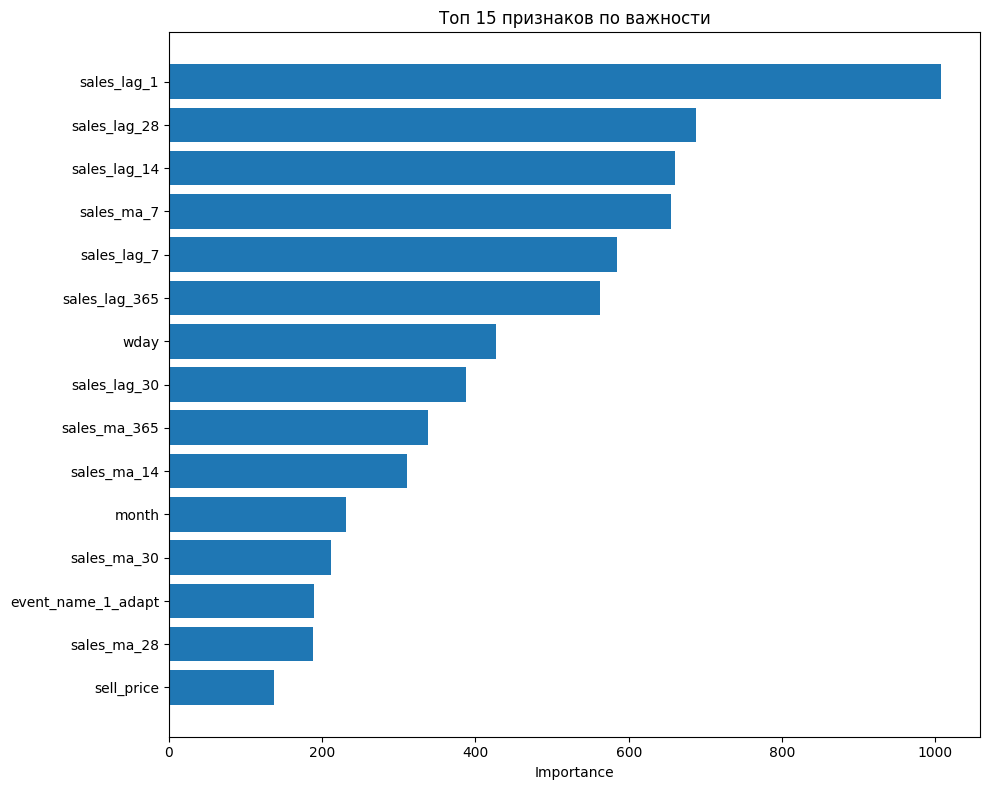

In [ ]:
# Получаем модель и названия признаков
model = all_results['CA_1_FOODS']['model']

# Названия признаков из модели
feature_names = model.feature_name_ if hasattr(model, 'feature_name_') else None

if feature_names is not None:
    # Получаем важность признаков
    importance = model.feature_importances_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)

    print(color.BLUE + color.BOLD + "\n=== ВАЖНОСТЬ ПРИЗНАКОВ ===" + color.END)
    display(importance_df)  # Показываем всю таблицу

    # Визуализация ТОП-15
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df.head(15)['feature'],
             importance_df.head(15)['importance'])
    plt.xlabel('Importance')
    plt.title('Топ 15 признаков по важности')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Модель не сохранила названия признаков")

Анализ важности признаков показал, что ключевую роль для модели играют лаги продаж за 1 и 28 дней. Это логично: именно эти признаки отражают краткосрочную динамику и недельную сезонность спроса. Однако для большей части будущего периода (1942–1969) значения этих лагов неизвестны — они должны быть получены рекурсивно на основе предыдущих предсказаний. Это даёт дополнительное обоснование использованию рекурсивного подхода для прогнозирования будущего: без него модель просто не получит свои самые важные входные данные.

Цена товара (sell_price) заняла лишь 15-е место по важности среди всех признаков. Это говорит о том, что в данной товарной категории динамика продаж определяется скорее временными паттернами и прошлым спросом, чем ценовыми колебаниями.

Несмотря на то, что некоторые признаки показали меньшую важность, я не стала их удалять. В рамках иерархического датасета M5 одна и та же категория товаров может вести себя по-разному в разных магазинах и штатах. Признак, слабый для одной группы, может оказаться значимым для другой. Удаление таких признаков без детальной проверки по каждой группе может привести к ухудшению качества модели на отдельных сегментах данных. В рамках текущего подхода я оставляю все признаки как есть: возможное негативное влияние шумовых признаков на отдельные группы будет сглажено на уровне итогового сабмита за счёт объединения предсказаний всех групп (иерархическая структура данных предполагает, что ошибки отдельных групп могут компенсировать друг друга при формировании общего прогноза).

## **Эксперимент со сменой архитектуры**

Под сменой архитектуры здесь понимается изменение способа предсказания на тестовом периоде: вместо прямого (одним батчем) используется рекурсивное (день за днём с обновлением истории).

Для основной работы я буду использовать модели, основанные на архитектуре, описанной выше: прямое предсказание для теста и рекурсивное — для будущего. Такой подход является стандартной практикой в задачах M5, поскольку он обеспечивает оптимальный баланс между скоростью расчётов и качеством прогноза.

В рамках данного эксперимента на примере одной модели (CA_1_FOODS) я покажу, как выглядел бы результат, если бы рекурсия применялась не только для будущего, но и для тестового периода.

*Примечание: Вариант с рекурсивной валидацией в рамках Optuna не рассматривается: это потребовало бы значительного увеличения вычислительных ресурсов, замедлило бы подбор гиперпараметров и могло бы привести к менее стабильным результатам без гарантированного улучшения итоговой метрики.*

####  **Обновление функций**


Для достижения задуманного немного переделаю имеющиеся функции. А чтобы можно было работать с данным разделом независимо, продублирую часть уже имеющихся.

In [ ]:
# та же, что раньше (не менялась)

# sub 3
# добавилось ужатие типов новых колонок

# подготовка данных для работы с моделью
# взяла и 28 и 30 под месяц,
# так как 28 - по недельным циклам, а 30 ближе к календарному
def prepare_data(file_name,
                 lags=LAGS,        # используем глобальную переменную
                 windows=WINDOWS): # используем глобальную переменную
    """
    Загружает файл, добавляет лаги и скользящие средние,
    удаляет пропуски.

    Returns:
        dict: df, group_name, feature_names
    """

    # ===== 1. Загрузка =====
    path_content = f'/content/{file_name}'
    path_drive = f'{MODELS_PATH}{file_name}'

    try:
        if os.path.exists(path_content):
            df = pd.read_parquet(path_content)
            print(color.GREEN + color.BOLD + f"V Загружен из /content/: {file_name}" + color.END)
        else:
            df = pd.read_parquet(path_drive)
            print(color.GREEN + color.BOLD + f"V Загружен с Google Диска: {file_name}" + color.END)
    except Exception as e:
        print(color.RED + color.BOLD + f"X Ошибка загрузки {file_name}: {e}" + color.END)
        return None

    group_name = file_name.replace('m5_data_', '').replace('.parquet', '')

    # ===== 2. Сортировка (обязательно для shift!) =====
    # ВНИМАНИЕ! В M5 данные уже отсортированы по (d, id),
    # но sort_values(['id', 'd']) пересортирует их в порядок (id, d)
    # Это гарантирует, что внутри каждого id дни идут последовательно
    # и shift() будет работать корректно
    # но так как есть уверенность в правильном порядке данных, не пересортировываю
    # df = df.sort_values(['id', 'd'])

    # ===== 3. Добавляем лаги =====
    for lag in lags:
        # продажи
        df[f'sales_lag_{lag}'] = df.groupby('id', observed=True)['sales'].shift(lag)
        # цены
        df[f'sell_price_lag_{lag}'] = df.groupby('id', observed=True)['sell_price'].shift(lag)

    # ===== 4. Добавляем скользящие средние =====
    for window in windows:
        # продажи
        df[f'sales_ma_{window}'] = df.groupby('id', observed=True)['sales'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        # цены
        df[f'sell_price_ma_{window}'] = df.groupby('id', observed=True)['sell_price'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )

    # ===== 4.5 Оптимизация типов =====
    # Все производные признаки (лаги и скользящие средние) при создании через shift
    # они автоматически получили тип float64
    # переводим все во float32 для ускорения
    # Это безопасно: точности float32 хватает для прогнозирования
    # в int лаги продаж не преводим из-за некоректной работы с возникающими Nan
    convert_cols = [col for col in df.columns
                    if any(col.startswith(prefix) for prefix in
                          ['sales_lag_', 'sales_ma_', 'sell_price_lag_', 'sell_price_ma_'])]

    for col in convert_cols:
        df[col] = df[col].astype('float32')

    # ===== 5. Удаляем строки с NaN =====
    # первые 365 дней (лаговые) и другие строки с пропусками (те, для которых нет цен)
    df = df.dropna()

    # ===== 6. Определяем признаки =====
    # не участвуют в предсказании
    exclude_cols = EXCLUDE_COLS
    # нужны для предсказания
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    print(color.BLUE + color.BOLD + f"   {group_name}: Всего строк {len(df):,}, Признаков для предсказания {len(feature_cols)}" + color.END)

    # ===== 7. Возвращаем результат =====
    return {
        'df': df,  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
        'group_name': group_name
    }

In [ ]:
# та же, что раньше (не менялась)

# sub 3
# добавила ужатие типов
def recursive_forecast_simple(model, X_future, X_history, feature_cols,
                              lags=LAGS,        # используем глобальную переменную
                              windows=WINDOWS): # используем глобальную переменную):
    """
    Рекурсивное предсказание для будущих дней (оптимизированная версия).

    Parameters:
        model: обученная модель LightGBM
        X_future: DataFrame с признаками для будущих дней (d_1942–d_1969)
        X_history: DataFrame с историческими данными (train + test)
        feature_cols: список признаков для модели

    Returns:
        DataFrame с колонками: id, d, pred
    """

    # ===== 1. СОЗДАЁМ КОПИЮ ДЛЯ ПРЕДСКАЗАНИЙ =====
    # Копируем X_future, чтобы не изменять исходные данные
    X_future_rec = X_future.copy()
    # Добавляем колонку для предсказаний
    X_future_rec['pred'] = 0.0

    # ===== 2. ПОЛУЧАЕМ СПИСОК УНИКАЛЬНЫХ ТОВАРОВ =====
    # Для каждого товара будем хранить свою историю продаж
    ids = X_future_rec['id'].unique()

    # ===== 3. СТРОИМ ИСТОРИЮ ПРОДАЖ ДЛЯ КАЖДОГО ТОВАРА =====
    # Храним последние 365 дней продаж для каждого товара
    # Это нужно для обновления лагов и скользящих средних
    history_dict = {}
    for id_val in ids:
        # Берём последние 365 дней продаж из истории
        history = X_history[X_history['id'] == id_val]['sales'].tail(365).tolist()
        # Если истории нет (такого не должно быть), заполняем средним
        if not history:
            history = [X_history['sales'].mean()] * 365
        history_dict[id_val] = history

    # ===== 4. ПОЛУЧАЕМ СПИСОК ДНЕЙ =====
    # Сортируем дни, чтобы предсказывать последовательно
    days = sorted(X_future_rec['d'].unique())

    # ===== 5. РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ПО ДНЯМ =====
    # Для каждого дня предсказываем все товары сразу (батчем)
    for d in days:
        # 5.1 Получаем индексы строк для текущего дня
        day_mask = X_future_rec['d'] == d
        day_indices = X_future_rec[day_mask].index

        # Если нет товаров в этот день, пропускаем
        if len(day_indices) == 0:
            continue

        # 5.2 Обновляем лаги и скользящие средние для всех товаров этого дня
        # Для каждого товара обновляем признаки на основе последних продаж из истории
        for idx in day_indices:
            id_val = X_future_rec.loc[idx, 'id']
            history = history_dict[id_val]

            # Обновляем лаги продаж (1, 7, 14, 28, 30, 365 дней назад)
            for lag in lags:
                col = f'sales_lag_{lag}'
                if col in X_future_rec.columns:
                    # Берём значение из истории на соответствующем шаге назад
                    if lag <= len(history):
                        X_future_rec.loc[idx, col] = history[-lag]
                    else:
                        X_future_rec.loc[idx, col] = history[-1]

            # Обновляем скользящие средние продаж
            for window in windows:
                col = f'sales_ma_{window}'
                if col in X_future_rec.columns:
                    # Считаем среднее за последние window дней
                    if len(history) >= window:
                        X_future_rec.loc[idx, col] = sum(history[-window:]) / window
                    else:
                        X_future_rec.loc[idx, col] = sum(history) / len(history) if history else 0

        # 5.3 БАТЧЕВОЕ ПРЕДСКАЗАНИЕ (ВСЕ ТОВАРЫ ДНЯ ЗА ОДИН РАЗ)
        # Берём DataFrame для всего дня — категории сохраняются!
        X_batch = X_future_rec.loc[day_indices, feature_cols].copy()

        # Предсказываем сразу для всех товаров дня
        # Это в 10-20 раз быстрее, чем предсказывать по одному
        preds = model.predict(X_batch)

        # 5.4 Обновляем предсказания и историю
        for i, idx in enumerate(day_indices):
            id_val = X_future_rec.loc[idx, 'id']
            pred = preds[i]

            # Сохраняем предсказание
            X_future_rec.loc[idx, 'pred'] = pred

            # Обновляем историю продаж для этого товара
            # Добавляем предсказанное значение для следующего дня
            history = history_dict[id_val]
            history.append(pred)
            # Оставляем только последние 365 дней (экономия памяти)
            if len(history) > 365:
                history = history[-365:]
            history_dict[id_val] = history

    # ===== 6. ВОЗВРАЩАЕМ РЕЗУЛЬТАТ =====
    # Возвращаем только id, d и предсказания
    result = X_future_rec[['id', 'd', 'pred']].copy()
    result['pred'] = result['pred'].astype('float32')  # для единообразия
    return result

Подкорректирую функцию предсказания теста: добавлю вариант рекурсивного предсказания теста и его сравнения с прямым. Вариант с рекурсивной валидацией мною был обдуман, но не применен ввиду слишком больших относительно доступных ресурсов (Оптуна сильно замедляется, прирост метрики часто невысок, а гиперпараметры обычно стабильны при прямом предсказании).

In [ ]:
# доработанная:
# добавлены разные подходы к обучению и предсказанию

# sub 3
# убрала ненужную (нерабочую) раннюю остановку в дообучении моделей

# функция для обучения моделей
# упрощенный вариант, для ручного запуска
# цикл неудобен, так как что-то может упасть
def train_lgbm(df,
               train_start=TRAIN_START,  # 366, Первый день для обучения (после удаления NaN)
               train_end=TRAIN_END,   #1913,  Последний день для обучения
               test_start=TEST_START,  # 1914, Первый день для теста
               test_end=TEST_END,    # 1941, Последний день для теста
               future_start=FUTURE_START, # 1942, Первый день для будущего (сабмит)
               future_end=FUTURE_END,  # 1969, Последний день для будущего (сабмит)
               n_trials=5,       # Количество итераций Optuna (5 — для скорости, 15-30 — для качества)
               random_state=RANDOM_STATE): # Для воспроизводимости результатов
    """
    Обучает модель LightGBM с подбором гиперпараметров через Optuna.
    Разбивка на train/test происходит ВНУТРИ функции.

    Parameters:
        df: подготовленный DataFrame с признаками
        train_start, train_end: границы тренировочного периода
        test_start, test_end: границы тестового периода
        future_start, future_end: границы будущего периода (сабмит)
        n_trials: количество итераций Optuna
        random_state: для воспроизводимости результатов

    Returns:
        dict: модель, метрики, предсказания, параметры
        - model: обучена на train
        - model_full: обучена на train + test
        - метрики для обеих моделей
        - предсказания для train, test, future (рекурсивные)
        - истинные целевые
    """

    # ===== 0. Разбиваем данные =====
    train = df[(df['d'] >= train_start) & (df['d'] <= train_end)]
    test = df[(df['d'] >= test_start) & (df['d'] <= test_end)]
    X_future = df[(df['d'] >= future_start) & (df['d'] <= future_end)].copy()
    # Удаляем sales (целевая переменная) — для будущего она неизвестна
    X_future = X_future.drop('sales', axis=1)

    X_train = train
    y_train = train['sales']
    X_test = test
    y_test = test['sales']

    # ===== 1. Определяем категориальные признаки =====
    # LightGBM умеет работать с категориями напрямую (быстрее и точнее one-hot)
    # Это столбцы, которые содержат не числа, а категории (день недели, месяц, события)
    # Используем глобальный список CAT_FEATURES
    # Оставляем только те, которые реально есть в данных (если вдруг удалили)
    cat_features = [col for col in CAT_FEATURES if col in X_train.columns]

    # ===== 2. Создаём валидацию ПО ВРЕМЕНИ =====
    # ВАЖНО: НЕ используем TimeSeriesSplit, потому что он перемешивает товары!
    # Вместо этого фильтруем по столбцу 'd' (номер дня)
    # Все товары участвуют и в обучении, и в валидации, но в РАЗНЫЕ дни

    # train у нас: d от 366 до 1913
    # Берём последние 28 дней train как валидацию (как в тесте — 28 дней)
    val_end = train_end         # Конец периода валидации (последний день train, 1913)
    val_start = val_end - 28    # Начало периода валидации (последние 28 дней train)

    print(color.BLUE + color.BOLD + f"   Train: дни {train_start}–{train_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Test: дни {test_start}–{test_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Валидация: дни {val_start}–{val_end}" + color.END)

    # ===== 2.5 ВАЖНО: валидация ОСТАЁТСЯ ПРЯМОЙ =====
    #    - Рекурсивная валидация замедлит Optuna в 10-20 раз
    #    - Практика показывает, что прямая валидация даёт стабильные гиперпараметры
    #    - Рекурсивный подход используется ТОЛЬКО для теста и будущего

    # ===== 3. Функция цели для Optuna =====
    # Optuna будет вызывать эту функцию n_trials раз с разными параметрами
    # Задача: найти параметры, которые дают минимальный RMSE на валидации
    def objective(trial):
        """
        Функция, которую Optuna оптимизирует.
        Возвращает RMSE на валидации.
        """

        # ===== 3.1 Определяем пространство поиска гиперпараметров =====
        # trial.suggest_* — предлагает значение в указанном диапазоне
        # Логарифмическая шкала (log=True) лучше для параметров с большим разбросом

        params = {
            # Количество деревьев в ансамбле (чем больше, тем лучше, но дольше)
            'n_estimators': trial.suggest_int('n_estimators', 100, 300)

            # Скорость обучения (learning_rate * n_estimators ≈ эффективная сложность)
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True)

            # Количество листьев — ГЛАВНЫЙ параметр сложности LightGBM
            # Чем больше листьев, тем сложнее модель (риск переобучения)
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),

            # Максимальная глубина дерева (ограничивает рост, регуляризация)
            'max_depth': trial.suggest_int('max_depth', 3, 12)

            # ===== ФУНКЦИЯ ПОТЕРЬ ДЛЯ INTERMITTENT DEMAND =====
            # Tweedie — подходит для данных с большим количеством нулей (наш случай!)
            # variance_power — контролирует распределение: 1.5 — хорошее значение по умолчанию
            'objective': 'tweedie',
            'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.9),

            # L1 регуляризация (лассо) — зануляет неважные признаки
            'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 1.0, log=True),

            # L2 регуляризация (ридж) — штрафует большие веса
            'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 1.0, log=True),

            # Доля объектов для обучения каждого дерева
            # < 1.0 — увеличивает разнообразие деревьев (борьба с переобучением)
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),

            # Доля признаков для обучения каждого дерева
            # < 1.0 — уменьшает корреляцию между деревьями
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

            # Минимальное количество объектов в листе
            # Больше → более простые деревья (регуляризация)
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),

            # Фиксируем random_state для воспроизводимости
            'random_state': random_state,

            # Отключаем вывод (чтобы не засорять логи)
            'verbosity': -1,

            # force_row_wise=True — быстрее для больших данных
            'force_row_wise': True,

            # n_jobs=-1 — используем все ядра процессора
            'n_jobs': -1
        }

        model = lgb.LGBMRegressor(**params)

        # Признаки для модели (все, кроме служебных столбцов и целевого)
        exclude_cols = EXCLUDE_COLS
        feature_cols = [col for col in X_train.columns if col not in exclude_cols]

        # ===== 3.2 ВАЖНО: валидация по d, а не по индексу! =====
        # Все товары участвуют, но берём только нужные дни
        # Это НЕ перемешивает товары внутри фолдов

        # Обучаем на ВСЕХ товарах, но только на днях ДО val_start
        X_tr = X_train[X_train['d'] < val_start]
        y_tr = y_train[X_train['d'] < val_start]

        # Валидация на последних 28 днях train (все товары)
        X_val = X_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]
        y_val = y_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]

        # Явно указываем категориальные признаки
        categorical_features = [col for col in cat_features if col in feature_cols]

        # Обучаем модель с ранней остановкой (используем ТОЛЬКО признаки)
        model.fit(
            X_tr[feature_cols], y_tr,
            eval_set=[(X_val[feature_cols], y_val)],  # Данные для контроля переобучения
            eval_metric='rmse',         # Метрика для ранней остановки
            categorical_feature=categorical_features,  # ← ЯВНО УКАЗЫВАЕМ!
            callbacks=[
                lgb.early_stopping(10),  # более строгая ранняя остановка
                lgb.log_evaluation(0)    # 0 — отключаем вывод
            ]
        )

        # Предсказываем на валидации
        preds = model.predict(X_val[feature_cols])
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse  # Optuna будет минимизировать это значение

    # ===== 4. Запуск Optuna =====
    print(color.BLUE + color.BOLD + "   Оптимизация гиперпараметров..." + color.END)

    # Создаём объект study для оптимизации
    study = optuna.create_study(
        direction='minimize',  # Минимизируем RMSE
        sampler=optuna.samplers.RandomSampler(seed=random_state)  # Случайный поиск
    )

    # Запускаем оптимизацию на n_trials итераций
    # show_progress_bar=False — отключаем прогресс-бар (он может тормозить)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    # Получаем лучшие параметры и лучшее значение RMSE
    best_params = study.best_params
    best_rmse = study.best_value

    print(color.GREEN + color.BOLD + f"   Лучший RMSE (CV): {best_rmse:.4f}" + color.END)
    print(color.BLUE + color.BOLD + f"   Лучшие параметры: {best_params}" + color.END)

    # ===== 5. Финальные параметры =====
    final_params = {
        **best_params,  # Распаковываем лучшие параметры
        'random_state': random_state,
        'verbosity': -1,
        'force_row_wise': True,
        'n_jobs': -1
    }

    feature_cols = [col for col in X_train.columns if col not in EXCLUDE_COLS]
    categorical_features = [col for col in cat_features if col in feature_cols]

    # ============================================================
    # БЛОК 1: МОДЕЛЬ НА TRAIN (только train, без test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 1/2] Обучение на train..." + color.END)

    model = lgb.LGBMRegressor(**final_params)
    model.fit(
        X_train[feature_cols], y_train,
        # нет ранней остановки,
        # так как это не подбор, а переобучение
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model (на train и test)
    preds_train = model.predict(X_train[feature_cols])
    preds_test = model.predict(X_test[feature_cols])

    # DataFrames с предсказаниями для model
    train_predictions_df = X_train[['id', 'd']].copy()
    train_predictions_df['pred'] = preds_train

    test_predictions_df = X_test[['id', 'd']].copy()
    test_predictions_df['pred'] = preds_test

    # Метрики для model
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))

    print(color.GREEN + color.BOLD + f"   RMSE_train: {rmse_train:.4f}" + color.END)
    print(color.GREEN + color.BOLD + f"   RMSE_test:  {rmse_test:.4f}" + color.END)

    # ============================================================
    # БЛОК 2: МОДЕЛЬ НА ВСЕХ ИСТОРИЧЕСКИХ ДАННЫХ (train + test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 2/2] Обучение на всех исторических данных (train + test)..." + color.END)

    # Берём исторические данные напрямую из df
    X_all = df[(df['d'] >= train_start) & (df['d'] <= test_end)]
    y_all = X_all['sales']

    model_full = lgb.LGBMRegressor(**final_params)
    model_full.fit(
        X_all[feature_cols], y_all,
        # нет ранней остановки,
        # так как это не подбор, а переобучение
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model_full (на всех исторических)
    preds_train_full = model_full.predict(X_all[feature_cols])

    # DataFrame с предсказаниями для model_full
    all_predictions_df = X_all[['id', 'd']].copy()
    all_predictions_df['pred'] = preds_train_full

    # Метрика для model_full
    rmse_train_full = np.sqrt(mean_squared_error(y_all, preds_train_full))

    print(color.GREEN + color.BOLD + f"   RMSE_train_full: {rmse_train_full:.4f}" + color.END)

    # ============================================================
    # БЛОК 2.5: РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ НА ТЕСТ (1914–1941)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Рекурсия на тест] Предсказание для дней 1914–1941..." + color.END)

    # 1. Создаём историю для рекурсии (данные до 1913)
    X_history_test = df[(df['d'] >= train_start) & (df['d'] <= train_end)]  # 366–1913

    # 2. Создаём X_test_future (тестовые дни 1914–1941) без целевой переменной
    X_test_future = df[(df['d'] >= test_start) & (df['d'] <= test_end)].copy()
    X_test_future = X_test_future.drop('sales', axis=1)

    # 3. Рекурсивное предсказание на тест
    test_preds_recursive = recursive_forecast_simple(
        model_full,      # используем модель, обученную на всех исторических данных
        X_test_future,   # данные для теста (1914–1941)
        X_history_test,  # история до 1913
        feature_cols
    )

    print(color.GREEN + color.BOLD + f"   Рекурсивных предсказаний на тест: {len(test_preds_recursive):,}" + color.END)

    # 4. Считаем RMSE на тесте для рекурсивных предсказаний
    y_test_recursive = y_test  # истинные значения для теста
    rmse_test_recursive = np.sqrt(mean_squared_error(
        y_test_recursive,
        test_preds_recursive['pred']
    ))

    print(color.GREEN + color.BOLD + f"   RMSE_test (рекурсивный): {rmse_test_recursive:.4f}" + color.END)
    print(color.BLUE + color.BOLD + f"   RMSE_test (прямой):     {rmse_test:.4f}" + color.END)

    # 5. Сравнение прямого и рекурсивного теста
    if rmse_test_recursive < rmse_test:
        print(color.GREEN + color.BOLD + f"   V Рекурсивный тест лучше прямого на {rmse_test - rmse_test_recursive:.4f}" + color.END)
    else:
        print(color.NEWYELLOW + color.BOLD + f"   ! Прямой тест лучше рекурсивного на {rmse_test_recursive - rmse_test:.4f}" + color.END)

    # ============================================================
    # БЛОК 3: РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ДЛЯ БУДУЩЕГО
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Рекурсия] Предсказание для будущего..." + color.END)

    # Берём историю напрямую из df — категории уже правильные!
    X_history = df[(df['d'] >= train_start) & (df['d'] <= test_end)]

    future_preds_recursive = recursive_forecast_simple(
        model_full, X_future, X_history, feature_cols
        # categorical_features больше не нужен — категории уже правильные!
    )

    print(color.GREEN + color.BOLD + f"   Будущих рекурсивных предсказаний: {len(future_preds_recursive):,}" + color.END)

    # ============================================================
    # БЛОК 4: СВОДКА ПО ТРЁМ ПОДХОДАМ
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   === СВОДКА ПО ТРЁМ ПОДХОДАМ ===" + color.END)
    print(f"   1. Прямой тест (базовый):           RMSE = {rmse_test:.4f}")
    print(f"   2. Рекурсивный тест:                RMSE = {rmse_test_recursive:.4f}")
    print(f"   3. Рекурсивное будущее (сабмит):    предсказаний = {len(future_preds_recursive):,}")

    if rmse_test_recursive < rmse_test:
        print(color.GREEN + color.BOLD + f"   Лучший на тесте: рекурсивный подход (на {rmse_test - rmse_test_recursive:.4f} лучше)" + color.END)
    else:
        print(color.NEWYELLOW + color.BOLD + f"   Лучший на тесте: прямой подход (на {rmse_test_recursive - rmse_test:.4f} лучше)" + color.END)

    # ============================================================
    # БЛОК 5: ВОЗВРАТ РЕЗУЛЬТАТОВ
    # ============================================================
    return {
        #'model': model,                      # Модель на train
        #'model_full': model_full,            # Модель на train + test

        'rmse_train': rmse_train,            # RMSE на train (model)
        'rmse_test': rmse_test,              # RMSE на test (model) — ГЛАВНАЯ МЕТРИКА
        'rmse_train_full': rmse_train_full,  # RMSE на train + test (model_full)

        'rmse_test_recursive': rmse_test_recursive,  # Рекурсивный RMSE на тесте

        'best_rmse_cv': best_rmse,           # Лучший RMSE на валидации
        'best_params': best_params,          # Лучшие гиперпараметры

        # === ИСТИННЫЕ ЗНАЧЕНИЯ (ВСЕ исторические) ===
        'y_all': y_all,  # ← ОДИН набор! (train + test)
        # === ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ ===
        'train_predictions_df': train_predictions_df,   # train (model)
        'test_predictions_df': test_predictions_df,     # test (model)
        'all_predictions_df': all_predictions_df,       # train + test (model_full)
        'test_predictions_recursive': test_preds_recursive,  # рекурсивный тест
        'future_predictions_recursive': future_preds_recursive,  # сабмит
        #'study': study                       # Объект study (для анализа Optuna)
    }

In [ ]:
# Создаём словарь ДО запуска
all_results = {}

In [ ]:
# доработанная (изменено возвращаемое под соаметимость с моделью выше),
# заточена на будущую работу с условным ансамблем
# так как экперимент на самом деле проводился уже после получения sub3
# но в рамках собираемого воедино проекта логичнее смотрится здесь
# то есть она как финальная

#sub 3
# объединяющая функция
def run_pipeline(file_name, results_dict, n_trials=5):
    """
    Запускает полный пайплайн: загрузка → подготовка → обучение → сохранение.

    Parameters:
        file_name: str — имя файла (например, 'm5_data_CA_1_FOODS.parquet')
        results_dict: dict — словарь для накопления результатов всех моделей
        n_trials: int — количество итераций Optuna (по умолчанию 5)

    Returns:
        dict: обновлённый словарь с результатами
    """

    # ===== 1. ПОДГОТОВКА ДАННЫХ =====
    # Вызываем функцию, которая загружает файл, добавляет лаги и скользящие средние,
    # удаляет пропуски
    print(color.BLUE + color.BOLD + "\n[1/3] Подготовка данных..." + color.END)
    data = prepare_data(file_name)  # ← СНАЧАЛА определяем data!

    # Если данные не загрузились — prepare_data() уже вывела ошибку
    # Просто выходим из функции, ничего не сохраняя
    if data is None:
        return results_dict

    # Распаковываем данные (извлекаем DataFrame и group_name из словаря)
    df = data['df']  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
    group_name = data['group_name']  # ← используем из prepare_data

    # Разделитель для наглядности в логах
    print(color.NEWYELLOW + color.BOLD + f"\n{'='*60}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"Запуск пайплайна для группы: {group_name}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"{'='*60}" + color.END)

    # ===== 2. ОБУЧЕНИЕ МОДЕЛИ =====
    # Вызываем функцию, которая подбирает гиперпараметры через Optuna
    # и обучает финальную модель LightGBM
    # Разбивка на train/test происходит ВНУТРИ функции train_lgbm
    print(color.BLUE + color.BOLD + "\n[2/3] Обучение модели..." + color.END)
    result = train_lgbm(df, n_trials=n_trials)

    # ===== 3. ФОРМИРОВАНИЕ РЕЗУЛЬТАТА =====
    # Сохраняем всё в общий словарь
    results_dict[group_name] = {
        # === МОДЕЛИ ===
        #'model': result['model'],                              # обучена на train
        #'model_full': result['model_full'],                    # обучена на train + test

        # === МЕТРИКИ ===
        'rmse_train': result['rmse_train'],                    # RMSE на train (model)
        'rmse_test': result['rmse_test'],                      # RMSE на test (model) — ГЛАВНАЯ
        'rmse_train_full': result['rmse_train_full'],          # RMSE на train + test (model_full)
        'best_rmse_cv': result['best_rmse_cv'],                # Лучший RMSE на валидации (CV)
        'best_params': result['best_params'],                  # Лучшие гиперпараметры

        # === ИСТИННЫЕ ЗНАЧЕНИЯ (ВСЕ исторические) ===
        'y_all': result['y_all'],  # ← ОДИН набор! (train + test)

        # === ПРЕДСКАЗАНИЯ ===
        'train_predictions_df': result['train_predictions_df'],        # train (model)
        'test_predictions_df': result['test_predictions_df'],          # test (model)
        'all_predictions_df': result['all_predictions_df'],            # train + test (model_full)
        'future_predictions_recursive': result['future_predictions_recursive'],  # сабмит (model_full, рекурсивные)

        'status': 'success'
    }

    # ===== 4. ОЧИСТКА ПАМЯТИ =====
    # Удаляем большие объекты, чтобы освободить память перед следующей моделью
    del data, df, result
    gc.collect()  # Принудительный вызов сборщика мусора

    # ===== 5. ВЫВОД РЕЗУЛЬТАТА =====
    # train_lgbm() уже вывела метрики, просто подтверждаем успех
    print(color.GREEN + color.BOLD + f"\nV {group_name} — успешно завершена!" + color.END)

    return results_dict

#### **Обучение тестовой модели**

In [ ]:
# обучение
%time all_results = run_pipeline('m5_data_CA_1_FOODS.parquet', all_results, n_trials=5)


[1/3] Подготовка данных...
V Загружен с Google Диска: m5_data_CA_1_FOODS.parquet
   CA_1_FOODS: Всего строк 1,777,133, Признаков для предсказания 33

Запуск пайплайна для группы: CA_1_FOODS

[2/3] Обучение модели...


[I 2026-07-22 11:46:44,490] A new study created in memory with name: no-name-c1baea65-ee85-4917-8d15-513cd8b05d27


   Train: дни 366–1913
   Test: дни 1914–1941
   Валидация: дни 1885–1913
   Оптимизация гиперпараметров...
Training until validation scores don't improve for 10 rounds


[I 2026-07-22 11:47:01,228] Trial 0 finished with value: 2.3499324723055115 and parameters: {'n_estimators': 175, 'learning_rate': 0.18679147494991152, 'num_leaves': 76, 'max_depth': 8, 'tweedie_variance_power': 1.2248149123539493, 'reg_alpha': 0.0029375384576328283, 'reg_lambda': 0.0014936568554617625, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835, 'min_child_samples': 37}. Best is trial 0 with value: 2.3499324723055115.


Early stopping, best iteration is:
[23]	valid_0's rmse: 2.34993	valid_0's tweedie: 9.0746
Training until validation scores don't improve for 10 rounds


...

Training until validation scores don't improve for 10 rounds


[I 2026-07-22 11:48:26,529] Trial 3 finished with value: 2.4095881440127607 and parameters: {'n_estimators': 222, 'learning_rate': 0.06333383069438317, 'num_leaves': 15, 'max_depth': 12, 'tweedie_variance_power': 1.8725056264596474, 'reg_alpha': 0.2661901888489056, 'reg_lambda': 0.008200518402245833, 'subsample': 0.6390688456025535, 'colsample_bytree': 0.8736932106048627, 'min_child_samples': 25}. Best is trial 2 with value: 2.341338630636721.


Early stopping, best iteration is:
[80]	valid_0's rmse: 2.40959	valid_0's tweedie: 9.13708
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[68]	valid_0's rmse: 2.35918	valid_0's tweedie: 6.8063


[I 2026-07-22 11:48:52,682] Trial 4 finished with value: 2.3591821805885713 and parameters: {'n_estimators': 124, 'learning_rate': 0.09933360807331099, 'num_leaves': 13, 'max_depth': 12, 'tweedie_variance_power': 1.3070239852800136, 'reg_alpha': 0.0971777530505963, 'reg_lambda': 0.00861257919259488, 'subsample': 0.8080272084711243, 'colsample_bytree': 0.8186841117373118, 'min_child_samples': 13}. Best is trial 2 with value: 2.341338630636721.


   Лучший RMSE (CV): 2.3413
   Лучшие параметры: {'n_estimators': 222, 'learning_rate': 0.06066716167545479, 'num_leaves': 36, 'max_depth': 6, 'tweedie_variance_power': 1.4648559873736287, 'reg_alpha': 0.22673986523780384, 'reg_lambda': 0.00397211072738191, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_samples': 7}

   [Модель 1/2] Обучение на train...
   RMSE_train: 2.7326
   RMSE_test:  2.3804

   [Модель 2/2] Обучение на всех исторических данных (train + test)...
   RMSE_train_full: 2.7229

   [Рекурсия на тест] Предсказание для дней 1914–1941...
   Рекурсивных предсказаний на тест: 39,992
   RMSE_test (рекурсивный): 2.6379
   RMSE_test (прямой):     2.3804
   ! Прямой тест лучше рекурсивного на 0.2575

   [Рекурсия] Предсказание для будущего...
   Будущих рекурсивных предсказаний: 40,012

   === СВОДКА ПО ТРЁМ ПОДХОДАМ ===
   1. Прямой тест (базовый):           RMSE = 2.3804
   2. Рекурсивный тест:                RMSE = 2.6379
   3. Рекурсивное 

Результаты эксперимента показывают, что для тестового периода прямое предсказание даёт значительно более высокую точность — выигрыш составляет около 10% по сравнению с рекурсивным подходом. Это объясняется отсутствием накопления ошибки: при прямом предсказании все 28 дней теста подаются модели одновременно, и лаги рассчитываются на основе реальных продаж, а не на основе предыдущих предсказаний.

Однако для будущего периода (1942–1969) такой подход неприменим, поскольку истинные значения продаж неизвестны, и без рекурсии модель не сможет корректно рассчитать лаги. Таким образом, рекурсивное предсказание остаётся единственным возможным способом получения прогноза для сабмита.

### **Выводы**

Я создала функции (итоговые и промежуточные), необходимые для работы будущих моделей. С их использованием я провела тестирование нескольких подходов:
- 1. использование прямого предсказания для тестового периода и рекурсивного - для будущего.
- 2. использование рекурсивного предсказания для тестового и будущего периода.

Применение рекурсии на этапе валидации признано нецелесообразным: оно требует значительных вычислительных ресурсов и замедляет подбор гиперпараметров без гарантированного улучшения метрик. Рекурсия для будущего применялась в обоих случаях, поскольку прямой подход в условиях отсутствия реальных данных приводит к некорректному расчёту лагов и, как следствие, к значительным ошибкам.

Первый подход (прямой тест + рекурсивное будущее) показал лучшую метрику на тестовом периоде за счёт отсутствия накопления ошибки, что делает его стандартом в задачах M5. Именно этот подход будет использован в дальнейшем для обучения всей группы моделей (условного «ансамбля»).

### **Работа с ансамблем**

Тестовый запуск функций, обучение первой из моделей и анализ важности ее признаков был проведен.

Но в наличие имеется еще 29 моделей (а первую необходимо также переобучить для совместимости с будущим комплексом), а также ограниченность ресурсов (место на диске и вычислительных мощностей).

Поэтому, так как для соревнования важен сабмит, я приняла решение не сохранять модели (занимающие много места в памяти), а сохранять лишь метрики, параметры и предсказания (а также истинные значения, где имелись, для целевого признака, чтобы можно было вычислить общие метрики ансамбля моделей).

Для построения ансамбля необходимо доработать имеющиеся функции.

*Примечание 1: Напоминаю, что под «ансамблем» здесь понимается совокупность моделей, обученных для разных иерархических групп, а не усреднение предсказаний нескольких моделей для одного объекта. Термин используется для упрощения коммуникации.*

*Примечание 2: Чтобы можно было работать сразу с данного раздела, код будет частично дублироваться.*

*Примечание 3: Возможно, было бы практичнее не дублировать код частично для каждой группы, а запускать через цикл. Но тогда потеряется контроль над ситуацией, а в случае зависания или еще каких-то неполадок будет потерян результат обучений сразу весь, а также не будет возможности работать с каждой моделью по-отдельности. К тому же, текущий подход позволит частично продемонстрировать ход исследования ("эволюцию мысли и проекта"), что, с моей точки зрения, может быть полезным и интересным, с учетом специфики проекта (соревнования на Кагле).*

####  **Обновление функций**


Для достижения задуманного немного переделаю имеющиеся функции. А чтобы можно было работать с данным разделом независимо, продублирую часть уже имеющихся.

In [ ]:
# та же, что раньше (не менялась)

# sub 3
# подготовка данных для работы с моделью
# взяла и 28 и 30 под месяц,
# так как 28 - по недельным циклам, а 30 ближе к календарному
# и ужатие типов новых колонок
def prepare_data(file_name,
                 lags=LAGS,        # используем глобальную переменную
                 windows=WINDOWS): # используем глобальную переменную
    """
    Загружает файл, добавляет лаги и скользящие средние,
    удаляет пропуски.

    Returns:
        dict: df, group_name, feature_names
    """

    # ===== 1. Загрузка =====
    path_content = f'/content/{file_name}'
    path_drive = f'{MODELS_PATH}{file_name}'

    try:
        if os.path.exists(path_content):
            df = pd.read_parquet(path_content)
            print(color.GREEN + color.BOLD + f"V Загружен из /content/: {file_name}" + color.END)
        else:
            df = pd.read_parquet(path_drive)
            print(color.GREEN + color.BOLD + f"V Загружен с Google Диска: {file_name}" + color.END)
    except Exception as e:
        print(color.RED + color.BOLD + f"X Ошибка загрузки {file_name}: {e}" + color.END)
        return None

    group_name = file_name.replace('m5_data_', '').replace('.parquet', '')

    # ===== 2. Сортировка (обязательно для shift!) =====
    # ВНИМАНИЕ! В M5 данные уже отсортированы по (d, id),
    # но sort_values(['id', 'd']) пересортирует их в порядок (id, d)
    # Это гарантирует, что внутри каждого id дни идут последовательно
    # и shift() будет работать корректно
    # но так как есть уверенность в правильном порядке данных, не пересортировываю
    # df = df.sort_values(['id', 'd'])

    # ===== 3. Добавляем лаги =====
    for lag in lags:
        # продажи
        df[f'sales_lag_{lag}'] = df.groupby('id', observed=True)['sales'].shift(lag)
        # цены
        df[f'sell_price_lag_{lag}'] = df.groupby('id', observed=True)['sell_price'].shift(lag)

    # ===== 4. Добавляем скользящие средние =====
    for window in windows:
        # продажи
        df[f'sales_ma_{window}'] = df.groupby('id', observed=True)['sales'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        # цены
        df[f'sell_price_ma_{window}'] = df.groupby('id', observed=True)['sell_price'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )

    # ===== 4.5 Оптимизация типов =====
    # Все производные признаки (лаги и скользящие средние) при создании через shift
    # они автоматически получили тип float64
    # переводим все во float32 для ускорения
    # Это безопасно: точности float32 хватает для прогнозирования
    # в int лаги продаж не преводим из-за некоректной работы с возникающими Nan
    convert_cols = [col for col in df.columns
                    if any(col.startswith(prefix) for prefix in
                          ['sales_lag_', 'sales_ma_', 'sell_price_lag_', 'sell_price_ma_'])]

    for col in convert_cols:
        df[col] = df[col].astype('float32')

    # ===== 5. Удаляем строки с NaN =====
    # первые 365 дней (лаговые) и другие строки с пропусками (те, для которых нет цен)
    df = df.dropna()

    # ===== 6. Определяем признаки =====
    # не участвуют в предсказании
    exclude_cols = EXCLUDE_COLS
    # нужны для предсказания
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    print(color.BLUE + color.BOLD + f"   {group_name}: Всего строк {len(df):,}, Признаков для предсказания {len(feature_cols)}" + color.END)

    # ===== 7. Возвращаем результат =====
    return {
        'df': df,  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
        'group_name': group_name,
        #'feature_names': feature_cols # дальше не используется, так как для предсказания берется список из train_lgbm()
    }

In [ ]:
# та же, что раньше (не менялась)

# sub 3
# добавила ужатие типов
def recursive_forecast_simple(model, X_future, X_history, feature_cols,
                              lags=LAGS,        # используем глобальную переменную
                              windows=WINDOWS): # используем глобальную переменную):
    """
    Рекурсивное предсказание для будущих дней (оптимизированная версия).

    Parameters:
        model: обученная модель LightGBM
        X_future: DataFrame с признаками для будущих дней (d_1942–d_1969)
        X_history: DataFrame с историческими данными (train + test)
        feature_cols: список признаков для модели

    Returns:
        DataFrame с колонками: id, d, pred
    """

    # ===== 1. СОЗДАЁМ КОПИЮ ДЛЯ ПРЕДСКАЗАНИЙ =====
    # Копируем X_future, чтобы не изменять исходные данные
    X_future_rec = X_future.copy()
    # Добавляем колонку для предсказаний
    X_future_rec['pred'] = 0.0

    # ===== 2. ПОЛУЧАЕМ СПИСОК УНИКАЛЬНЫХ ТОВАРОВ =====
    # Для каждого товара будем хранить свою историю продаж
    ids = X_future_rec['id'].unique()

    # ===== 3. СТРОИМ ИСТОРИЮ ПРОДАЖ ДЛЯ КАЖДОГО ТОВАРА =====
    # Храним последние 365 дней продаж для каждого товара
    # Это нужно для обновления лагов и скользящих средних
    history_dict = {}
    for id_val in ids:
        # Берём последние 365 дней продаж из истории
        history = X_history[X_history['id'] == id_val]['sales'].tail(365).tolist()
        # Если истории нет (такого не должно быть), заполняем средним
        if not history:
            history = [X_history['sales'].mean()] * 365
        history_dict[id_val] = history

    # ===== 4. ПОЛУЧАЕМ СПИСОК ДНЕЙ =====
    # Сортируем дни, чтобы предсказывать последовательно
    days = sorted(X_future_rec['d'].unique())

    # ===== 5. РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ПО ДНЯМ =====
    # Для каждого дня предсказываем все товары сразу (батчем)
    for d in days:
        # 5.1 Получаем индексы строк для текущего дня
        day_mask = X_future_rec['d'] == d
        day_indices = X_future_rec[day_mask].index

        # Если нет товаров в этот день, пропускаем
        if len(day_indices) == 0:
            continue

        # 5.2 Обновляем лаги и скользящие средние для всех товаров этого дня
        # Для каждого товара обновляем признаки на основе последних продаж из истории
        for idx in day_indices:
            id_val = X_future_rec.loc[idx, 'id']
            history = history_dict[id_val]

            # Обновляем лаги продаж (1, 7, 14, 28, 30, 365 дней назад)
            for lag in lags:
                col = f'sales_lag_{lag}'
                if col in X_future_rec.columns:
                    # Берём значение из истории на соответствующем шаге назад
                    if lag <= len(history):
                        X_future_rec.loc[idx, col] = history[-lag]
                    else:
                        X_future_rec.loc[idx, col] = history[-1]

            # Обновляем скользящие средние продаж
            for window in windows:
                col = f'sales_ma_{window}'
                if col in X_future_rec.columns:
                    # Считаем среднее за последние window дней
                    if len(history) >= window:
                        X_future_rec.loc[idx, col] = sum(history[-window:]) / window
                    else:
                        X_future_rec.loc[idx, col] = sum(history) / len(history) if history else 0

        # 5.3 БАТЧЕВОЕ ПРЕДСКАЗАНИЕ (ВСЕ ТОВАРЫ ДНЯ ЗА ОДИН РАЗ)
        # Берём DataFrame для всего дня — категории сохраняются!
        X_batch = X_future_rec.loc[day_indices, feature_cols].copy()

        # Предсказываем сразу для всех товаров дня
        # Это в 10-20 раз быстрее, чем предсказывать по одному
        preds = model.predict(X_batch)

        # 5.4 Обновляем предсказания и историю
        for i, idx in enumerate(day_indices):
            id_val = X_future_rec.loc[idx, 'id']
            pred = preds[i]

            # Сохраняем предсказание
            X_future_rec.loc[idx, 'pred'] = pred

            # Обновляем историю продаж для этого товара
            # Добавляем предсказанное значение для следующего дня
            history = history_dict[id_val]
            history.append(pred)
            # Оставляем только последние 365 дней (экономия памяти)
            if len(history) > 365:
                history = history[-365:]
            history_dict[id_val] = history

    # ===== 6. ВОЗВРАЩАЕМ РЕЗУЛЬТАТ =====
    # Возвращаем только id, d и предсказания
    result = X_future_rec[['id', 'd', 'pred']].copy()
    result['pred'] = result['pred'].astype('float32')  # для единообразия
    return result

Подкорректирую функцию обучения: добавлю сохрание истинных значений и закомменчу сохранение моделей.

In [ ]:
# доработанная (откат к первой версии архитектуры + изменено возвращаемое)

# sub 3
# убрала ненужную раннюю остановку в дообучении моделей
# функция для обучения моделей
# упрощенный вариант, для ручного запуска
# цикл неудобен, так как что-то может упасть
def train_lgbm(df,
               train_start=TRAIN_START,  # 366, Первый день для обучения (после удаления NaN)
               train_end=TRAIN_END,   #1913,  Последний день для обучения
               test_start=TEST_START,  # 1914, Первый день для теста
               test_end=TEST_END,    # 1941, Последний день для теста
               future_start=FUTURE_START, # 1942, Первый день для будущего (сабмит)
               future_end=FUTURE_END,  # 1969, Последний день для будущего (сабмит)
               n_trials=5,       # Количество итераций Optuna (5 — для скорости, 15-30 — для качества)
               random_state=RANDOM_STATE): # Для воспроизводимости результатов
    """
    Обучает модель LightGBM с подбором гиперпараметров через Optuna.
    Разбивка на train/test происходит ВНУТРИ функции.

    Parameters:
        df: подготовленный DataFrame с признаками
        train_start, train_end: границы тренировочного периода
        test_start, test_end: границы тестового периода
        future_start, future_end: границы будущего периода (сабмит)
        n_trials: количество итераций Optuna
        random_state: для воспроизводимости результатов

    Returns:
        dict: модель, метрики, предсказания, параметры
        - model: обучена на train
        - model_full: обучена на train + test
        - метрики для обеих моделей
        - предсказания для train, test, future (рекурсивные)
        - истинные целевые
    """

    # ===== 0. Разбиваем данные =====
    train = df[(df['d'] >= train_start) & (df['d'] <= train_end)]
    test = df[(df['d'] >= test_start) & (df['d'] <= test_end)]
    X_future = df[(df['d'] >= future_start) & (df['d'] <= future_end)].copy()
    # Удаляем sales (целевая переменная) — для будущего она неизвестна
    X_future = X_future.drop('sales', axis=1)

    X_train = train
    y_train = train['sales']
    X_test = test
    y_test = test['sales']

    # ===== 1. Определяем категориальные признаки =====
    # LightGBM умеет работать с категориями напрямую (быстрее и точнее one-hot)
    # Это столбцы, которые содержат не числа, а категории (день недели, месяц, события)
    # Используем глобальный список CAT_FEATURES
    # Оставляем только те, которые реально есть в данных (если вдруг удалили)
    cat_features = [col for col in CAT_FEATURES if col in X_train.columns]

    # ===== 2. Создаём валидацию ПО ВРЕМЕНИ =====
    # ВАЖНО: НЕ используем TimeSeriesSplit, потому что он перемешивает товары!
    # Вместо этого фильтруем по столбцу 'd' (номер дня)
    # Все товары участвуют и в обучении, и в валидации, но в РАЗНЫЕ дни

    # train у нас: d от 366 до 1913
    # Берём последние 28 дней train как валидацию (как в тесте — 28 дней)
    val_end = train_end         # Конец периода валидации (последний день train, 1913)
    val_start = val_end - 28    # Начало периода валидации (последние 28 дней train)

    print(color.BLUE + color.BOLD + f"   Train: дни {train_start}–{train_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Test: дни {test_start}–{test_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Валидация: дни {val_start}–{val_end}" + color.END)

    # ===== 3. Функция цели для Optuna =====
    # Optuna будет вызывать эту функцию n_trials раз с разными параметрами
    # Задача: найти параметры, которые дают минимальный RMSE на валидации
    def objective(trial):
        """
        Функция, которую Optuna оптимизирует.
        Возвращает RMSE на валидации.
        """

        # ===== 3.1 Определяем пространство поиска гиперпараметров =====
        # trial.suggest_* — предлагает значение в указанном диапазоне
        # Логарифмическая шкала (log=True) лучше для параметров с большим разбросом

        params = {
            # Количество деревьев в ансамбле (чем больше, тем лучше, но дольше)
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),

            # Скорость обучения (learning_rate * n_estimators ≈ эффективная сложность)
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),

            # Количество листьев — ГЛАВНЫЙ параметр сложности LightGBM
            # Чем больше листьев, тем сложнее модель (риск переобучения)
            'num_leaves': trial.suggest_int('num_leaves', 10, 100)

            # Максимальная глубина дерева (ограничивает рост, регуляризация)
            'max_depth': trial.suggest_int('max_depth', 3, 12)

            # ===== ФУНКЦИЯ ПОТЕРЬ ДЛЯ INTERMITTENT DEMAND =====
            # Tweedie — подходит для данных с большим количеством нулей (наш случай!)
            # variance_power — контролирует распределение: 1.5 — хорошее значение по умолчанию
            'objective': 'tweedie',
            'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.9),

            # L1 регуляризация (лассо) — зануляет неважные признаки
            'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 1.0, log=True),

            # L2 регуляризация (ридж) — штрафует большие веса
            'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 1.0, log=True),

            # Доля объектов для обучения каждого дерева
            # < 1.0 — увеличивает разнообразие деревьев (борьба с переобучением)
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),

            # Доля признаков для обучения каждого дерева
            # < 1.0 — уменьшает корреляцию между деревьями
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

            # Минимальное количество объектов в листе
            # Больше → более простые деревья (регуляризация)
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),

            # Фиксируем random_state для воспроизводимости
            'random_state': random_state,

            # Отключаем вывод (чтобы не засорять логи)
            'verbosity': -1,

            # force_row_wise=True — быстрее для больших данных
            'force_row_wise': True,

            # n_jobs=-1 — используем все ядра процессора
            'n_jobs': -1
        }

        model = lgb.LGBMRegressor(**params)

        # Признаки для модели (все, кроме служебных столбцов и целевого)
        exclude_cols = EXCLUDE_COLS
        feature_cols = [col for col in X_train.columns if col not in exclude_cols]

        # ===== 3.2 ВАЖНО: валидация по d, а не по индексу! =====
        # Все товары участвуют, но берём только нужные дни
        # Это НЕ перемешивает товары внутри фолдов

        # Обучаем на ВСЕХ товарах, но только на днях ДО val_start
        X_tr = X_train[X_train['d'] < val_start]
        y_tr = y_train[X_train['d'] < val_start]

        # Валидация на последних 28 днях train (все товары)
        X_val = X_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]
        y_val = y_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]

        # Явно указываем категориальные признаки
        categorical_features = [col for col in cat_features if col in feature_cols]

        # Обучаем модель с ранней остановкой (используем ТОЛЬКО признаки)
        model.fit(
            X_tr[feature_cols], y_tr,
            eval_set=[(X_val[feature_cols], y_val)],  # Данные для контроля переобучения
            eval_metric='rmse',         # Метрика для ранней остановки
            categorical_feature=categorical_features,  # ← ЯВНО УКАЗЫВАЕМ!
            callbacks=[
                #lgb.early_stopping(15),  # Остановка, если 15 итераций без улучшения
                lgb.early_stopping(10),  # более строгая ранняя остановка
                lgb.log_evaluation(0)    # 0 — отключаем вывод
            ]
        )

        # Предсказываем на валидации
        preds = model.predict(X_val[feature_cols])
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse  # Optuna будет минимизировать это значение

    # ===== 4. Запуск Optuna =====
    print(color.BLUE + color.BOLD + "   Оптимизация гиперпараметров..." + color.END)

    # Создаём объект study для оптимизации
    study = optuna.create_study(
        direction='minimize',  # Минимизируем RMSE
        sampler=optuna.samplers.RandomSampler(seed=random_state)  # Случайный поиск
    )

    # Запускаем оптимизацию на n_trials итераций
    # show_progress_bar=False — отключаем прогресс-бар (он может тормозить)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    # Получаем лучшие параметры и лучшее значение RMSE
    best_params = study.best_params
    best_rmse = study.best_value

    print(color.GREEN + color.BOLD + f"   Лучший RMSE (CV): {best_rmse:.4f}" + color.END)
    print(color.BLUE + color.BOLD + f"   Лучшие параметры: {best_params}" + color.END)

    # ===== 5. Финальные параметры =====
    final_params = {
        **best_params,  # Распаковываем лучшие параметры
        'random_state': random_state,
        'verbosity': -1,
        'force_row_wise': True,
        'n_jobs': -1
    }

    feature_cols = [col for col in X_train.columns if col not in EXCLUDE_COLS]
    categorical_features = [col for col in cat_features if col in feature_cols]

    # ============================================================
    # БЛОК 1: МОДЕЛЬ НА TRAIN (только train, без test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 1/2] Обучение на train..." + color.END)

    model = lgb.LGBMRegressor(**final_params)
    model.fit(
        X_train[feature_cols], y_train,
        # нет ранней остановки,
        # так как это не подбор, а переобучение
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model (на train и test)
    preds_train = model.predict(X_train[feature_cols])
    preds_test = model.predict(X_test[feature_cols])

    # DataFrames с предсказаниями для model
    train_predictions_df = X_train[['id', 'd']].copy()
    train_predictions_df['pred'] = preds_train

    test_predictions_df = X_test[['id', 'd']].copy()
    test_predictions_df['pred'] = preds_test

    # Метрики для model
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))

    print(color.GREEN + color.BOLD + f"   RMSE_train: {rmse_train:.4f}" + color.END)
    print(color.GREEN + color.BOLD + f"   RMSE_test:  {rmse_test:.4f}" + color.END)

    # ============================================================
    # БЛОК 2: МОДЕЛЬ НА ВСЕХ ИСТОРИЧЕСКИХ ДАННЫХ (train + test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 2/2] Обучение на всех исторических данных (train + test)..." + color.END)

    # Берём исторические данные напрямую из df
    X_all = df[(df['d'] >= train_start) & (df['d'] <= test_end)]
    y_all = X_all['sales']

    model_full = lgb.LGBMRegressor(**final_params)
    model_full.fit(
        X_all[feature_cols], y_all,
        # нет ранней остановки,
        # так как это не подбор, а переобучение
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model_full (на всех исторических)
    preds_train_full = model_full.predict(X_all[feature_cols])

    # DataFrame с предсказаниями для model_full
    all_predictions_df = X_all[['id', 'd']].copy()
    all_predictions_df['pred'] = preds_train_full

    # Метрика для model_full
    rmse_train_full = np.sqrt(mean_squared_error(y_all, preds_train_full))

    print(color.GREEN + color.BOLD + f"   RMSE_train_full: {rmse_train_full:.4f}" + color.END)

    # ============================================================
    # БЛОК 3: РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ДЛЯ БУДУЩЕГО
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Рекурсия] Предсказание для будущего..." + color.END)

    # Берём историю напрямую из df — категории уже правильные!
    X_history = df[(df['d'] >= train_start) & (df['d'] <= test_end)]

    future_preds_recursive = recursive_forecast_simple(
        model_full, X_future, X_history, feature_cols
        # categorical_features больше не нужен — категории уже правильные!
    )

    print(color.GREEN + color.BOLD + f"   Будущих рекурсивных предсказаний: {len(future_preds_recursive):,}" + color.END)

    # ============================================================
    # БЛОК 4: ВОЗВРАТ РЕЗУЛЬТАТОВ
    # ============================================================
    return {
        #'model': model,                      # Модель на train
        #'model_full': model_full,            # Модель на train + test

        'rmse_train': rmse_train,            # RMSE на train (model)
        'rmse_test': rmse_test,              # RMSE на test (model) — ГЛАВНАЯ МЕТРИКА
        'rmse_train_full': rmse_train_full,  # RMSE на train + test (model_full)

        'best_rmse_cv': best_rmse,           # Лучший RMSE на валидации
        'best_params': best_params,          # Лучшие гиперпараметры

        # === ИСТИННЫЕ ЗНАЧЕНИЯ (ВСЕ исторические) ===
        'y_all': y_all,  # ← ОДИН набор! (train + test)
        # === ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ ===
        'train_predictions_df': train_predictions_df,   # train (model)
        'test_predictions_df': test_predictions_df,     # test (model)
        'all_predictions_df': all_predictions_df,       # train + test (model_full)
        'future_predictions_recursive': future_preds_recursive,  # сабмит
        #'study': study                       # Объект study (для анализа Optuna)
    }

In [ ]:
# Создаём словарь ДО запуска
all_results = {}

И добавлю финальную функцию.

*Примечание: функция ниже совпадает с таковой в эксперименте по смене архитектуры, но в реальности экперимент проводился после завершения проекта. К тому же, из-за очередных изменений в функции модели, повторный запуск объединяющей функции необходим для корректной работы.*

In [ ]:
# доработанная первая версия (изменено возвращаемое для совместимости с моделью выше)
# совпадает с предыдущей такой же функцией

# sub 3
# объединяющая функция
def run_pipeline(file_name, results_dict, n_trials=5):
    """
    Запускает полный пайплайн: загрузка → подготовка → обучение → сохранение.

    Parameters:
        file_name: str — имя файла (например, 'm5_data_CA_1_FOODS.parquet')
        results_dict: dict — словарь для накопления результатов всех моделей
        n_trials: int — количество итераций Optuna (по умолчанию 5)

    Returns:
        dict: обновлённый словарь с результатами
    """

    # ===== 1. ПОДГОТОВКА ДАННЫХ =====
    # Вызываем функцию, которая загружает файл, добавляет лаги и скользящие средние,
    # удаляет пропуски
    print(color.BLUE + color.BOLD + "\n[1/3] Подготовка данных..." + color.END)
    data = prepare_data(file_name)  # ← СНАЧАЛА определяем data!

    # Если данные не загрузились — prepare_data() уже вывела ошибку
    # Просто выходим из функции, ничего не сохраняя
    if data is None:
        return results_dict

    # Распаковываем данные (извлекаем DataFrame и group_name из словаря)
    df = data['df']  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
    group_name = data['group_name']  # ← используем из prepare_data

    # Разделитель для наглядности в логах
    print(color.NEWYELLOW + color.BOLD + f"\n{'='*60}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"Запуск пайплайна для группы: {group_name}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"{'='*60}" + color.END)

    # ===== 2. ОБУЧЕНИЕ МОДЕЛИ =====
    # Вызываем функцию, которая подбирает гиперпараметры через Optuna
    # и обучает финальную модель LightGBM
    # Разбивка на train/test происходит ВНУТРИ функции train_lgbm
    print(color.BLUE + color.BOLD + "\n[2/3] Обучение модели..." + color.END)
    result = train_lgbm(df, n_trials=n_trials)

    # ===== 3. ФОРМИРОВАНИЕ РЕЗУЛЬТАТА =====
    # Сохраняем всё в общий словарь
    results_dict[group_name] = {
        # === МОДЕЛИ ===
        #'model': result['model'],                              # обучена на train
        #'model_full': result['model_full'],                    # обучена на train + test

        # === МЕТРИКИ ===
        'rmse_train': result['rmse_train'],                    # RMSE на train (model)
        'rmse_test': result['rmse_test'],                      # RMSE на test (model) — ГЛАВНАЯ
        'rmse_train_full': result['rmse_train_full'],          # RMSE на train + test (model_full)
        'best_rmse_cv': result['best_rmse_cv'],                # Лучший RMSE на валидации (CV)
        'best_params': result['best_params'],                  # Лучшие гиперпараметры

        # === ИСТИННЫЕ ЗНАЧЕНИЯ (ВСЕ исторические) ===
        'y_all': result['y_all'],  # ← ОДИН набор! (train + test)

        # === ПРЕДСКАЗАНИЯ ===
        'train_predictions_df': result['train_predictions_df'],        # train (model)
        'test_predictions_df': result['test_predictions_df'],          # test (model)
        'all_predictions_df': result['all_predictions_df'],            # train + test (model_full)
        'future_predictions_recursive': result['future_predictions_recursive'],  # сабмит (model_full, рекурсивные)

        'status': 'success'
    }

    # ===== 4. ОЧИСТКА ПАМЯТИ =====
    # Удаляем большие объекты, чтобы освободить память перед следующей моделью
    del data, df, result
    gc.collect()  # Принудительный вызов сборщика мусора

    # ===== 5. ВЫВОД РЕЗУЛЬТАТА =====
    # train_lgbm() уже вывела метрики, просто подтверждаем успех
    print(color.GREEN + color.BOLD + f"\nV {group_name} — успешно завершена!" + color.END)

    return results_dict

Функции успешно обновлены (а текущий порядок позволяет не только корректно запускать, но и работать в рамках раздела независимо от другого раздела).

#### **Создание списка**

Создаю список, который надежнее, чем ориентироваться на содержимое папки, и имеет  преимущества:
- Воспроизводимость — порядок всегда одинаковый, не зависит от того, что лежит в папке;
- Контроль — я точно знаю, какие файлы и в каком порядке обучаются;
- Безопасность — если в папке появятся лишние файлы, они не будут случайно обучены;
- Читаемость — сразу видно, сколько и какие модели будут обучены.

Автоматический поиск рискованнее:

```
# Автоматически находим все parquet файлы в папке
files = [f for f in os.listdir(MODELS_PATH) if f.startswith('m5_data_') and f.endswith('.parquet')]
files.sort()  # ← сортировка для воспроизводимости
```

- Может найти лишние файлы (если они там появятся);
- Порядок зависит от файловой системы;
- Меньше контроля.

In [ ]:
# ============================================================
# СПИСОК ФАЙЛОВ ДЛЯ ОБУЧЕНИЯ (все 30 групп)
# ============================================================
files = [
    # CA
    'm5_data_CA_1_FOODS.parquet', 'm5_data_CA_1_HOBBIES.parquet', 'm5_data_CA_1_HOUSEHOLD.parquet',
    'm5_data_CA_2_FOODS.parquet', 'm5_data_CA_2_HOBBIES.parquet', 'm5_data_CA_2_HOUSEHOLD.parquet',
    'm5_data_CA_3_FOODS.parquet', 'm5_data_CA_3_HOBBIES.parquet', 'm5_data_CA_3_HOUSEHOLD.parquet',
    'm5_data_CA_4_FOODS.parquet', 'm5_data_CA_4_HOBBIES.parquet', 'm5_data_CA_4_HOUSEHOLD.parquet',
    # TX
    'm5_data_TX_1_FOODS.parquet', 'm5_data_TX_1_HOBBIES.parquet', 'm5_data_TX_1_HOUSEHOLD.parquet',
    'm5_data_TX_2_FOODS.parquet', 'm5_data_TX_2_HOBBIES.parquet', 'm5_data_TX_2_HOUSEHOLD.parquet',
    'm5_data_TX_3_FOODS.parquet', 'm5_data_TX_3_HOBBIES.parquet', 'm5_data_TX_3_HOUSEHOLD.parquet',
    # WI
    'm5_data_WI_1_FOODS.parquet', 'm5_data_WI_1_HOBBIES.parquet', 'm5_data_WI_1_HOUSEHOLD.parquet',
    'm5_data_WI_2_FOODS.parquet', 'm5_data_WI_2_HOBBIES.parquet', 'm5_data_WI_2_HOUSEHOLD.parquet',
    'm5_data_WI_3_FOODS.parquet', 'm5_data_WI_3_HOBBIES.parquet', 'm5_data_WI_3_HOUSEHOLD.parquet',
]
files.sort()  # Сортируем для воспроизводимости

#### **Создание  функции контрольных точек**

Теперь мне нужна функция цикла, которая будет перебирать данные по-очереди, чтобы не делать это вручную, но ее я создам чуть позже.

И также на случай сбоя обучения (например, из-за долгой работы в Гугл Коллаб), мне нужны точки сохранения.

Создам функции для них.

In [ ]:
# ============================================================
# ГЛОБАЛЬНЫЕ ПУТИ
# ============================================================
# определены раньше

# Создаём папки
os.makedirs(STUDY_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

In [ ]:
# пути задаются через переменные
# ============================================================
# ФУНКЦИИ ДЛЯ РАБОТЫ С ЧЕКПОИНТАМИ (УНИВЕРСАЛЬНЫЕ)
# ============================================================

def save_checkpoint(results_dict, checkpoint_path, suffix=''):
    """
    Сохраняет полный словарь all_results в папку checkpoints.

    Parameters:
        results_dict: dict — словарь с результатами
        checkpoint_path: str — путь к папке для чекпоинтов
        suffix: str — суффикс для имени файла (например, 'step_3', 'final')
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'checkpoint_{suffix}_{timestamp}.pkl' if suffix else f'checkpoint_{len(results_dict)}models_{timestamp}.pkl'
    filepath = f'{checkpoint_path}{filename}'

    with open(filepath, 'wb') as f:
        pickle.dump(results_dict, f)

    print(color.GREEN + color.BOLD + f"   V Чекпоинт сохранён: {filename} ({len(results_dict)} групп)" + color.END)
    return filepath

def load_checkpoint(filepath):
    """Загружает словарь all_results из файла чекпоинта"""
    with open(filepath, 'rb') as f:
        return pickle.load(f)

def get_latest_checkpoint(checkpoint_path):
    """
    Находит самый свежий чекпоинт в папке для восстановления после сбоя.

    Parameters:
        checkpoint_path: str — путь к папке с чекпоинтами

    Returns:
        str: путь к последнему чекпоинту или None, если чекпоинтов нет
    """
    checkpoints = [f for f in os.listdir(checkpoint_path) if f.startswith('checkpoint_') and f.endswith('.pkl')]
    if not checkpoints:
        return None
    # Сортируем по времени создания (свежие последние)
    checkpoints.sort(key=lambda x: os.path.getctime(f'{checkpoint_path}{x}'))
    return f'{checkpoint_path}{checkpoints[-1]}'

def clean_old_checkpoints(checkpoint_path, keep_last=3):
    """
    Удаляет старые чекпоинты, оставляя только указанное количество свежих.

    Parameters:
        checkpoint_path: str — путь к папке с чекпоинтами
        keep_last: int — количество свежих чекпоинтов, которые нужно оставить
    """
    checkpoints = [f for f in os.listdir(checkpoint_path)
                   if f.startswith('checkpoint_') and f.endswith('.pkl')]

    if len(checkpoints) <= keep_last:
        return

    # Сортируем по времени создания (свежие последние)
    checkpoints.sort(key=lambda x: os.path.getctime(f'{checkpoint_path}{x}'))

    # Удаляем все, кроме последних keep_last
    for f in checkpoints[:-keep_last]:
        filepath = f'{checkpoint_path}{f}'
        os.remove(filepath)
        print(color.GREEN + color.BOLD + f"   Удалён старый чекпоинт: {f}" + color.END)

#### **Тестовый запуск на одной модели**

Прежде чем запускать весь ансамбль, запущу одну модель (эту строку можно игнорировать в будущем).

Вновь проведу тест на том же `'m5_data_CA_1_FOODS'`.

In [ ]:
# ============================================================
# ТЕСТОВЫЙ ЗАПУСК (проверка перед основным обучением)
# ============================================================
print(color.NEWYELLOW + "="*60 + color.END)
print(color.NEWYELLOW + color.BOLD + f"ТЕСТОВЫЙ ЗАПУСК: проверяем одну модель" + color.END)
print(color.NEWYELLOW + "="*60 + color.END)

test_results = {}
test_results = run_pipeline('m5_data_CA_1_FOODS.parquet', test_results, n_trials=3)  # 3 trials для скорости

# Проверяем, что сохранилось
print(color.BLUE + color.BOLD + f"\nПроверка результатов:" + color.END)
print(f"   Ключи словаря: {list(test_results.keys())}")
print(f"   Ключи группы: {list(test_results['CA_1_FOODS'].keys())}")
# выводим одну метрику для краткости
print(f"   RMSE_test: {test_results['CA_1_FOODS']['rmse_test']:.4f}")

# Сохраняем тестовый чекпоинт
save_checkpoint(test_results, CHECKPOINT_PATH, 'test')

# Проверяем загрузку
print(color.BLUE + color.BOLD + f"\nПроверка загрузки чекпоинта:" + color.END)
latest = get_latest_checkpoint(CHECKPOINT_PATH)
if latest:
    loaded = load_checkpoint(latest)
    print(f"   Загружено групп: {len(loaded)}")
    print(f"   RMSE_test: {loaded['CA_1_FOODS']['rmse_test']:.4f}")
else:
    print(color.RED + "   Чекпоинт не найден!" + color.END)

print(color.GREEN + color.BOLD + f"\nV Тест пройден! Можно запускать основное обучение." + color.END)

# Очищаем память после теста
del test_results, loaded
gc.collect()

ТЕСТОВЫЙ ЗАПУСК: проверяем одну модель

[1/3] Подготовка данных...
V Загружен с Google Диска: m5_data_CA_1_FOODS.parquet


[I 2026-07-21 06:35:55,764] A new study created in memory with name: no-name-91c4d09c-9c37-4a45-8049-825329f13864


   CA_1_FOODS: Всего строк 1,777,133, Признаков для предсказания 33

Запуск пайплайна для группы: CA_1_FOODS

[2/3] Обучение модели...
   Train: дни 366–1913
   Test: дни 1914–1941
   Валидация: дни 1885–1913
   Оптимизация гиперпараметров...
Training until validation scores don't improve for 10 rounds


[I 2026-07-21 06:36:06,544] Trial 0 finished with value: 2.3499324723055115 and parameters: {'n_estimators': 175, 'learning_rate': 0.18679147494991152, 'num_leaves': 76, 'max_depth': 8, 'tweedie_variance_power': 1.2248149123539493, 'reg_alpha': 0.0029375384576328283, 'reg_lambda': 0.0014936568554617625, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835, 'min_child_samples': 37}. Best is trial 0 with value: 2.3499324723055115.


Early stopping, best iteration is:
[23]	valid_0's rmse: 2.34993	valid_0's tweedie: 9.0746
Training until validation scores don't improve for 10 rounds


[I 2026-07-21 06:36:29,625] Trial 1 finished with value: 2.3580387612306546 and parameters: {'n_estimators': 104, 'learning_rate': 0.19182884923958635, 'num_leaves': 85, 'max_depth': 5, 'tweedie_variance_power': 1.2454599737656806, 'reg_alpha': 0.0035498788321965025, 'reg_lambda': 0.008179499475211672, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'min_child_samples': 18}. Best is trial 0 with value: 2.3499324723055115.


Early stopping, best iteration is:
[57]	valid_0's rmse: 2.35804	valid_0's tweedie: 8.34289
Training until validation scores don't improve for 10 rounds


[I 2026-07-21 06:36:53,008] Trial 2 finished with value: 2.341338630636721 and parameters: {'n_estimators': 222, 'learning_rate': 0.06066716167545479, 'num_leaves': 36, 'max_depth': 6, 'tweedie_variance_power': 1.4648559873736287, 'reg_alpha': 0.22673986523780384, 'reg_lambda': 0.00397211072738191, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_samples': 7}. Best is trial 2 with value: 2.341338630636721.


Early stopping, best iteration is:
[85]	valid_0's rmse: 2.34134	valid_0's tweedie: 5.038
   Лучший RMSE (CV): 2.3413
   Лучшие параметры: {'n_estimators': 222, 'learning_rate': 0.06066716167545479, 'num_leaves': 36, 'max_depth': 6, 'tweedie_variance_power': 1.4648559873736287, 'reg_alpha': 0.22673986523780384, 'reg_lambda': 0.00397211072738191, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_samples': 7}

   [Модель 1/2] Обучение на train...
   RMSE_train: 2.7326
   RMSE_test:  2.3804

   [Модель 2/2] Обучение на всех исторических данных (train + test)...
   RMSE_train_full: 2.7229

   [Рекурсия] Предсказание для будущего...
   Будущих рекурсивных предсказаний: 40,012

V CA_1_FOODS — успешно завершена!

Проверка результатов:
   Ключи словаря: ['CA_1_FOODS']
   Ключи группы: ['rmse_train', 'rmse_test', 'rmse_train_full', 'best_rmse_cv', 'best_params', 'y_all', 'train_predictions_df', 'test_predictions_df', 'all_predictions_df', 'future_predictions_recu

0

Тест прошел успешно, можно переходить к обучению ансамбля.

Чтобы обучение ансамбля не подхватывало тестовый чекпоинт (чье качество потенциально хуже ввиду меньшего количества trials), удалю его.

In [ ]:
# Вручную удалим файл checkpoint_test_*.pkl из папки checkpoints
# Или через код:
checkpoints = [f for f in os.listdir(CHECKPOINT_PATH)
               if f.startswith('checkpoint_test_') and f.endswith('.pkl')]
for f in checkpoints:
    os.remove(f'{CHECKPOINT_PATH}{f}')
    print(color.GREEN + color.BOLD + f"Удалён тестовый чекпоинт: {f}" + color.END)

Удалён тестовый чекпоинт: checkpoint_test_20260721_063945.pkl


#### **Обучение ансамбля с сохранением**

Теперь, когда испытание прошли успешно, а тестовая точка удалена, можно запускать весь условный ансамбль.

Как можно было наблюдать ранее по категориям товаров на каждый магазин имеется  FOODS - 1437, HOBBIES - 565, HOUSEHOLD - 1047. То есть еда - самая большая из категорий, а для остальных модели потенциально будут учиться быстрее.

In [ ]:
# sub 3

# ============================================================
# ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ (УЛУЧШЕННАЯ ВЕРСИЯ + С ЗАМЕРОМ ВРЕМЕНИ)
# ============================================================
# ЗАМЕР ВСЕЙ ЯЧЕЙКИ:
#   - Обучение всех 30 моделей (или только оставшихся)
#   - Загрузка и сохранение чекпоинтов
#   - Очистка старых чекпоинтов
#   - ВЫВОД: общее время выполнения всей ячейки
%%time

# ===== 1. ВОССТАНОВЛЕНИЕ ПРОГРЕССА =====
# Проверяем, есть ли сохранённый чекпоинт (чтобы продолжить с места остановки)
latest = get_latest_checkpoint(CHECKPOINT_PATH)
if latest:
    print(color.NEWYELLOW + color.BOLD + f"! Загружаем чекпоинт: {latest}" + color.END)
    all_results = load_checkpoint(latest)
    trained_groups = set(all_results.keys())
    print(color.GREEN + color.BOLD + f"   V Загружено {len(trained_groups)} моделей" + color.END)
else:
    print(color.BLUE + color.BOLD + "Начинаем обучение с нуля" + color.END)
    all_results = {}
    trained_groups = set()

# ===== 2. ФОРМИРУЕМ СПИСОК ОСТАВШИХСЯ ГРУПП =====
# Определяем, какие файлы ещё не обучены (чтобы не дублировать работу)
remaining = [f for f in files if f.replace('m5_data_', '').replace('.parquet', '') not in trained_groups]
print(color.BLUE + f"Осталось обучить: {len(remaining)} из {len(files)}" + color.END)

# ===== 3. НАСТРОЙКИ АВТОСОХРАНЕНИЯ =====
SAVE_EVERY = 3        # Сохраняем чекпоинт каждые 3 модели (на случай сбоя)
KEEP_CHECKPOINTS = 3  # Храним только 3 последних чекпоинта (экономия места)

# ===== 4. ЗАМЕР ОБЩЕГО ВРЕМЕНИ (СТАРТ) =====
total_start = time.time()

# ===== 5. ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ =====
for i, file in enumerate(remaining, 1):
    group = file.replace('m5_data_', '').replace('.parquet', '')
    print(color.NEWYELLOW + f"\n[{i}/{len(remaining)}] Обучаем: {group}" + color.END)

    # ЗАМЕР ВРЕМЕНИ ОДНОЙ МОДЕЛИ (старт)
    model_start = time.time()

    try:
        # 5.1 Обучаем модель для текущей группы
        all_results = run_pipeline(file, all_results, n_trials=5)

        # 5.2 Сохраняем чекпоинт (каждые 3 модели или после последней)
        if len(all_results) % SAVE_EVERY == 0 or len(all_results) == len(files):
            save_checkpoint(all_results, CHECKPOINT_PATH, f'step_{len(all_results)}')
            clean_old_checkpoints(CHECKPOINT_PATH, keep_last=KEEP_CHECKPOINTS)

    except Exception as e:
        # 5.3 Обработка ошибки: сохраняем чекпоинт с ошибкой и продолжаем
        print(color.RED + color.BOLD + f"   X Ошибка: {e}" + color.END)
        save_checkpoint(all_results, CHECKPOINT_PATH, f'error_after_{len(all_results)}')
        clean_old_checkpoints(CHECKPOINT_PATH, keep_last=KEEP_CHECKPOINTS)
        continue

    # ЗАМЕР ВРЕМЕНИ ОДНОЙ МОДЕЛИ (финиш)
    model_elapsed = time.time() - model_start
    print(color.BLUE + color.BOLD + f"   Время модели: {model_elapsed/60:.2f} мин" + color.END)

    # 5.4 Очищаем память после каждой модели (чтобы не перегружать Colab)
    gc.collect()

# ===== 6. ИТОГИ =====
total_elapsed = time.time() - total_start
print(color.NEWYELLOW + color.BOLD + f"\n{'='*60}" + color.END)
print(color.NEWYELLOW + color.BOLD + f"ИТОГО: обучено {len(all_results)} моделей" + color.END)
print(color.NEWYELLOW + color.BOLD + f"Общее время: {total_elapsed/60:.2f} минут" + color.END)
print(color.NEWYELLOW + color.BOLD + f"{'='*60}" + color.END)

# ===== 7. ФИНАЛЬНАЯ ОЧИСТКА =====
# Оставляем только самый свежий чекпоинт (финальный)
print(color.NEWYELLOW + "\nФинальная очистка чекпоинтов..." + color.END)
clean_old_checkpoints(CHECKPOINT_PATH, keep_last=1)
print(color.GREEN + color.BOLD + "Очистка завершена" + color.END)

Начинаем обучение с нуля
Осталось обучить: 30 из 30

[1/30] Обучаем: CA_1_FOODS

[1/3] Подготовка данных...
V Загружен с Google Диска: m5_data_CA_1_FOODS.parquet
   CA_1_FOODS: Всего строк 1,777,133, Признаков для предсказания 33

Запуск пайплайна для группы: CA_1_FOODS

[2/3] Обучение модели...
   Train: дни 366–1913
   Test: дни 1914–1941
   Валидация: дни 1885–1913
   Оптимизация гиперпараметров...


[I 2026-07-21 07:02:48,293] A new study created in memory with name: no-name-b9c26e38-a799-4ecb-a09d-ed7e2899976a


Training until validation scores don't improve for 10 rounds


[I 2026-07-21 07:02:58,793] Trial 0 finished with value: 2.3499324723055115 and parameters: {'n_estimators': 175, 'learning_rate': 0.18679147494991152, 'num_leaves': 76, 'max_depth': 8, 'tweedie_variance_power': 1.2248149123539493, 'reg_alpha': 0.0029375384576328283, 'reg_lambda': 0.0014936568554617625, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835, 'min_child_samples': 37}. Best is trial 0 with value: 2.3499324723055115.


Early stopping, best iteration is:
[23]	valid_0's rmse: 2.34993	valid_0's tweedie: 9.0746
Training until validation scores don't improve for 10 rounds


...

Early stopping, best iteration is:
[61]	valid_0's rmse: 1.19788	valid_0's tweedie: 2.9158
Training until validation scores don't improve for 10 rounds


[I 2026-07-21 08:28:04,336] Trial 3 finished with value: 1.23778690561913 and parameters: {'n_estimators': 222, 'learning_rate': 0.06333383069438317, 'num_leaves': 15, 'max_depth': 12, 'tweedie_variance_power': 1.8725056264596474, 'reg_alpha': 0.2661901888489056, 'reg_lambda': 0.008200518402245833, 'subsample': 0.6390688456025535, 'colsample_bytree': 0.8736932106048627, 'min_child_samples': 25}. Best is trial 0 with value: 1.1953338460978222.


Early stopping, best iteration is:
[64]	valid_0's rmse: 1.23779	valid_0's tweedie: 8.02899
Training until validation scores don't improve for 10 rounds


[I 2026-07-21 08:28:12,890] Trial 4 finished with value: 1.1995464535132758 and parameters: {'n_estimators': 124, 'learning_rate': 0.09933360807331099, 'num_leaves': 13, 'max_depth': 12, 'tweedie_variance_power': 1.3070239852800136, 'reg_alpha': 0.0971777530505963, 'reg_lambda': 0.00861257919259488, 'subsample': 0.8080272084711243, 'colsample_bytree': 0.8186841117373118, 'min_child_samples': 13}. Best is trial 0 with value: 1.1953338460978222.


Early stopping, best iteration is:
[40]	valid_0's rmse: 1.19955	valid_0's tweedie: 3.38173
   Лучший RMSE (CV): 1.1953
   Лучшие параметры: {'n_estimators': 175, 'learning_rate': 0.18679147494991152, 'num_leaves': 76, 'max_depth': 8, 'tweedie_variance_power': 1.2248149123539493, 'reg_alpha': 0.0029375384576328283, 'reg_lambda': 0.0014936568554617625, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835, 'min_child_samples': 37}

   [Модель 1/2] Обучение на train...
   RMSE_train: 1.0338
   RMSE_test:  1.1675

   [Модель 2/2] Обучение на всех исторических данных (train + test)...
   RMSE_train_full: 1.0301

   [Рекурсия] Предсказание для будущего...
   Будущих рекурсивных предсказаний: 29,232

V WI_3_HOUSEHOLD — успешно завершена!
   V Чекпоинт сохранён: checkpoint_step_30_20260721_083007.pkl (30 групп)
   Удалён старый чекпоинт: checkpoint_step_21_20260721_080248.pkl
   Время модели: 3.21 мин

ИТОГО: обучено 30 моделей
Общее время: 87.92 минут

Финальная очистка чекп

In [ ]:
# ============================================================
# ФИНАЛЬНОЕ СОХРАНЕНИЕ (после обучения всех моделей)
# ============================================================
# Проверяем, что словарь all_results не пустой (хотя бы одна модель обучена)
if all_results:
    print(color.NEWYELLOW + "\n" + "="*60 + color.END)
    print(color.NEWYELLOW + color.BOLD + f"ФИНАЛЬНОЕ СОХРАНЕНИЕ" + color.END)
    print(color.NEWYELLOW + "="*60 + color.END)

    # ===== 1. СОХРАНЯЕМ ПОЛНЫЙ СЛОВАРЬ =====
    # В checkpoint_final_*.pkl лежит ВСЁ:
    #   - Предсказания для каждой группы (train, test, future)
    #   - Истинные значения (y_all)
    #   - Все метрики (rmse_train, rmse_test, ...)
    #   - Лучшие гиперпараметры (best_params)
    #   - Статус обучения (status)
    # Это основной файл для восстановления всего пайплайна.
    save_checkpoint(all_results, STUDY_PATH, 'final')

    # ===== 2. СОХРАНЯЕМ ТОЛЬКО МЕТРИКИ В JSON =====
    # Это НЕ дублирование, а удобная копия для быстрого просмотра.
    # JSON весит мало и открывается в любом редакторе,
    # не требует загрузки всего словаря (который может быть большим).
    metrics = {
        group: {
            'rmse_train': data.get('rmse_train'),
            'rmse_test': data.get('rmse_test'),
            'rmse_train_full': data.get('rmse_train_full'),
            'best_rmse_cv': data.get('best_rmse_cv'),
            'status': data.get('status')
        }
        for group, data in all_results.items()
        if data.get('status') == 'success'  # Берём только успешно обученные модели
    }

    # Сохраняем JSON в папку STUDY_PATH (уровень выше чекпоинтов)
    with open(f'{STUDY_PATH}metrics_final.json', 'w') as f:
        json.dump(metrics, f, indent=2)

    # ===== 3. ВЫВОД ИТОГОВ =====
    print(color.GREEN + color.BOLD + f"\n V Всего обучено: {len(all_results)} моделей" + color.END)
    print(color.GREEN + color.BOLD + f" Результаты сохранены в: {STUDY_PATH}" + color.END)
    print(color.BLUE + color.BOLD + f"   - Полный словарь: checkpoint_final_*.pkl" + color.END)
    print(color.BLUE + color.BOLD + f"   - Метрики (копия): metrics_final.json" + color.END)


ФИНАЛЬНОЕ СОХРАНЕНИЕ
   V Чекпоинт сохранён: checkpoint_final_20260721_092928.pkl (30 групп)

 V Всего обучено: 30 моделей
 Результаты сохранены в: /content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Walmart/m5_study/
   - Полный словарь: checkpoint_final_*.pkl
   - Метрики (копия): metrics_final.json


Набор моделей успешно обучен, а необходимые результаты его работы сохранены.

#### **Метрики**

Можно было наблюдать в процессе обучения, что некоторые модели давали ошибку большую, чем первая (тестируемая).

Посмотрю на метрики и ошибки подробнее.

all_results загружен из памяти

=== Метрики ансамбля: ===
   RMSE_train (качество на обучении): 2.0460
   RMSE_test (качество на тесте):  1.8575
   RMSE_all (качество на всех исторических данных):   2.0417

=== Ошибки для исторических данных: ===

Распределение ошибок:
   Mean: 0.0000
   Std:  2.0417
   Min:  -154.3804
   Max:  600.5941


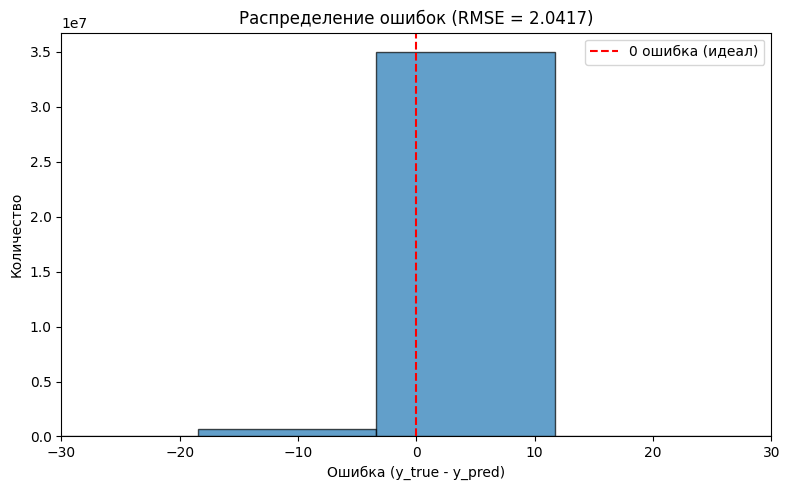

Количество ошибок > 100: 250
Процент от всех: 0.0007%
Максимальная ошибка: 600.59

Топ-5 самых больших ошибок:
16837160   600.59
20630212   550.75
8170970    312.00
20436824   304.86
107397     299.32
dtype: float64

=== Ошибки для тестовых данных: ===

Распределение ошибок:
   Mean: 0.0296
   Std:  1.8573
   Min:  -52.3209
   Max:  135.8990

Количество ошибок > 100 на: 2

Топ-5 самых больших ошибок:
30176283   135.90
30173864   103.04
30171861    94.46
19532210    77.79
4974232     77.61
dtype: float64

=== Метрики отдельных моделей по группам для test: ===
   CA_1_FOODS: RMSE_test = 2.3804
   CA_1_HOBBIES: RMSE_test = 2.1540
   CA_1_HOUSEHOLD: RMSE_test = 1.2285
   CA_2_FOODS: RMSE_test = 2.4264
   CA_2_HOBBIES: RMSE_test = 1.7106
   CA_2_HOUSEHOLD: RMSE_test = 1.3704
   CA_3_FOODS: RMSE_test = 2.6581
   CA_3_HOBBIES: RMSE_test = 2.2062
   CA_3_HOUSEHOLD: RMSE_test = 1.9005
   CA_4_FOODS: RMSE_test = 1.5993
   CA_4_HOBBIES: RMSE_test = 1.6209
   CA_4_HOUSEHOLD: RMSE_test = 0.8927
   

In [ ]:
# ============================================================
# ЗАГРУЗКА РЕЗУЛЬТАТОВ ИЗ ЧЕКПОИНТА (если нет в памяти)
# ============================================================

# Проверяем, есть ли all_results в памяти
try:
    # Если all_results уже есть в памяти — используем его
    all_results
    print(color.GREEN + color.BOLD + "all_results загружен из памяти" + color.END)
except NameError:
    # Если нет — загружаем из чекпоинта
    print(color.YELLOW + color.BOLD + "all_results не найден в памяти. Загружаем из чекпоинта..." + color.END)

    # Находим последний чекпоинт
    latest = get_latest_checkpoint(CHECKPOINT_PATH)
    if latest:
        all_results = load_checkpoint(latest)
        print(color.GREEN + color.BOLD + f"Загружен чекпоинт: {latest}" + color.END)
        print(color.GREEN + color.BOLD + f"   Всего групп: {len(all_results)}" + color.END)
    else:
        print(color.RED + color.BOLD + "Чекпоинт не найден!" + color.END)
        raise FileNotFoundError("Нет ни all_results в памяти, ни чекпоинта на диске")


# ============================================================
# 1. АНАЛИЗ И МЕТРИКИ (из словаря all_results)
# ============================================================

# Собираем все истинные значения (y_all) и предсказания (all_predictions_df) из словаря all_results
# Проходим по всем группам (CA_1_FOODS, CA_1_HOBBIES, ...) и извлекаем данные
y_all_list = []
all_preds_list = []

for group, data in all_results.items():
    # Проверяем, что модель обучилась успешно
    if data.get('status') == 'success':
        # y_all — истинные значения для train + test (все исторические данные)
        y_all_list.append(data['y_all'])
        # all_predictions_df — предсказания модели на train + test
        all_preds_list.append(data['all_predictions_df'])

# Сшиваем все группы по вертикали (складываем друг на друга)
# Получаем единый датафрейм со всеми товарами из всех групп
y_all_full = pd.concat(y_all_list, ignore_index=True)
all_preds_full = pd.concat(all_preds_list, ignore_index=True)

# СОРТИРОВКА НЕ НУЖНА ДЛЯ Series!
# y_all_full — это Series (только значения sales), у него нет id и d
# Поэтому сортировку пропускаем

# Считаем общие метрики для всего ансамбля
# RMSE на train (дни 366–1913)
train_mask = (all_preds_full['d'] >= TRAIN_START) & (all_preds_full['d'] <= TRAIN_END)
rmse_train = np.sqrt(mean_squared_error(
    y_all_full[train_mask],
    all_preds_full[train_mask]['pred']
))

# RMSE на test (дни 1914–1941)
test_mask = (all_preds_full['d'] >= TEST_START) & (all_preds_full['d'] <= TEST_END)
rmse_test = np.sqrt(mean_squared_error(
    y_all_full[test_mask],
    all_preds_full[test_mask]['pred']
))

# RMSE на всех исторических данных (train + test)
rmse_all = np.sqrt(mean_squared_error(y_all_full, all_preds_full['pred']))

print(color.BLUE + color.BOLD + f"\n=== Метрики ансамбля: ===" + color.END)
print(f"   RMSE_train (качество на обучении): {rmse_train:.4f}")   # Качество на обучении
print(f"   RMSE_test (качество на тесте):  {rmse_test:.4f}")    # ГЛАВНАЯ МЕТРИКА — качество на тесте
print(f"   RMSE_all (качество на всех исторических данных):   {rmse_all:.4f}")     # Качество на всех исторических данных

print(color.BLUE + color.BOLD + f"\n=== Ошибки для исторических данных: ===" + color.END)

# Смотрим распределение ошибок (y_true - y_pred)
# Отрицательные ошибки = модель переоценивает
# Положительные ошибки = модель недооценивает
errors = y_all_full - all_preds_full['pred']
print(color.BLUE + color.BOLD + f"\nРаспределение ошибок:" + color.END)
print(f"   Mean: {errors.mean():.4f}")   # Средняя ошибка (смещение)
print(f"   Std:  {errors.std():.4f}")    # Стандартное отклонение (разброс)
print(f"   Min:  {errors.min():.4f}")    # Минимальная ошибка
print(f"   Max:  {errors.max():.4f}")    # Максимальная ошибка

# Гистограмма ошибок
# Показывает, как распределяются ошибки модели
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Чуть приближаем шкалу, чтобы было видно основную массу ошибок
ax.set_xlim(-30, 30)

ax.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', label='0 ошибка (идеал)')
ax.set_xlabel('Ошибка (y_true - y_pred)')
ax.set_ylabel('Количество')
ax.set_title(f'Распределение ошибок (RMSE = {rmse_all:.4f})')
ax.legend()

plt.tight_layout()
plt.show()

# Смотрим, сколько ошибок больше 100
huge_errors = errors[errors > 100]
print(color.BLUE + color.BOLD + f"Количество ошибок > 100: {len(huge_errors):,}" + color.END)
print(f"Процент от всех: {len(huge_errors)/len(errors)*100:.4f}%")
print(f"Максимальная ошибка: {errors.max():.2f}")

# Покажем топ-5 таких дней
huge_errors_sorted = errors.sort_values(ascending=False)
print(color.BLUE + color.BOLD + f"\nТоп-5 самых больших ошибок:" + color.END)
print(huge_errors_sorted.head(5))

print(color.BLUE + color.BOLD + f"\n=== Ошибки для тестовых данных: ===" + color.END)

# Ошибки только на test (1914-1941)
errors_test = y_all_full[test_mask] - all_preds_full[test_mask]['pred']
print(color.BLUE + color.BOLD + f"\nРаспределение ошибок:" + color.END)
print(f"   Mean: {errors_test.mean():.4f}")
print(f"   Std:  {errors_test.std():.4f}")
print(f"   Min:  {errors_test.min():.4f}")
print(f"   Max:  {errors_test.max():.4f}")

# Количество ошибок > 100 на test
huge_errors_test = errors_test[errors_test > 100]
print(color.BLUE + color.BOLD + f"\nКоличество ошибок > 100 на: {len(huge_errors_test):,}" + color.END)

# Топ-5 самых больших ошибок на test
errors_test_sorted = errors_test.sort_values(ascending=False)
print(color.BLUE + color.BOLD + f"\nТоп-5 самых больших ошибок:" + color.END)
print(errors_test_sorted.head(5))

# Выводим метрики по каждой группе отдельно
# Чтобы увидеть, какие товары предсказываются лучше/хуже
print(color.BLUE + color.BOLD + f"\n=== Метрики отдельных моделей по группам для test: ===" + color.END)
for group, data in all_results.items():
    if data.get('status') == 'success':
        print(f"   {group}: RMSE_test = {data['rmse_test']:.4f}")

# ============================================================
# 2. ОЧИСТКА ПАМЯТИ (удаляем лишнее)
# ============================================================

# Удаляем большие объекты, которые больше не нужны для дальнейшей работы
del y_all_list, all_preds_list, y_all_full, all_preds_full
# и малые
del errors, huge_errors, huge_errors_sorted, errors_test, huge_errors_test
gc.collect()

print(color.GREEN + color.BOLD + "\nПамять очищена" + color.END)

В целом, метрика RMSE на тестовом периоде варьируется по группам в диапазоне от 1.17 до 2.66, с максимальным значением 3.56. Наблюдается устойчивая тенденция: наиболее сложными для прогнозирования оказываются категории продуктов питания, тогда как товары для дома предсказываются, как правило, точнее.

Крупные ошибки, вероятно, связаны с аномальными всплесками спроса, вызванными внешними факторами, которые могли быть не отражены в данных в принципе либо не обнаружены в рамках проведённого анализа. Такие выбросы являются скорее особенностью данных, чем свидетельством неудовлетворительной работы модели.

С учётом разреженности временных рядов, высокой доли нулевых продаж и ограниченных вычислительных мощностей, полученные метрики можно считать приемлемыми и ожидаемыми для задач данного уровня сложности.

Теперь необходимо выполнить выгрузку предсказаний на платформу Kaggle для получения оценки по официальной метрике соревнования (RMSSE), учитывающей веса товаров. Это позволит объективно оценить качество модели в рамках конкурсной задачи.

#### **Сабмит**

Самбит состоит из двух групп предсказания (1914-1941 - _validation и 1942-1969 - _evaluation), сшитых вертикально с общими для обеих групп днями-столбцами от 1 до 28.

Для удобства получения пригодного для выгрузки файла я использую находившийся в исходных пример (заполненный нолями), в который внесу полученные предсказания там, где они имеются (там, где их не будет, отсанутся ноли).

Также стоит учесть, что для всей работы я использовала файл на основе `'sales_train_eval'`, то есть все id у товаров для обоих групп будут иметь постфикс _evaluation, поэтому для группы с предсказаниями теста (дни 1914-1941) необходимо переименование id для корректного заполнени будущего сабмита.

In [ ]:
# ============================================================
# 3. ФОРМИРОВАНИЕ САБМИТА
# ============================================================

# 3.1 Повторно распаковываем архив (только сейчас, когда понадобился sample_submission)
#    Архив содержит все файлы M5, но нам нужен только sample_submission.csv
zip_path = DRIVE_BASE + 'm5-forecasting-accuracy.zip'
extract_path = '/content/m5_data'

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(color.GREEN + color.BOLD + f"Распаковка завершена! Файлы в: {extract_path}" + color.END)
except:
    print(color.RED + color.BOLD + f"Ошибка при распаковке архива" + color.END)

# Удаляем ненужные файлы (calendar, sales_train_validation, sell_prices)
# Оставляем только sample_submission.csv, чтобы не занимал место
files_to_delete = [
    '/content/m5_data/calendar.csv',
    '/content/m5_data/sales_train_validation.csv',
    '/content/m5_data/sell_prices.csv'
]

for file_path in files_to_delete:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Удалён: {file_path}")

# 3.2 Собираем test и future предсказания из словаря all_results
#    test_predictions_df — предсказания на дни 1914-1941 (validation)
#    future_predictions_recursive — предсказания на дни 1942-1969 (evaluation)
test_preds_list = []
future_preds_list = []

for group, data in all_results.items():
    if data.get('status') == 'success':
        test_preds_list.append(data['test_predictions_df'])
        future_preds_list.append(data['future_predictions_recursive'])

# Собираем предсказания по всем группам товаров в один общий датафрейм
# (каждая группа — это отдельный файл, например CA_1_FOODS, CA_1_HOBBIES и т.д.)
# (в каждой группе свои товары, поэтому они не пересекаются)
# Сшивка групп идет по вертикали, 28 дней в рамках одного типа предсказаний - общие
test_preds_full = pd.concat(test_preds_list, ignore_index=True) # последние 28 дней истории
future_preds_full = pd.concat(future_preds_list, ignore_index=True) # первые 28 дней будущего
# сортировка по id как в оригинале не требуется, так как приклеивается к шаблону маппингом
# который не зависит от порядка

# Удаляем дубликаты (если есть) — оставляем уникальные пары (id, d)
# Это необходимо для pivot, который не допускает дублирования индексов
# но им неоткуда взяться, так как группы не пересекаются по id
#test_preds_full = test_preds_full.drop_duplicates(subset=['id', 'd'], keep='first')
#future_preds_full = future_preds_full.drop_duplicates(subset=['id', 'd'], keep='first')

print(color.GREEN + color.BOLD + f"Собрано предсказаний:" + color.END)
print(f"   test (1914-1941): {len(test_preds_full):,}")
print(f"   future (1942-1969): {len(future_preds_full):,}")

# 3.3 Преобразуем формат (id, d, pred) -> (id, F1, F2, ..., F28)
#    Делаем pivot: строки = id, колонки = дни, значения = pred
def format_predictions(preds_df):
    """
    Преобразует предсказания из формата (id, d, pred) в формат сабмита (id, F1...F28)
    """
    pivot = preds_df.pivot(index='id', columns='d', values='pred')
    days = sorted(pivot.columns)
    day_to_f = {d: f'F{i+1}' for i, d in enumerate(days)}
    pivot = pivot.rename(columns=day_to_f)
    return pivot.reset_index()

test_preds_formatted = format_predictions(test_preds_full)
future_preds_formatted = format_predictions(future_preds_full)

# 3.4 Переименовываем id для validation
#    В данных все id заканчиваются на _evaluation
#    Для тестового периода (1914-1941) нужно _validation
test_preds_formatted['id'] = test_preds_formatted['id'].str.replace('_evaluation', '_validation')
# future оставляем _evaluation

# 3.5 Загружаем шаблон сабмита
#    В нём все id товаров и колонки F1-F28 с нулями
sample_submission_path = '/content/m5_data/sample_submission.csv'
sample_submission = pd.read_csv(sample_submission_path)

print(color.BLUE + color.BOLD + f"Загружен шаблон сабмита: {sample_submission.shape}" + color.END)

# ===== 3.5.1 Проверка: сколько товаров останутся нулями =====
#    Считаем отдельно для validation (1914-1941) и evaluation (1942-1969)
print(color.BLUE + color.BOLD + f"\nПроверка полноты сабмита:" + color.END)

# Всего товаров в шаблоне
total_val = sample_submission['id'].str.endswith('_validation').sum()
total_eval = sample_submission['id'].str.endswith('_evaluation').sum()

# Сколько из них имеют предсказания
print(f"   _validation: {len(test_preds_formatted):,} из {total_val:,}")
print(f"   _evaluation: {len(future_preds_formatted):,} из {total_eval:,}")

# Товары без предсказаний (нет цен → будут 0 в сабмите)
if total_val - len(test_preds_formatted) > 0:
    print(color.NEWYELLOW + color.BOLD + f"   ! {total_val - len(test_preds_formatted):,} товаров _validation будут 0" + color.END)
if total_eval - len(future_preds_formatted) > 0:
    print(color.NEWYELLOW + color.BOLD + f"   ! {total_eval - len(future_preds_formatted):,} товаров _evaluation будут 0" + color.END)
if (total_val - len(test_preds_formatted) == 0) and (total_eval - len(future_preds_formatted) == 0):
    print(color.GREEN + color.BOLD + f"   V Все товары имеют предсказания!" + color.END)

# 3.6 Заполняем шаблон нашими предсказаниями (быстро, без циклов)
#    Создаём копию шаблона, затем по id вставляем наши значения через map
submission_filled = sample_submission.copy()

# Преобразуем предсказания в формат для быстрого map
test_preds_formatted = test_preds_formatted.set_index('id')
future_preds_formatted = future_preds_formatted.set_index('id')

# Заполняем все колонки F1-F28 через map (векторизовано, быстро)
for col in submission_filled.columns[1:]:  # пропускаем 'id'
    # Берём значения из validation, если есть
    if col in test_preds_formatted.columns:
        submission_filled[col] = submission_filled['id'].map(test_preds_formatted[col]).fillna(submission_filled[col])
    # Берём значения из evaluation, если есть
    if col in future_preds_formatted.columns:
        submission_filled[col] = submission_filled['id'].map(future_preds_formatted[col]).fillna(submission_filled[col])

# 3.7 Сохраняем сабмит в папку STUDY_PATH
submission_path = f'{STUDY_PATH}submission.csv'
submission_filled.to_csv(submission_path, index=False)

print(color.GREEN + color.BOLD + f"Сабмит сохранён: {submission_path}" + color.END)
print(color.BLUE + color.BOLD + f"Размер: {submission_filled.shape}" + color.END)
print(color.BLUE + color.BOLD + f"Первые строки" + color.END)
display(submission_filled.head(10))
print(color.BLUE + color.BOLD + f"Последние строки" + color.END)
display(submission_filled.tail(10))

# ============================================================
# 4. ОЧИСТКА ПАМЯТИ (удаляем лишнее)
# ============================================================
# Удаляем большие объекты, созданные при формировании сабмита
del test_preds_list, future_preds_list
del test_preds_full, future_preds_full
del test_preds_formatted, future_preds_formatted
del sample_submission, submission_filled
# и маленькие
del total_eval, total_val
gc.collect()

print(color.GREEN + color.BOLD + "Память очищена" + color.END)

Распаковка завершена! Файлы в: /content/m5_data
Удалён: /content/m5_data/calendar.csv
Удалён: /content/m5_data/sales_train_validation.csv
Удалён: /content/m5_data/sell_prices.csv
Собрано предсказаний:
   test (1914-1941): 842,732
   future (1942-1969): 848,488
Загружен шаблон сабмита: (60980, 29)

Проверка полноты сабмита:
   _validation: 30,238 из 30,490
   _evaluation: 30,333 из 30,490
   ! 252 товаров _validation будут 0
   ! 157 товаров _evaluation будут 0
Сабмит сохранён: /content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Walmart/m5_study/submission.csv
Размер: (60980, 29)
Первые строки


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0.80,0.72,0.69,0.73,0.91,1.12,1.21,0.96,0.84,...,0.98,1.33,1.42,0.92,0.84,0.83,0.79,1.06,1.46,1.24
1,HOBBIES_1_002_CA_1_validation,0.22,0.21,0.26,0.21,0.25,0.34,0.32,0.24,0.23,...,0.19,0.27,0.37,0.30,0.30,0.33,0.28,0.34,0.41,0.40
2,HOBBIES_1_003_CA_1_validation,0.63,0.54,0.54,0.59,0.73,0.75,0.84,0.64,0.56,...,0.76,0.97,0.85,0.64,0.57,0.54,0.54,0.73,0.93,0.84
3,HOBBIES_1_004_CA_1_validation,1.77,1.50,1.50,1.62,1.87,2.52,2.58,1.78,1.88,...,1.85,2.44,2.45,1.52,1.53,1.44,1.53,1.81,2.20,2.16
4,HOBBIES_1_005_CA_1_validation,1.09,1.10,1.03,1.10,1.30,1.65,1.38,1.19,1.11,...,1.51,1.89,1.80,1.29,1.34,1.33,1.23,1.30,1.83,1.79
5,HOBBIES_1_006_CA_1_validation,0.57,0.53,0.52,0.55,0.61,0.66,0.73,0.70,0.63,...,0.86,1.10,1.13,0.73,0.66,0.73,0.72,0.83,1.23,1.22
6,HOBBIES_1_007_CA_1_validation,0.35,0.28,0.27,0.27,0.28,0.42,0.35,0.32,0.26,...,0.28,0.35,0.38,0.26,0.25,0.25,0.29,0.29,0.42,0.40
7,HOBBIES_1_008_CA_1_validation,8.52,7.68,8.18,8.35,10.12,12.03,8.20,6.95,9.39,...,8.72,10.91,6.53,8.52,6.44,8.95,9.85,9.19,9.17,5.97
8,HOBBIES_1_009_CA_1_validation,0.65,0.72,0.62,0.80,0.85,1.08,1.03,0.71,0.73,...,0.39,0.86,0.77,0.51,0.49,0.45,0.50,0.41,0.46,0.57
9,HOBBIES_1_010_CA_1_validation,0.60,0.53,0.59,0.60,0.66,0.77,0.77,0.56,0.55,...,0.61,0.67,0.65,0.56,0.48,0.56,0.57,0.69,0.75,0.73


Последние строки


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
60970,FOODS_3_818_WI_3_evaluation,1.37,1.45,1.42,1.31,1.58,1.70,1.94,1.63,1.45,...,1.77,2.44,2.41,1.52,1.94,1.95,1.41,1.56,1.81,1.79
60971,FOODS_3_819_WI_3_evaluation,1.89,1.63,1.59,1.49,1.56,1.96,1.97,1.63,1.49,...,1.80,2.36,2.41,1.54,2.07,2.15,1.51,1.70,1.83,1.81
60972,FOODS_3_820_WI_3_evaluation,1.39,1.38,1.30,1.33,1.52,1.77,1.81,1.58,1.45,...,1.75,2.31,2.45,1.45,1.96,1.91,1.46,1.55,1.86,1.79
60973,FOODS_3_821_WI_3_evaluation,1.09,0.93,0.95,0.98,1.05,1.38,1.30,0.96,0.94,...,1.21,1.77,1.83,1.09,1.38,1.46,1.00,1.16,1.39,1.43
60974,FOODS_3_822_WI_3_evaluation,1.63,1.48,1.46,1.49,1.59,2.17,1.98,1.66,1.46,...,1.69,2.38,2.52,1.53,2.06,1.99,1.44,1.57,1.89,1.91
60975,FOODS_3_823_WI_3_evaluation,0.62,0.61,0.58,0.61,0.70,0.79,0.80,0.67,0.63,...,0.78,1.02,1.06,0.68,0.87,0.87,0.64,0.73,0.78,0.76
60976,FOODS_3_824_WI_3_evaluation,0.32,0.32,0.35,0.34,0.36,0.47,0.44,0.36,0.34,...,0.40,0.53,0.53,0.31,0.40,0.40,0.30,0.37,0.44,0.40
60977,FOODS_3_825_WI_3_evaluation,0.69,0.61,0.60,0.60,0.69,0.85,0.79,0.71,0.61,...,0.83,1.01,1.01,0.67,0.92,0.84,0.61,0.70,0.75,0.79
60978,FOODS_3_826_WI_3_evaluation,1.06,1.07,0.97,0.97,1.17,1.32,1.32,1.07,1.12,...,1.28,1.76,1.78,1.16,1.56,1.48,1.03,1.17,1.39,1.36
60979,FOODS_3_827_WI_3_evaluation,1.51,1.53,1.43,1.38,1.59,1.92,1.78,1.77,1.50,...,1.76,2.47,2.41,1.69,2.26,2.22,1.66,1.72,2.07,2.05


Память очищена


Сабмит загружен на Кагл, и получены следующие результаты:

- 0.77111 Privat Score;
- 0.56721 Public Score.



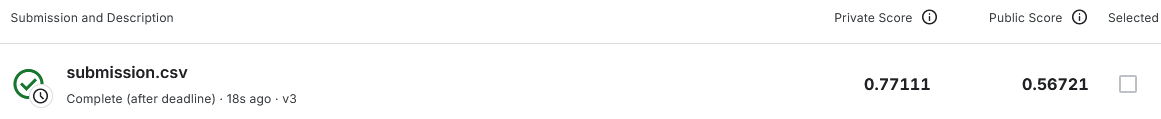

Данный сабмит (третий в истории проекта) уступает двум предыдущим, однако разница невелика. И хотя в рамках соревнования важна каждая доля, на первый план здесь выходит другой аспект. Третий вариант является наиболее честным с точки зрения подхода к подготовке данных: календарь не наращивался (в отличие от первых версий, где он наращивался ошибочно), цены не заполнялись искусственно, а праздники распределены по типам событий в соответствии с их природой, а не по повторяемости в одном из столбцов.

Именно за эту честность данная модель вынесена в финальную версию проекта в основную часть, тогда как результаты первых двух выгрузок приведены в приложении для сохранения воспроизводимости и демонстрации эволюции подхода.


*Примечание: Общая таблица результатов на Kaggle, метрика RMSEE:*

|Модель|Public Score|Private Score|
|---|---|---|
|sub 1 (первая)|0.56403|0.76447 V|
|sub 1 (вторая, up)|0.52523 V|0.78082|
|sub 1 (третья)|0.56721|0.77111|

## **Выводы**

В рамках данного проекта была реализована иерархическая модель прогнозирования продаж (для удобства называемая "ансамблем" в рамках проекта) для соревнования M5 на основе LightGBM с подбором гиперпараметров через Optuna. Основное внимание уделялось не только достижению метрики, но и честности подхода к подготовке данных — в частности, отказу от искусственного наращивания цен.

Первые две версии показали более высокие метрики, однако в них календарь наращивался вручную (и с избытком — на 28 дней больше, чем необходимо, так как в исходных данных будущие даты уже присутствовали), а цены заполнялись последними известными значениями. Третья версия, напротив, использует данные в их исходном виде и является наиболее честной с точки зрения подготовки данных.

В рамках эксперимента на одной группе было показано, что рекурсивное предсказание на тесте уступает прямому (RMSE 2.64 против 2.38), однако для будущего периода рекурсия остаётся единственным возможным подходом ввиду отсутствия реальных значений продаж.

Полученные метрики нельзя назвать высокими, однако с учётом разреженности данных (intermittent demand), высокой доли нулевых продаж и ограниченных вычислительных ресурсов результат является ожидаемым и стабильным. Наиболее сложными для прогнозирования оказались категории продуктов питания (при этом они занимали наибольшую долю в данных); товары для дома предсказываются лучше.

Ключевые отличия в подготовке данных между версиями (логика работы с календарём, ценами и праздниками, некоторые эволюционные этапы вошедших в финальный ноутбук функций) и итоговые метрики приведены в приложении. Полный код первых двух версий сохранён в черновиках и предыдущих версиях ноутбука и может быть восстановлен при необходимости.

Финальное предсказание, полученное с использованием группы моделей, достигло следующих результатов:
- RMSE на тестовом периоде (локальная оценка): 1.8575;
- RMSSE на Kaggle (официальная метрика соревнования, учитывает и тестовый и будущие периоды): 0.56721 (Public) и 0.77111 (Private).

Возможные пути улучшения:
- Изменение похода к подготвке признаков (больше лагов, скользящих средних, иная группировка праздников - каждый тип в отдельный столбец).
- Расширение сетки гиперпараметров;
- Увеличение количество trials и попыток для ранней остановки.



## **Приложение**

В данном приложении приведены ключевые фрагменты кода, использовавшиеся для получения предсказаний первой и второй выгрузок. Они демонстрируют эволюцию подхода к подготовке данных и позволяют проследить, какие изменения в итоге привели к финальной, наиболее честной версии модели. Полный код этих версий сохранён в черновиках и предыдущих версиях ноутбука.

Для исключения ошибочного запуск, код будет приведен в текстовых ячейках.

### **Подготовка для работы с моделями**

#### **`'calendar'`**

Был использован иной подход к группировке правздников: во второй столбец переместились не все культурные события, а лишь те, что переодически в него попадали. Остальные (например, вторая Пасха) также переехали в первый (как и в финальной версии).

```
# 1. Создаём пустые адаптированные столбцы
calendar[['event_name_1_adapt', 'event_type_1_adapt', 'event_name_2_adapt', 'event_type_2_adapt']] = None

# 2. Определяем события, которые требуют специального распределения
# в продакшене возможны дополнения, о работаем с теми пресечениями, которые есть
special_events = ['OrthodoxEaster', 'Easter', 'Cinco De Mayo', "Father's day"]

# 3. Копируем все остальные события из event_1 в event_1_adapt
mask_rest_1 = calendar['event_name_1'].notna() & ~calendar['event_name_1'].isin(special_events)
calendar.loc[mask_rest_1, 'event_name_1_adapt'] = calendar.loc[mask_rest_1, 'event_name_1']
calendar.loc[mask_rest_1, 'event_type_1_adapt'] = calendar.loc[mask_rest_1, 'event_type_1']

# 4. Копируем все остальные события из event_2 в event_1_adapt
mask_rest_2 = calendar['event_name_2'].notna() & ~calendar['event_name_2'].isin(special_events)
calendar.loc[mask_rest_2, 'event_name_1_adapt'] = calendar.loc[mask_rest_2, 'event_name_2']
calendar.loc[mask_rest_2, 'event_type_1_adapt'] = calendar.loc[mask_rest_2, 'event_type_2']

# 5. Расставляем специальные события по правилам
# OrthodoxEaster → event_1 (должно быть в итоге только тут)
mask_orthodox_1 = calendar['event_name_1'] == 'OrthodoxEaster'
calendar.loc[mask_orthodox_1, 'event_name_1_adapt'] = calendar.loc[mask_orthodox_1, 'event_name_1']
calendar.loc[mask_orthodox_1, 'event_type_1_adapt'] = calendar.loc[mask_orthodox_1, 'event_type_1']
# если было в исходнике в event_name_2, долно переехать в первый тип в адаптации
mask_orthodox_2 = calendar['event_name_2'] == 'OrthodoxEaster'
calendar.loc[mask_orthodox_2, 'event_name_1_adapt'] = calendar.loc[mask_orthodox_2, 'event_name_2']
calendar.loc[mask_orthodox_2, 'event_type_1_adapt'] = calendar.loc[mask_orthodox_2, 'event_type_2']

# Easter → event_2 (католическая целиком переезжает во второй)
mask_easter_1 = calendar['event_name_1'] == 'Easter'
calendar.loc[mask_easter_1, 'event_name_2_adapt'] = calendar.loc[mask_easter_1, 'event_name_1']
calendar.loc[mask_easter_1, 'event_type_2_adapt'] = calendar.loc[mask_easter_1, 'event_type_1']

mask_easter_2 = calendar['event_name_2'] == 'Easter'
calendar.loc[mask_easter_2, 'event_name_2_adapt'] = calendar.loc[mask_easter_2, 'event_name_2']
calendar.loc[mask_easter_2, 'event_type_2_adapt'] = calendar.loc[mask_easter_2, 'event_type_2']

# Cinco De Mayo → event_2
mask_cinco_1 = calendar['event_name_1'] == 'Cinco De Mayo'
calendar.loc[mask_cinco_1, 'event_name_2_adapt'] = calendar.loc[mask_cinco_1, 'event_name_1']
calendar.loc[mask_cinco_1, 'event_type_2_adapt'] = calendar.loc[mask_cinco_1, 'event_type_1']

mask_cinco_2 = calendar['event_name_2'] == 'Cinco De Mayo'
calendar.loc[mask_cinco_2, 'event_name_2_adapt'] = calendar.loc[mask_cinco_2, 'event_name_2']
calendar.loc[mask_cinco_2, 'event_type_2_adapt'] = calendar.loc[mask_cinco_2, 'event_type_2']

# Father's day → event_2
mask_father_1 = calendar['event_name_1'] == "Father's day"
calendar.loc[mask_father_1, 'event_name_2_adapt'] = calendar.loc[mask_father_1, 'event_name_1']
calendar.loc[mask_father_1, 'event_type_2_adapt'] = calendar.loc[mask_father_1, 'event_type_1']

mask_father_2 = calendar['event_name_2'] == "Father's day"
calendar.loc[mask_father_2, 'event_name_2_adapt'] = calendar.loc[mask_father_2, 'event_name_2']
calendar.loc[mask_father_2, 'event_type_2_adapt'] = calendar.loc[mask_father_2, 'event_type_2']

# 6. Проверка
print(color.BLUE + color.BOLD + f"=== Проверка распределения ===\n"+ color.END)
print("OrthodoxEaster в event_1_adapt:", (calendar['event_name_1_adapt'] == 'OrthodoxEaster').sum())
print("Easter в event_2_adapt:", (calendar['event_name_2_adapt'] == 'Easter').sum())
print("Cinco De Mayo в event_2_adapt:", (calendar['event_name_2_adapt'] == 'Cinco De Mayo').sum())
print("Father's day в event_2_adapt:", (calendar['event_name_2_adapt'] == "Father's day").sum())
```
```
=== Проверка распределения ===

OrthodoxEaster в event_1_adapt: 6
Easter в event_2_adapt: 6
Cinco De Mayo в event_2_adapt: 6
Father's day в event_2_adapt: 6
```

#### **Расширение данных**

В первых двух сабмитах я упустила, что доступные в календаре и ценах данные перекрывают весь необходимый период, и ошибочно нарастила календарь еще на 28 дней (добавив вручную один праздник, а snap беря из годового лага), а также ошибочно наростила на 28 дней вперед цены (заполняя пропуски послежними известными ценами, что таже привело к заполнению неизвестных цен и в нужный для предскзания будущего период).

```
# ============================================================
# 1. ДОБАВЛЯЕМ БУДУЩИЕ ДНИ, ИСПОЛЬЗУЯ date
# ============================================================
# Определяем последние дату и неделю в календаре
last_date = calendar['date'].max()  # по describe выходит 2016-06-19 00:00:00
last_week = calendar['wm_yr_wk'].max() # 11621.00

# Создаём будущие даты (28 дней)
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=28, freq='D')
# будущие недели (4 недели)
future_weeks = list(range(last_week + 1, last_week + 5))

# Создаём список для будущих дней
future_calendar = []
for i, date in enumerate(future_dates):
    d = 1942 + i
    week_index = i // 7  # 0, 1, 2, 3 (каждые 7 дней — новая неделя)
    wm_yr_wk = future_weeks[week_index]

    # SNAP — копируем из прошлого года, но лучше брать истинные данные при наличии
    d_past = d - 365
    past_row = calendar[calendar['d'] == d_past]

    if len(past_row) > 0:
        snap_CA = past_row['snap_CA'].values[0]
        snap_TX = past_row['snap_TX'].values[0]
        snap_WI = past_row['snap_WI'].values[0]
    else:
        snap_CA = False
        snap_TX = False
        snap_WI = False

    future_calendar.append({
        'd': d,
        'date': date,
        'wday': (date.dayofweek + 2) % 7 + 1,  # так как первый день в данных - суббота
        'month': date.month,
        'wm_yr_wk': wm_yr_wk,
        'event_name_1_adapt': 'None',
        'event_type_1_adapt': 'None',
        'event_name_2_adapt': 'None',
        'snap_CA': snap_CA,
        'snap_TX': snap_TX,
        'snap_WI': snap_WI
    })

# === СОЗДАЁМ DATAFRAME (СНАЧАЛА БЕЗ КАТЕГОРИЙ) ===
future_calendar = pd.DataFrame(future_calendar)

# ============================================================
# 2. ДОБАВЛЯЕМ ПРАЗДНИКИ ВРУЧНУЮ
# ============================================================
# Independence Day — 4 июля 2016 (d_1956)
future_calendar.loc[future_calendar['d'] == 1956, 'event_name_1_adapt'] = 'IndependenceDay'
future_calendar.loc[future_calendar['d'] == 1956, 'event_type_1_adapt'] = 'National'

# ============================================================
# 3. ПРИВОДИМ ТИПЫ (КРОМЕ КАТЕГОРИЙ, они при concat всё равно станут object)
# ============================================================
future_calendar = future_calendar.astype({
    'd': 'uint16',
    'wday': 'uint8',
    'month': 'uint8',
    'wm_yr_wk': 'uint16',
    'snap_CA': 'bool',
    'snap_TX': 'bool',
    'snap_WI': 'bool'
})

# ============================================================
# 4. ОБЪЕДИНЯЕМ
# ============================================================
calendar_extended = pd.concat([calendar, future_calendar], ignore_index=True)

# === ПРЕОБРАЗУЕМ В КАТЕГОРИИ ПОСЛЕ ОБЪЕДИНЕНИЯ ===
calendar_extended[['event_name_1_adapt', 'event_type_1_adapt', 'event_name_2_adapt']] = \
    calendar_extended[['event_name_1_adapt', 'event_type_1_adapt', 'event_name_2_adapt']].astype('category')

# Вычисляем n_events
calendar_extended['n_events'] = (
    (calendar_extended['event_name_1_adapt'] != 'None').astype(int) +
    (calendar_extended['event_name_2_adapt'] != 'None').astype(int)
).astype('uint8')

# можно было было бы удалить лишнее исходные данные здесь,
# но на случай ошибки удаляю позже
print(color.GREEN + color.BOLD + f" V Календарь расширен до {calendar_extended['d'].max()} дня" + color.END)

# ============================================================
# УДАЛЯЕМ date ИЗ calendar_extended
# ============================================================
calendar_extended = calendar_extended.drop('date', axis=1)
print(color.GREEN + color.BOLD + f"V Столбец 'date' удалён из календаря" + color.END)

```

Проверка через функцию first_discr (можно заметить увеличение размера больше необходимого).

```
=== Общая информация о данных в calendar_extended: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   wm_yr_wk            1997 non-null   uint16  
 1   wday                1997 non-null   uint8   
 2   month               1997 non-null   uint8   
 3   d                   1997 non-null   uint16  
 4   n_events            1997 non-null   uint8   
 5   event_name_1_adapt  1997 non-null   category
 6   event_type_1_adapt  1997 non-null   category
 7   event_name_2_adapt  1997 non-null   category
 8   snap_CA             1997 non-null   bool    
 9   snap_TX             1997 non-null   bool    
 10  snap_WI             1997 non-null   bool    
dtypes: bool(3), category(3), uint16(2), uint8(3)
memory usage: 27.2 KB

None


 === Размер датасета calendar_extended:===
    (1997, 11)

```


```
# ============================================================
# 5. РАСШИРЯЕМ ЦЕНЫ
# ============================================================
# Берём последние цены для каждого товара/магазина
last_prices = sell_prices.groupby(['item_id', 'store_id']).last().reset_index()

# Создаём будущие цены (сразу с правильными типами)
future_price_rows = []
for week in future_weeks:  # ← ИСПОЛЬЗУЕМ УЖЕ СОЗДАННУЮ ранее future_weeks
    for _, row in last_prices.iterrows():
        future_price_rows.append({
            'item_id': row['item_id'],     # ID товара
            'store_id': row['store_id'],   # ID магазина
            'wm_yr_wk': week,              # Будущая неделя
            'sell_price': row['sell_price']  # Цена (копируем последнюю известную)
        })

# Создаём DataFrame с правильными типами (как в исходных данных)
future_prices = pd.DataFrame(future_price_rows).astype({
    'store_id': 'category',
    'item_id': 'object',
    'wm_yr_wk': 'uint16',
    'sell_price': 'float16'
})

# Объединяем исторические и будущие цены
sell_prices_extended = pd.concat([sell_prices, future_prices], ignore_index=True)

# Сортируем как в исходных данных (по магазину, товару, неделе)
sell_prices_extended = sell_prices_extended.sort_values(
    ['store_id', 'item_id', 'wm_yr_wk']
).reset_index(drop=True)

# Можно было бы удалить исходные данные здесь,
# но на случай ошибки удаляю позже (после проверки)
print(color.GREEN + color.BOLD + f" V Цены расширены до {sell_prices_extended['wm_yr_wk'].max()} недели" + color.END)
```
Проверка через функцию first_discr

```

 === Общая информация о данных в sell_prices_extended: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6963081 entries, 0 to 6963080
Data columns (total 4 columns):
 #   Column      Dtype   
---  ------      -----   
 0   store_id    category
 1   item_id     object  
 2   wm_yr_wk    uint16  
 3   sell_price  float16
dtypes: category(1), float16(1), object(1), uint16(1)
memory usage: 86.3+ MB

None


 === Размер датасета sell_prices_extended:===
    (6963081, 4)
```

Расширение датасета с продажами проходило аналогично Sub 3.

### **Работа с моделями**

Касается работы с моделями (одиночными и группой).

#### **Работа с моделью**

##### **Пути**

**Sub 1**

```
# ============================================================
# ГЛОБАЛЬНЫЕ ПУТИ
# ============================================================
DRIVE_BASE = '/content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Walmart/'

# Папки внутри
MODELS_PATH = DRIVE_BASE + 'm5_models_data/' # Агрегированные данные (файлы для обучения моделей)
PROCESSED_PATH = DRIVE_BASE + 'm5_processed_data/'#  Подготовленные исходные данные (обработанные версии исходных CSV)

# Работа с первой моделью (с удалением строк с пропусками)
# Папка для сохранения всех результатов исследования
STUDY_PATH = f'{DRIVE_BASE}m5_study/'
# Папка для чекпоинтов (внутри STUDY_PATH)
CHECKPOINT_PATH = f'{STUDY_PATH}checkpoints/'
```

**Sub 2**
```
# ============================================================
# НОВАЯ ПАПКА ДЛЯ УЛУЧШЕННОЙ ВЕРСИИ
# ============================================================

#STUDY_PATH_UP = f'{DRIVE_BASE}m5_study_up/'
#CHECKPOINT_PATH_UP = f'{STUDY_PATH_UP}checkpoints/'

# Создаём папки
os.makedirs(STUDY_PATH_UP, exist_ok=True)
os.makedirs(CHECKPOINT_PATH_UP, exist_ok=True)

print(color.GREEN + color.BOLD + f"Создана папка для улучшенной версии: {STUDY_PATH_UP}" + color.END)
```

##### **Подготовка данных**

**Sub 1**

Ключевое отличие Sub 1 от Sub 2
```  
# ===== 5. Удаляем строки с NaN (первые 365 дней) =====
    df = df.dropna()
```
Данный подход совпадает с таковым для Sub 3.

```
# подготовка данных для работы с моделью
# взяла и 28 и 30 под месяц,
# так как 28 - по недельным циклам, а 30 ближе к календарному
def prepare_data(file_name,
                 lags=LAGS,        # используем глобальную переменную
                 windows=WINDOWS): # используем глобальную переменную
    """
    Загружает файл, добавляет лаги и скользящие средние,
    удаляет пропуски.

    Returns:
        dict: df, group_name, feature_names
    """

    # ===== 1. Загрузка =====
    path_content = f'/content/{file_name}'
    path_drive = f'{MODELS_PATH}{file_name}'

    try:
        if os.path.exists(path_content):
            df = pd.read_parquet(path_content)
            print(color.GREEN + color.BOLD + f"V Загружен из /content/: {file_name}" + color.END)
        else:
            df = pd.read_parquet(path_drive)
            print(color.GREEN + color.BOLD + f"V Загружен с Google Диска: {file_name}" + color.END)
    except Exception as e:
        print(color.RED + color.BOLD + f"X Ошибка загрузки {file_name}: {e}" + color.END)
        return None

    group_name = file_name.replace('m5_data_', '').replace('.parquet', '')

    # ===== 2. Сортировка (обязательно для shift!) =====
    # ВНИМАНИЕ! В M5 данные уже отсортированы по (d, id),
    # но sort_values(['id', 'd']) пересортирует их в порядок (id, d)
    # Это гарантирует, что внутри каждого id дни идут последовательно
    # и shift() будет работать корректно
    # но так как есть уверенность в правильном порядке данных, не пересортировываю
    # df = df.sort_values(['id', 'd'])

    # ===== 3. Добавляем лаги =====
    for lag in lags:
        # продажи
        df[f'sales_lag_{lag}'] = df.groupby('id', observed=True)['sales'].shift(lag)
        # цены
        df[f'sell_price_lag_{lag}'] = df.groupby('id', observed=True)['sell_price'].shift(lag)

    # ===== 4. Добавляем скользящие средние =====
    for window in windows:
        # продажи
        df[f'sales_ma_{window}'] = df.groupby('id', observed=True)['sales'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        # цены
        df[f'sell_price_ma_{window}'] = df.groupby('id', observed=True)['sell_price'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )

    # ===== 5. Удаляем строки с NaN (первые 365 дней) =====
    df = df.dropna()

    # ===== 6. Определяем признаки =====
    # не участвуют в предсказании
    exclude_cols = EXCLUDE_COLS
    # нужны для предсказания
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    print(color.BLUE + color.BOLD + f"   {group_name}: Всего строк {len(df):,}, Признаков для предсказания {len(feature_cols)}" + color.END)

    # ===== 7. Возвращаем результат =====
    return {
        'df': df,  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
        'group_name': group_name,
        #'feature_names': feature_cols # дальше не используется
    }


**Sub 2**

Ключевое отличие Sub 2 от Sub 1 (и Sub 3)

```
    # ===== 5. Удаляем строки с NaN (первые 365 дней) =====
    # Удаляем только NaN от лагов продаж (первые 365 дней)
    # sell_price = NaN оставляем — LightGBM сам с ними справится
    lag_cols = [f'sales_lag_{lag}' for lag in lags]
    df = df.dropna(subset=lag_cols)
```

```
# не удаляем строки с пропусками цен
# подготовка данных для работы с моделью
# взяла и 28 и 30 под месяц,
# так как 28 - по недельным циклам, а 30 ближе к календарному
def prepare_data(file_name,
                 lags=LAGS,        # используем глобальную переменную
                 windows=WINDOWS): # используем глобальную переменную
    """
    Загружает файл, добавляет лаги и скользящие средние,
    удаляет пропуски.

    Returns:
        dict: df, group_name
    """

    # ===== 1. Загрузка =====
    path_content = f'/content/{file_name}'
    path_drive = f'{MODELS_PATH}{file_name}'

    try:
        if os.path.exists(path_content):
            df = pd.read_parquet(path_content)
            print(color.GREEN + color.BOLD + f"V Загружен из /content/: {file_name}" + color.END)
        else:
            df = pd.read_parquet(path_drive)
            print(color.GREEN + color.BOLD + f"V Загружен с Google Диска: {file_name}" + color.END)
    except Exception as e:
        print(color.RED + color.BOLD + f"X Ошибка загрузки {file_name}: {e}" + color.END)
        return None

    group_name = file_name.replace('m5_data_', '').replace('.parquet', '')

    # ===== 2. Сортировка (обязательно для shift!) =====
    # ВНИМАНИЕ! В M5 данные уже отсортированы по (d, id),
    # но sort_values(['id', 'd']) пересортирует их в порядок (id, d)
    # Это гарантирует, что внутри каждого id дни идут последовательно
    # и shift() будет работать корректно
    # но так как есть уверенность в правильном порядке данных, не пересортировываю
    # df = df.sort_values(['id', 'd'])

    # ===== 3. Добавляем лаги =====
    for lag in lags:
        # продажи
        df[f'sales_lag_{lag}'] = df.groupby('id', observed=True)['sales'].shift(lag)
        # цены
        df[f'sell_price_lag_{lag}'] = df.groupby('id', observed=True)['sell_price'].shift(lag)

    # ===== 4. Добавляем скользящие средние =====
    for window in windows:
        # продажи
        df[f'sales_ma_{window}'] = df.groupby('id', observed=True)['sales'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        # цены
        df[f'sell_price_ma_{window}'] = df.groupby('id', observed=True)['sell_price'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )

    # ===== 5. Удаляем строки с NaN (первые 365 дней) =====
    # Удаляем только NaN от лагов продаж (первые 365 дней)
    # sell_price = NaN оставляем — LightGBM сам с ними справится
    lag_cols = [f'sales_lag_{lag}' for lag in lags]
    df = df.dropna(subset=lag_cols)

    # ===== 6. Определяем признаки =====
    # не участвуют в предсказании
    exclude_cols = EXCLUDE_COLS
    # нужны для предсказания
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    print(color.BLUE + color.BOLD + f"   {group_name}: Всего строк {len(df):,}, Признаков для предсказания {len(feature_cols)}" + color.END)

    # ===== 7. Возвращаем результат =====
    return {
        'df': df,  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
        'group_name': group_name,
        #'feature_names': feature_cols # дальше не используется
    }
```

##### **Рекурсивное предсказание**

**Общие**

Не было дополнительной оптимизации типов возвращаемых данных.

```
def recursive_forecast_simple(model, X_future, X_history, feature_cols):
    """
    Рекурсивное предсказание для будущих дней (оптимизированная версия).

    Parameters:
        model: обученная модель LightGBM
        X_future: DataFrame с признаками для будущих дней (d_1942–d_1969)
        X_history: DataFrame с историческими данными (train + test)
        feature_cols: список признаков для модели

    Returns:
        DataFrame с колонками: id, d, pred
    """

    # ===== 1. СОЗДАЁМ КОПИЮ ДЛЯ ПРЕДСКАЗАНИЙ =====
    # Копируем X_future, чтобы не изменять исходные данные
    X_future_rec = X_future.copy()
    # Добавляем колонку для предсказаний
    X_future_rec['pred'] = 0.0

    # ===== 2. ПОЛУЧАЕМ СПИСОК УНИКАЛЬНЫХ ТОВАРОВ =====
    # Для каждого товара будем хранить свою историю продаж
    ids = X_future_rec['id'].unique()

    # ===== 3. СТРОИМ ИСТОРИЮ ПРОДАЖ ДЛЯ КАЖДОГО ТОВАРА =====
    # Храним последние 365 дней продаж для каждого товара
    # Это нужно для обновления лагов и скользящих средних
    history_dict = {}
    for id_val in ids:
        # Берём последние 365 дней продаж из истории
        history = X_history[X_history['id'] == id_val]['sales'].tail(365).tolist()
        # Если истории нет (такого не должно быть), заполняем средним
        if not history:
            history = [X_history['sales'].mean()] * 365
        history_dict[id_val] = history

    # ===== 4. ПОЛУЧАЕМ СПИСОК ДНЕЙ =====
    # Сортируем дни, чтобы предсказывать последовательно
    days = sorted(X_future_rec['d'].unique())

    # ===== 5. РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ПО ДНЯМ =====
    # Для каждого дня предсказываем все товары сразу (батчем)
    for d in days:
        # 5.1 Получаем индексы строк для текущего дня
        day_mask = X_future_rec['d'] == d
        day_indices = X_future_rec[day_mask].index

        # Если нет товаров в этот день, пропускаем
        if len(day_indices) == 0:
            continue

        # 5.2 Обновляем лаги и скользящие средние для всех товаров этого дня
        # Для каждого товара обновляем признаки на основе последних продаж из истории
        for idx in day_indices:
            id_val = X_future_rec.loc[idx, 'id']
            history = history_dict[id_val]

            # Обновляем лаги продаж (1, 7, 14, 28, 30, 365 дней назад)
            for lag in [1, 7, 14, 28, 30, 365]:
                col = f'sales_lag_{lag}'
                if col in X_future_rec.columns:
                    # Берём значение из истории на соответствующем шаге назад
                    if lag <= len(history):
                        X_future_rec.loc[idx, col] = history[-lag]
                    else:
                        X_future_rec.loc[idx, col] = history[-1]

            # Обновляем скользящие средние продаж
            for window in [7, 14, 28, 30, 365]:
                col = f'sales_ma_{window}'
                if col in X_future_rec.columns:
                    # Считаем среднее за последние window дней
                    if len(history) >= window:
                        X_future_rec.loc[idx, col] = sum(history[-window:]) / window
                    else:
                        X_future_rec.loc[idx, col] = sum(history) / len(history) if history else 0

        # 5.3 БАТЧЕВОЕ ПРЕДСКАЗАНИЕ (ВСЕ ТОВАРЫ ДНЯ ЗА ОДИН РАЗ)
        # Берём DataFrame для всего дня — категории сохраняются!
        X_batch = X_future_rec.loc[day_indices, feature_cols].copy()

        # Предсказываем сразу для всех товаров дня
        # Это в 10-20 раз быстрее, чем предсказывать по одному
        preds = model.predict(X_batch)

        # 5.4 Обновляем предсказания и историю
        for i, idx in enumerate(day_indices):
            id_val = X_future_rec.loc[idx, 'id']
            pred = preds[i]

            # Сохраняем предсказание
            X_future_rec.loc[idx, 'pred'] = pred

            # Обновляем историю продаж для этого товара
            # Добавляем предсказанное значение для следующего дня
            history = history_dict[id_val]
            history.append(pred)
            # Оставляем только последние 365 дней (экономия памяти)
            if len(history) > 365:
                history = history[-365:]
            history_dict[id_val] = history

    # ===== 6. ВОЗВРАЩАЕМ РЕЗУЛЬТАТ =====
    # Возвращаем только id, d и предсказания
    return X_future_rec[['id', 'd', 'pred']]

```

#### **Подготовка к ансамблю (одиночная модель)**

**Sub 2**

Одиночная не обучалась

#####**Функция обучения модели**

**Sub 1**

Закомменченные варианты гиперпараметров не были применены из-за увеличения вычислительной нагрузки и продолжительночти обучения.

```
# функция для обучения моделей
# упрощенный вариант, для ручного запуска
# цикл неудобен, так как что-то может упасть
def train_lgbm(df,
               train_start=TRAIN_START,  # 366, Первый день для обучения (после удаления NaN)
               train_end=TRAIN_END,   #1913,  Последний день для обучения
               test_start=TEST_START,  # 1914, Первый день для теста
               test_end=TEST_END,    # 1941, Последний день для теста
               future_start=FUTURE_START, # 1942, Первый день для будущего (сабмит)
               future_end=FUTURE_END,  # 1969, Последний день для будущего (сабмит)
               n_trials=5,       # Количество итераций Optuna (5 — для скорости, 15-30 — для качества)
               random_state=RANDOM_STATE): # Для воспроизводимости результатов
    """
    Обучает модель LightGBM с подбором гиперпараметров через Optuna.
    Разбивка на train/test происходит ВНУТРИ функции.

    Parameters:
        df: подготовленный DataFrame с признаками
        train_start, train_end: границы тренировочного периода
        test_start, test_end: границы тестового периода
        future_start, future_end: границы будущего периода (сабмит)
        n_trials: количество итераций Optuna
        random_state: для воспроизводимости результатов

    Returns:
        dict: модель, метрики, предсказания, параметры
        - model: обучена на train
        - model_full: обучена на train + test
        - метрики для обеих моделей
        - предсказания для train, test, future (рекурсивные)
    """

    # ===== 0. Разбиваем данные =====
    train = df[(df['d'] >= train_start) & (df['d'] <= train_end)]
    test = df[(df['d'] >= test_start) & (df['d'] <= test_end)]
    X_future = df[(df['d'] >= future_start) & (df['d'] <= future_end)].copy()
    # Удаляем sales (целевая переменная) — для будущего она неизвестна
    X_future = X_future.drop('sales', axis=1)

    X_train = train
    y_train = train['sales']
    X_test = test
    y_test = test['sales']

    # ===== 1. Определяем категориальные признаки =====
    # LightGBM умеет работать с категориями напрямую (быстрее и точнее one-hot)
    # Это столбцы, которые содержат не числа, а категории (день недели, месяц, события)
    # Используем глобальный список CAT_FEATURES
    # Оставляем только те, которые реально есть в данных (если вдруг удалили)
    cat_features = [col for col in CAT_FEATURES if col in X_train.columns]

    # ===== 2. Создаём валидацию ПО ВРЕМЕНИ =====
    # ВАЖНО: НЕ используем TimeSeriesSplit, потому что он перемешивает товары!
    # Вместо этого фильтруем по столбцу 'd' (номер дня)
    # Все товары участвуют и в обучении, и в валидации, но в РАЗНЫЕ дни

    # train у нас: d от 366 до 1913
    # Берём последние 28 дней train как валидацию (как в тесте — 28 дней)
    val_end = train_end         # Конец периода валидации (последний день train, 1913)
    val_start = val_end - 28    # Начало периода валидации (последние 28 дней train)

    print(color.BLUE + color.BOLD + f"   Train: дни {train_start}–{train_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Test: дни {test_start}–{test_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Валидация: дни {val_start}–{val_end}" + color.END)

    # ===== 3. Функция цели для Optuna =====
    # Optuna будет вызывать эту функцию n_trials раз с разными параметрами
    # Задача: найти параметры, которые дают минимальный RMSE на валидации
    def objective(trial):
        """
        Функция, которую Optuna оптимизирует.
        Возвращает RMSE на валидации.
        """

        # ===== 3.1 Определяем пространство поиска гиперпараметров =====
        # trial.suggest_* — предлагает значение в указанном диапазоне
        # Логарифмическая шкала (log=True) лучше для параметров с большим разбросом

        params = {
            # Количество деревьев в ансамбле (чем больше, тем лучше, но дольше)
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            #'n_estimators': trial.suggest_int('n_estimators', 100, 400),  # расширенный диапазон

            # Скорость обучения (learning_rate * n_estimators ≈ эффективная сложность)
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
            #'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),  # расширенный диапазон

            # Количество листьев — ГЛАВНЫЙ параметр сложности LightGBM
            # Чем больше листьев, тем сложнее модель (риск переобучения)
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            #'num_leaves': trial.suggest_int('num_leaves', 20, 150),  # расширенный диапазон

            # Максимальная глубина дерева (ограничивает рост, регуляризация)
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            #'max_depth': trial.suggest_int('max_depth', 3, 15),  # расширенный диапазон

            # ===== ФУНКЦИЯ ПОТЕРЬ ДЛЯ INTERMITTENT DEMAND =====
            # Tweedie — подходит для данных с большим количеством нулей (наш случай!)
            # variance_power — контролирует распределение: 1.5 — хорошее значение по умолчанию
            'objective': 'tweedie',
            'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.9),

            # L1 регуляризация (лассо) — зануляет неважные признаки
            'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 1.0, log=True),

            # L2 регуляризация (ридж) — штрафует большие веса
            'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 1.0, log=True),

            # Доля объектов для обучения каждого дерева
            # < 1.0 — увеличивает разнообразие деревьев (борьба с переобучением)
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),

            # Доля признаков для обучения каждого дерева
            # < 1.0 — уменьшает корреляцию между деревьями
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

            # Минимальное количество объектов в листе
            # Больше → более простые деревья (регуляризация)
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),

            # Фиксируем random_state для воспроизводимости
            'random_state': random_state,

            # Отключаем вывод (чтобы не засорять логи)
            'verbosity': -1,

            # force_row_wise=True — быстрее для больших данных
            'force_row_wise': True,

            # n_jobs=-1 — используем все ядра процессора
            'n_jobs': -1
        }

        model = lgb.LGBMRegressor(**params)

        # Признаки для модели (все, кроме служебных столбцов и целевого)
        exclude_cols = EXCLUDE_COLS
        feature_cols = [col for col in X_train.columns if col not in exclude_cols]

        # ===== 3.2 ВАЖНО: валидация по d, а не по индексу! =====
        # Все товары участвуют, но берём только нужные дни
        # Это НЕ перемешивает товары внутри фолдов

        # Обучаем на ВСЕХ товарах, но только на днях ДО val_start
        X_tr = X_train[X_train['d'] < val_start]
        y_tr = y_train[X_train['d'] < val_start]

        # Валидация на последних 28 днях train (все товары)
        X_val = X_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]
        y_val = y_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]

        # Явно указываем категориальные признаки
        categorical_features = [col for col in cat_features if col in feature_cols]

        # Обучаем модель с ранней остановкой (используем ТОЛЬКО признаки)
        model.fit(
            X_tr[feature_cols], y_tr,
            eval_set=[(X_val[feature_cols], y_val)],  # Данные для контроля переобучения
            eval_metric='rmse',         # Метрика для ранней остановки
            categorical_feature=categorical_features,  # ← ЯВНО УКАЗЫВАЕМ!
            callbacks=[
                #lgb.early_stopping(15),  # Остановка, если 15 итераций без улучшения
                lgb.early_stopping(10),  # более строгая ранняя остановка
                lgb.log_evaluation(0)    # 0 — отключаем вывод
            ]
        )

        # Предсказываем на валидации
        preds = model.predict(X_val[feature_cols])
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse  # Optuna будет минимизировать это значение

    # ===== 4. Запуск Optuna =====
    print(color.BLUE + color.BOLD + "   Оптимизация гиперпараметров..." + color.END)

    # Создаём объект study для оптимизации
    study = optuna.create_study(
        direction='minimize',  # Минимизируем RMSE
        sampler=optuna.samplers.RandomSampler(seed=random_state)  # Случайный поиск
    )

    # Запускаем оптимизацию на n_trials итераций
    # show_progress_bar=False — отключаем прогресс-бар (он может тормозить)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    # Получаем лучшие параметры и лучшее значение RMSE
    best_params = study.best_params
    best_rmse = study.best_value

    print(color.GREEN + color.BOLD + f"   Лучший RMSE (CV): {best_rmse:.4f}" + color.END)
    print(color.BLUE + color.BOLD + f"   Лучшие параметры: {best_params}" + color.END)

    # ===== 5. Финальные параметры =====
    final_params = {
        **best_params,  # Распаковываем лучшие параметры
        'random_state': random_state,
        'verbosity': -1,
        'force_row_wise': True,
        'n_jobs': -1
    }

    feature_cols = [col for col in X_train.columns if col not in EXCLUDE_COLS]
    categorical_features = [col for col in cat_features if col in feature_cols]

    # ============================================================
    # БЛОК 1: МОДЕЛЬ НА TRAIN (только train, без test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 1/2] Обучение на train..." + color.END)

    model = lgb.LGBMRegressor(**final_params)
    model.fit(
        X_train[feature_cols], y_train,
        eval_set=[(X_train[feature_cols], y_train)],
        eval_metric='rmse',
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model (на train и test)
    preds_train = model.predict(X_train[feature_cols])
    preds_test = model.predict(X_test[feature_cols])

    # DataFrames с предсказаниями для model
    train_predictions_df = X_train[['id', 'd']].copy()
    train_predictions_df['pred'] = preds_train

    test_predictions_df = X_test[['id', 'd']].copy()
    test_predictions_df['pred'] = preds_test

    # Метрики для model
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))

    print(color.GREEN + color.BOLD + f"   RMSE_train: {rmse_train:.4f}" + color.END)
    print(color.GREEN + color.BOLD + f"   RMSE_test:  {rmse_test:.4f}" + color.END)

    # ============================================================
    # БЛОК 2: МОДЕЛЬ НА ВСЕХ ИСТОРИЧЕСКИХ ДАННЫХ (train + test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 2/2] Обучение на всех исторических данных (train + test)..." + color.END)

    # Берём исторические данные напрямую из df
    X_all = df[(df['d'] >= train_start) & (df['d'] <= test_end)]
    y_all = X_all['sales']

    model_full = lgb.LGBMRegressor(**final_params)
    model_full.fit(
        X_all[feature_cols], y_all,
        eval_set=[(X_all[feature_cols], y_all)],
        eval_metric='rmse',
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model_full (на всех исторических)
    preds_train_full = model_full.predict(X_all[feature_cols])

    # DataFrame с предсказаниями для model_full
    all_predictions_df = X_all[['id', 'd']].copy()
    all_predictions_df['pred'] = preds_train_full

    # Метрика для model_full
    rmse_train_full = np.sqrt(mean_squared_error(y_all, preds_train_full))

    print(color.GREEN + color.BOLD + f"   RMSE_train_full: {rmse_train_full:.4f}" + color.END)

    # ============================================================
    # БЛОК 3: РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ДЛЯ БУДУЩЕГО
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Рекурсия] Предсказание для будущего..." + color.END)

    # Берём историю напрямую из df — категории уже правильные!
    X_history = df[(df['d'] >= train_start) & (df['d'] <= test_end)]

    future_preds_recursive = recursive_forecast_simple(
        model_full, X_future, X_history, feature_cols
        # categorical_features больше не нужен — категории уже правильные!
    )

    print(color.GREEN + color.BOLD + f"   Будущих рекурсивных предсказаний: {len(future_preds_recursive):,}" + color.END)

    # ============================================================
    # БЛОК 4: ВОЗВРАТ РЕЗУЛЬТАТОВ
    # ============================================================
    return {
        'model': model,                      # Модель на train
        'model_full': model_full,            # Модель на train + test

        'rmse_train': rmse_train,            # RMSE на train (model)
        'rmse_test': rmse_test,              # RMSE на test (model) — ГЛАВНАЯ МЕТРИКА
        'rmse_train_full': rmse_train_full,  # RMSE на train + test (model_full)

        'best_rmse_cv': best_rmse,           # Лучший RMSE на валидации
        'best_params': best_params,          # Лучшие гиперпараметры

        'train_predictions_df': train_predictions_df,   # train (model)
        'test_predictions_df': test_predictions_df,     # test (model)
        'all_predictions_df': all_predictions_df,       # train + test (model_full)
        'future_predictions_recursive': future_preds_recursive,  # сабмит
        #'study': study                       # Объект study (для анализа Optuna)
    }
```




##### **Пайплайн**

 **Sub 1**
```
# объединяющая функция
def run_pipeline(file_name, results_dict, n_trials=5):
    """
    Запускает полный пайплайн: загрузка → подготовка → обучение → сохранение.

    Parameters:
        file_name: str — имя файла (например, 'm5_data_CA_1_FOODS.parquet')
        results_dict: dict — словарь для накопления результатов всех моделей
        n_trials: int — количество итераций Optuna (по умолчанию 5)

    Returns:
        dict: обновлённый словарь с результатами
    """

    # ===== 1. ПОДГОТОВКА ДАННЫХ =====
    # Вызываем функцию, которая загружает файл, добавляет лаги и скользящие средние,
    # удаляет пропуски
    print(color.BLUE + color.BOLD + "\n[1/3] Подготовка данных..." + color.END)
    data = prepare_data(file_name)  # ← СНАЧАЛА определяем data!

    # Если данные не загрузились — prepare_data() уже вывела ошибку
    # Просто выходим из функции, ничего не сохраняя
    if data is None:
        return results_dict

    # Распаковываем данные (извлекаем DataFrame и group_name из словаря)
    df = data['df']  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
    group_name = data['group_name']  # ← используем из prepare_data

    # Разделитель для наглядности в логах
    print(color.NEWYELLOW + color.BOLD + f"\n{'='*60}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"Запуск пайплайна для группы: {group_name}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"{'='*60}" + color.END)

    # ===== 2. ОБУЧЕНИЕ МОДЕЛИ =====
    # Вызываем функцию, которая подбирает гиперпараметры через Optuna
    # и обучает финальную модель LightGBM
    # Разбивка на train/test происходит ВНУТРИ функции train_lgbm
    print(color.BLUE + color.BOLD + "\n[2/3] Обучение модели..." + color.END)
    result = train_lgbm(df, n_trials=n_trials)

    # ===== 3. ФОРМИРОВАНИЕ РЕЗУЛЬТАТА =====
    # Сохраняем всё в общий словарь
    results_dict[group_name] = {
        # === МОДЕЛИ ===
        'model': result['model'],                              # обучена на train
        'model_full': result['model_full'],                    # обучена на train + test

        # === МЕТРИКИ ===
        'rmse_train': result['rmse_train'],                    # RMSE на train (model)
        'rmse_test': result['rmse_test'],                      # RMSE на test (model) — ГЛАВНАЯ
        'rmse_train_full': result['rmse_train_full'],          # RMSE на train + test (model_full)
        'best_rmse_cv': result['best_rmse_cv'],                # Лучший RMSE на валидации (CV)
        'best_params': result['best_params'],                  # Лучшие гиперпараметры

        # === ПРЕДСКАЗАНИЯ ===
        'train_predictions_df': result['train_predictions_df'],        # train (model)
        'test_predictions_df': result['test_predictions_df'],          # test (model)
        'all_predictions_df': result['all_predictions_df'],            # train + test (model_full)
        'future_predictions_recursive': result['future_predictions_recursive'],  # сабмит (model_full, рекурсивные)

        'status': 'success'
    }

    # ===== 4. ОЧИСТКА ПАМЯТИ =====
    # Удаляем большие объекты, чтобы освободить память перед следующей моделью
    del data, df, result
    gc.collect()  # Принудительный вызов сборщика мусора

    # ===== 5. ВЫВОД РЕЗУЛЬТАТА =====
    # train_lgbm() уже вывела метрики, просто подтверждаем успех
    print(color.GREEN + color.BOLD + f"\nV {group_name} — успешно завершена!" + color.END)

    return results_dict
```

##### **Процесс обучения модели**

**Sub 1**

Вывод представлен частично.

```
# обучение
%time all_results = run_pipeline('m5_data_CA_1_FOODS.parquet', all_results, n_trials=5)
```
```

[1/3] Подготовка данных...
V Загружен с Google Диска: m5_data_CA_1_FOODS.parquet
   CA_1_FOODS: Всего строк 1,817,146, Признаков для предсказания 33

============================================================
Запуск пайплайна для группы: CA_1_FOODS
============================================================

[2/3] Обучение модели...

[I 2026-07-15 18:50:43,189] A new study created in memory with name: no-name-eb7738f8-d51a-4831-a862-aea31c5ffdd0

   Train: дни 366–1913

# логи Оптуны


   Лучший RMSE (CV): 2.3384
   Лучшие параметры: {'n_estimators': 222, 'learning_rate': 0.06066716167545479, 'num_leaves': 36, 'max_depth': 6, 'tweedie_variance_power': 1.4648559873736287, 'reg_alpha': 0.22673986523780384, 'reg_lambda': 0.00397211072738191, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_samples': 7}

   [Модель 1/2] Обучение на train...
   RMSE_train: 2.7329
   RMSE_test:  2.3743

   [Модель 2/2] Обучение на всех исторических данных (train + test)...
   RMSE_train_full: 2.7257

   [Рекурсия] Предсказание для будущего...
   Будущих рекурсивных предсказаний: 80,025

V CA_1_FOODS — успешно завершена!
CPU times: user 17min 18s, sys: 2.22 s, total: 17min 20s
Wall time: 14min 1s
```

##### **Важность признаков**

**Sub 1**

Функция та же, что для Sub 3.
```
=== ВАЖНОСТЬ ПРИЗНАКОВ ===

	feature 	importance
11 	sales_lag_1 	1019
17 	sales_lag_28 	678
23 	sales_ma_7 	666
15 	sales_lag_14 	635
13 	sales_lag_7 	556
21 	sales_lag_365 	548
1 	wday 	420
19 	sales_lag_30 	379
31 	sales_ma_365 	347
25 	sales_ma_14 	314
2 	month 	265
4 	event_name_1_adapt 	229
27 	sales_ma_28 	220
29 	sales_ma_30 	208
10 	sell_price 	146
7 	snap_CA 	131
32 	sell_price_ma_365 	115
22 	sell_price_lag_365 	88
12 	sell_price_lag_1 	59
6 	event_name_2_adapt 	41
18 	sell_price_lag_28 	39
9 	snap_WI 	39
16 	sell_price_lag_14 	32
26 	sell_price_ma_14 	32
0 	dept_id 	29
28 	sell_price_ma_28 	29
8 	snap_TX 	29
14 	sell_price_lag_7 	28
30 	sell_price_ma_30 	26
24 	sell_price_ma_7 	18
20 	sell_price_lag_30 	18
3 	n_events 	16
5 	event_type_1_adapt 	3

```

#### **Обновление функции (для ансамбля)**

##### **Функция обучения**

**Общие**

Обновление функции обучения для будущей совместимости с ансамблем: изменены возвращенные результаты.
```
# доработанная
# функция для обучения моделей
# упрощенный вариант, для ручного запуска
# цикл неудобен, так как что-то может упасть
def train_lgbm(df,
               train_start=TRAIN_START,  # 366, Первый день для обучения (после удаления NaN)
               train_end=TRAIN_END,   #1913,  Последний день для обучения
               test_start=TEST_START,  # 1914, Первый день для теста
               test_end=TEST_END,    # 1941, Последний день для теста
               future_start=FUTURE_START, # 1942, Первый день для будущего (сабмит)
               future_end=FUTURE_END,  # 1969, Последний день для будущего (сабмит)
               n_trials=5,       # Количество итераций Optuna (5 — для скорости, 15-30 — для качества)
               random_state=RANDOM_STATE): # Для воспроизводимости результатов
    """
    Обучает модель LightGBM с подбором гиперпараметров через Optuna.
    Разбивка на train/test происходит ВНУТРИ функции.

    Parameters:
        df: подготовленный DataFrame с признаками
        train_start, train_end: границы тренировочного периода
        test_start, test_end: границы тестового периода
        future_start, future_end: границы будущего периода (сабмит)
        n_trials: количество итераций Optuna
        random_state: для воспроизводимости результатов

    Returns:
        dict: модель, метрики, предсказания, параметры
        - model: обучена на train
        - model_full: обучена на train + test
        - метрики для обеих моделей
        - предсказания для train, test, future (рекурсивные)
        - истинные целевые
    """

    # ===== 0. Разбиваем данные =====
    train = df[(df['d'] >= train_start) & (df['d'] <= train_end)]
    test = df[(df['d'] >= test_start) & (df['d'] <= test_end)]
    X_future = df[(df['d'] >= future_start) & (df['d'] <= future_end)].copy()
    # Удаляем sales (целевая переменная) — для будущего она неизвестна
    X_future = X_future.drop('sales', axis=1)

    X_train = train
    y_train = train['sales']
    X_test = test
    y_test = test['sales']

    # ===== 1. Определяем категориальные признаки =====
    # LightGBM умеет работать с категориями напрямую (быстрее и точнее one-hot)
    # Это столбцы, которые содержат не числа, а категории (день недели, месяц, события)
    # Используем глобальный список CAT_FEATURES
    # Оставляем только те, которые реально есть в данных (если вдруг удалили)
    cat_features = [col for col in CAT_FEATURES if col in X_train.columns]

    # ===== 2. Создаём валидацию ПО ВРЕМЕНИ =====
    # ВАЖНО: НЕ используем TimeSeriesSplit, потому что он перемешивает товары!
    # Вместо этого фильтруем по столбцу 'd' (номер дня)
    # Все товары участвуют и в обучении, и в валидации, но в РАЗНЫЕ дни

    # train у нас: d от 366 до 1913
    # Берём последние 28 дней train как валидацию (как в тесте — 28 дней)
    val_end = train_end         # Конец периода валидации (последний день train, 1913)
    val_start = val_end - 28    # Начало периода валидации (последние 28 дней train)

    print(color.BLUE + color.BOLD + f"   Train: дни {train_start}–{train_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Test: дни {test_start}–{test_end}" + color.END)
    print(color.BLUE + color.BOLD + f"   Валидация: дни {val_start}–{val_end}" + color.END)

    # ===== 3. Функция цели для Optuna =====
    # Optuna будет вызывать эту функцию n_trials раз с разными параметрами
    # Задача: найти параметры, которые дают минимальный RMSE на валидации
    def objective(trial):
        """
        Функция, которую Optuna оптимизирует.
        Возвращает RMSE на валидации.
        """

        # ===== 3.1 Определяем пространство поиска гиперпараметров =====
        # trial.suggest_* — предлагает значение в указанном диапазоне
        # Логарифмическая шкала (log=True) лучше для параметров с большим разбросом

        params = {
            # Количество деревьев в ансамбле (чем больше, тем лучше, но дольше)
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            #'n_estimators': trial.suggest_int('n_estimators', 100, 400),  # расширенный диапазон

            # Скорость обучения (learning_rate * n_estimators ≈ эффективная сложность)
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
            #'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),  # расширенный диапазон

            # Количество листьев — ГЛАВНЫЙ параметр сложности LightGBM
            # Чем больше листьев, тем сложнее модель (риск переобучения)
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            #'num_leaves': trial.suggest_int('num_leaves', 20, 150),  # расширенный диапазон

            # Максимальная глубина дерева (ограничивает рост, регуляризация)
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            #'max_depth': trial.suggest_int('max_depth', 3, 15),  # расширенный диапазон

            # ===== ФУНКЦИЯ ПОТЕРЬ ДЛЯ INTERMITTENT DEMAND =====
            # Tweedie — подходит для данных с большим количеством нулей (наш случай!)
            # variance_power — контролирует распределение: 1.5 — хорошее значение по умолчанию
            'objective': 'tweedie',
            'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.9),

            # L1 регуляризация (лассо) — зануляет неважные признаки
            'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 1.0, log=True),

            # L2 регуляризация (ридж) — штрафует большие веса
            'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 1.0, log=True),

            # Доля объектов для обучения каждого дерева
            # < 1.0 — увеличивает разнообразие деревьев (борьба с переобучением)
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),

            # Доля признаков для обучения каждого дерева
            # < 1.0 — уменьшает корреляцию между деревьями
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

            # Минимальное количество объектов в листе
            # Больше → более простые деревья (регуляризация)
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),

            # Фиксируем random_state для воспроизводимости
            'random_state': random_state,

            # Отключаем вывод (чтобы не засорять логи)
            'verbosity': -1,

            # force_row_wise=True — быстрее для больших данных
            'force_row_wise': True,

            # n_jobs=-1 — используем все ядра процессора
            'n_jobs': -1
        }

        model = lgb.LGBMRegressor(**params)

        # Признаки для модели (все, кроме служебных столбцов и целевого)
        exclude_cols = EXCLUDE_COLS
        feature_cols = [col for col in X_train.columns if col not in exclude_cols]

        # ===== 3.2 ВАЖНО: валидация по d, а не по индексу! =====
        # Все товары участвуют, но берём только нужные дни
        # Это НЕ перемешивает товары внутри фолдов

        # Обучаем на ВСЕХ товарах, но только на днях ДО val_start
        X_tr = X_train[X_train['d'] < val_start]
        y_tr = y_train[X_train['d'] < val_start]

        # Валидация на последних 28 днях train (все товары)
        X_val = X_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]
        y_val = y_train[(X_train['d'] >= val_start) & (X_train['d'] <= val_end)]

        # Явно указываем категориальные признаки
        categorical_features = [col for col in cat_features if col in feature_cols]

        # Обучаем модель с ранней остановкой (используем ТОЛЬКО признаки)
        model.fit(
            X_tr[feature_cols], y_tr,
            eval_set=[(X_val[feature_cols], y_val)],  # Данные для контроля переобучения
            eval_metric='rmse',         # Метрика для ранней остановки
            categorical_feature=categorical_features,  # ← ЯВНО УКАЗЫВАЕМ!
            callbacks=[
                #lgb.early_stopping(15),  # Остановка, если 15 итераций без улучшения
                lgb.early_stopping(10),  # более строгая ранняя остановка
                lgb.log_evaluation(0)    # 0 — отключаем вывод
            ]
        )

        # Предсказываем на валидации
        preds = model.predict(X_val[feature_cols])
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse  # Optuna будет минимизировать это значение

    # ===== 4. Запуск Optuna =====
    print(color.BLUE + color.BOLD + "   Оптимизация гиперпараметров..." + color.END)

    # Создаём объект study для оптимизации
    study = optuna.create_study(
        direction='minimize',  # Минимизируем RMSE
        sampler=optuna.samplers.RandomSampler(seed=random_state)  # Случайный поиск
    )

    # Запускаем оптимизацию на n_trials итераций
    # show_progress_bar=False — отключаем прогресс-бар (он может тормозить)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    # Получаем лучшие параметры и лучшее значение RMSE
    best_params = study.best_params
    best_rmse = study.best_value

    print(color.GREEN + color.BOLD + f"   Лучший RMSE (CV): {best_rmse:.4f}" + color.END)
    print(color.BLUE + color.BOLD + f"   Лучшие параметры: {best_params}" + color.END)

    # ===== 5. Финальные параметры =====
    final_params = {
        **best_params,  # Распаковываем лучшие параметры
        'random_state': random_state,
        'verbosity': -1,
        'force_row_wise': True,
        'n_jobs': -1
    }

    feature_cols = [col for col in X_train.columns if col not in EXCLUDE_COLS]
    categorical_features = [col for col in cat_features if col in feature_cols]

    # ============================================================
    # БЛОК 1: МОДЕЛЬ НА TRAIN (только train, без test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 1/2] Обучение на train..." + color.END)

    model = lgb.LGBMRegressor(**final_params)
    model.fit(
        X_train[feature_cols], y_train,
        eval_set=[(X_train[feature_cols], y_train)],
        eval_metric='rmse',
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model (на train и test)
    preds_train = model.predict(X_train[feature_cols])
    preds_test = model.predict(X_test[feature_cols])

    # DataFrames с предсказаниями для model
    train_predictions_df = X_train[['id', 'd']].copy()
    train_predictions_df['pred'] = preds_train

    test_predictions_df = X_test[['id', 'd']].copy()
    test_predictions_df['pred'] = preds_test

    # Метрики для model
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))

    print(color.GREEN + color.BOLD + f"   RMSE_train: {rmse_train:.4f}" + color.END)
    print(color.GREEN + color.BOLD + f"   RMSE_test:  {rmse_test:.4f}" + color.END)

    # ============================================================
    # БЛОК 2: МОДЕЛЬ НА ВСЕХ ИСТОРИЧЕСКИХ ДАННЫХ (train + test)
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Модель 2/2] Обучение на всех исторических данных (train + test)..." + color.END)

    # Берём исторические данные напрямую из df
    X_all = df[(df['d'] >= train_start) & (df['d'] <= test_end)]
    y_all = X_all['sales']

    model_full = lgb.LGBMRegressor(**final_params)
    model_full.fit(
        X_all[feature_cols], y_all,
        eval_set=[(X_all[feature_cols], y_all)],
        eval_metric='rmse',
        categorical_feature=categorical_features,
        callbacks=[lgb.log_evaluation(0)]
    )

    # Предсказания для model_full (на всех исторических)
    preds_train_full = model_full.predict(X_all[feature_cols])

    # DataFrame с предсказаниями для model_full
    all_predictions_df = X_all[['id', 'd']].copy()
    all_predictions_df['pred'] = preds_train_full

    # Метрика для model_full
    rmse_train_full = np.sqrt(mean_squared_error(y_all, preds_train_full))

    print(color.GREEN + color.BOLD + f"   RMSE_train_full: {rmse_train_full:.4f}" + color.END)

    # ============================================================
    # БЛОК 3: РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ДЛЯ БУДУЩЕГО
    # ============================================================
    print(color.BLUE + color.BOLD + "\n   [Рекурсия] Предсказание для будущего..." + color.END)

    # Берём историю напрямую из df — категории уже правильные!
    X_history = df[(df['d'] >= train_start) & (df['d'] <= test_end)]

    future_preds_recursive = recursive_forecast_simple(
        model_full, X_future, X_history, feature_cols
        # categorical_features больше не нужен — категории уже правильные!
    )

    print(color.GREEN + color.BOLD + f"   Будущих рекурсивных предсказаний: {len(future_preds_recursive):,}" + color.END)

    # ============================================================
    # БЛОК 4: ВОЗВРАТ РЕЗУЛЬТАТОВ
    # ============================================================
    return {
        #'model': model,                      # Модель на train
        #'model_full': model_full,            # Модель на train + test

        'rmse_train': rmse_train,            # RMSE на train (model)
        'rmse_test': rmse_test,              # RMSE на test (model) — ГЛАВНАЯ МЕТРИКА
        'rmse_train_full': rmse_train_full,  # RMSE на train + test (model_full)

        'best_rmse_cv': best_rmse,           # Лучший RMSE на валидации
        'best_params': best_params,          # Лучшие гиперпараметры

        # === ИСТИННЫЕ ЗНАЧЕНИЯ (ВСЕ исторические) ===
        'y_all': y_all,  # ← ОДИН набор! (train + test)
        # === ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ ===
        'train_predictions_df': train_predictions_df,   # train (model)
        'test_predictions_df': test_predictions_df,     # test (model)
        'all_predictions_df': all_predictions_df,       # train + test (model_full)
        'future_predictions_recursive': future_preds_recursive,  # сабмит
        #'study': study                       # Объект study (для анализа Optuna)
    }
```


##### **Обновление объединяющей функции**

**Общие**
```
# доработанная
# объединяющая функция
def run_pipeline(file_name, results_dict, n_trials=5):
    """
    Запускает полный пайплайн: загрузка → подготовка → обучение → сохранение.

    Parameters:
        file_name: str — имя файла (например, 'm5_data_CA_1_FOODS.parquet')
        results_dict: dict — словарь для накопления результатов всех моделей
        n_trials: int — количество итераций Optuna (по умолчанию 5)

    Returns:
        dict: обновлённый словарь с результатами
    """

    # ===== 1. ПОДГОТОВКА ДАННЫХ =====
    # Вызываем функцию, которая загружает файл, добавляет лаги и скользящие средние,
    # удаляет пропуски
    print(color.BLUE + color.BOLD + "\n[1/3] Подготовка данных..." + color.END)
    data = prepare_data(file_name)  # ← СНАЧАЛА определяем data!

    # Если данные не загрузились — prepare_data() уже вывела ошибку
    # Просто выходим из функции, ничего не сохраняя
    if data is None:
        return results_dict

    # Распаковываем данные (извлекаем DataFrame и group_name из словаря)
    df = data['df']  # ← ВЕСЬ ДАТАФРЕЙМ с подготовленными данными
    group_name = data['group_name']  # ← используем из prepare_data

    # Разделитель для наглядности в логах
    print(color.NEWYELLOW + color.BOLD + f"\n{'='*60}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"Запуск пайплайна для группы: {group_name}" + color.END)
    print(color.NEWYELLOW + color.BOLD + f"{'='*60}" + color.END)

    # ===== 2. ОБУЧЕНИЕ МОДЕЛИ =====
    # Вызываем функцию, которая подбирает гиперпараметры через Optuna
    # и обучает финальную модель LightGBM
    # Разбивка на train/test происходит ВНУТРИ функции train_lgbm
    print(color.BLUE + color.BOLD + "\n[2/3] Обучение модели..." + color.END)
    result = train_lgbm(df, n_trials=n_trials)

    # ===== 3. ФОРМИРОВАНИЕ РЕЗУЛЬТАТА =====
    # Сохраняем всё в общий словарь
    results_dict[group_name] = {
        # === МОДЕЛИ ===
        #'model': result['model'],                              # обучена на train
        #'model_full': result['model_full'],                    # обучена на train + test

        # === МЕТРИКИ ===
        'rmse_train': result['rmse_train'],                    # RMSE на train (model)
        'rmse_test': result['rmse_test'],                      # RMSE на test (model) — ГЛАВНАЯ
        'rmse_train_full': result['rmse_train_full'],          # RMSE на train + test (model_full)
        'best_rmse_cv': result['best_rmse_cv'],                # Лучший RMSE на валидации (CV)
        'best_params': result['best_params'],                  # Лучшие гиперпараметры

        # === ИСТИННЫЕ ЗНАЧЕНИЯ (ВСЕ исторические) ===
        'y_all': result['y_all'],  # ← ОДИН набор! (train + test)

        # === ПРЕДСКАЗАНИЯ ===
        'train_predictions_df': result['train_predictions_df'],        # train (model)
        'test_predictions_df': result['test_predictions_df'],          # test (model)
        'all_predictions_df': result['all_predictions_df'],            # train + test (model_full)
        'future_predictions_recursive': result['future_predictions_recursive'],  # сабмит (model_full, рекурсивные)

        'status': 'success'
    }

    # ===== 4. ОЧИСТКА ПАМЯТИ =====
    # Удаляем большие объекты, чтобы освободить память перед следующей моделью
    del data, df, result
    gc.collect()  # Принудительный вызов сборщика мусора

    # ===== 5. ВЫВОД РЕЗУЛЬТАТА =====
    # train_lgbm() уже вывела метрики, просто подтверждаем успех
    print(color.GREEN + color.BOLD + f"\nV {group_name} — успешно завершена!" + color.END)

    return results_dict
```

#### **Точки сохранения**

**Sub 1**

Для Sub 1 использовалась функция, ставшая прототипом, чья доработанная версия применялась в Sub 2 и Sub 3.
```
# ============================================================
# ФУНКЦИИ ДЛЯ РАБОТЫ С ЧЕКПОИНТАМИ
# ============================================================
#import pickle #  это встроенная библиотека Python для сериализации (сохранения) объектов Python в файл и обратной загрузки.
#from datetime import datetime

def save_checkpoint(results_dict, suffix=''):
    """
    Сохраняет полный словарь all_results в папку checkpoints.
    Используется для промежуточного и финального сохранения.
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'checkpoint_{suffix}_{timestamp}.pkl' if suffix else f'checkpoint_{len(results_dict)}models_{timestamp}.pkl'
    filepath = f'{CHECKPOINT_PATH}{filename}'

    with open(filepath, 'wb') as f:
        pickle.dump(results_dict, f)

    print(color.GREEN + color.BOLD + f"   V Чекпоинт сохранён: {filename} ({len(results_dict)} групп)" + color.END)
    return filepath

def load_checkpoint(filepath):
    """Загружает словарь all_results из файла чекпоинта"""
    with open(filepath, 'rb') as f:
        return pickle.load(f)

def get_latest_checkpoint():
    """Находит самый свежий чекпоинт в папке для восстановления после сбоя"""
    checkpoints = [f for f in os.listdir(CHECKPOINT_PATH) if f.startswith('checkpoint_') and f.endswith('.pkl')]
    if not checkpoints:
        return None
    checkpoints.sort(key=lambda x: os.path.getctime(f'{CHECKPOINT_PATH}{x}'))
    return f'{CHECKPOINT_PATH}{checkpoints[-1]}'
```

**Sub 2**

Теперь пути можно менять.

```
# теперь пути - переменные, которые можно менять
# ============================================================
# ФУНКЦИИ ДЛЯ РАБОТЫ С ЧЕКПОИНТАМИ (УНИВЕРСАЛЬНЫЕ)
# ============================================================

#import pickle
#from datetime import datetime

def save_checkpoint(results_dict, checkpoint_path, suffix=''):
    """
    Сохраняет полный словарь all_results в папку checkpoints.

    Parameters:
        results_dict: dict — словарь с результатами
        checkpoint_path: str — путь к папке для чекпоинтов
        suffix: str — суффикс для имени файла (например, 'step_3', 'final')
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'checkpoint_{suffix}_{timestamp}.pkl' if suffix else f'checkpoint_{len(results_dict)}models_{timestamp}.pkl'
    filepath = f'{checkpoint_path}{filename}'

    with open(filepath, 'wb') as f:
        pickle.dump(results_dict, f)

    print(color.GREEN + color.BOLD + f"   V Чекпоинт сохранён: {filename} ({len(results_dict)} групп)" + color.END)
    return filepath

def load_checkpoint(filepath):
    """Загружает словарь all_results из файла чекпоинта"""
    with open(filepath, 'rb') as f:
        return pickle.load(f)

def get_latest_checkpoint(checkpoint_path):
    """
    Находит самый свежий чекпоинт в папке для восстановления после сбоя.

    Parameters:
        checkpoint_path: str — путь к папке с чекпоинтами

    Returns:
        str: путь к последнему чекпоинту или None, если чекпоинтов нет
    """
    checkpoints = [f for f in os.listdir(checkpoint_path) if f.startswith('checkpoint_') and f.endswith('.pkl')]
    if not checkpoints:
        return None
    # Сортируем по времени создания (свежие последние)
    checkpoints.sort(key=lambda x: os.path.getctime(f'{checkpoint_path}{x}'))
    return f'{checkpoint_path}{checkpoints[-1]}'

def clean_old_checkpoints(checkpoint_path, keep_last=3):
    """
    Удаляет старые чекпоинты, оставляя только указанное количество свежих.

    Parameters:
        checkpoint_path: str — путь к папке с чекпоинтами
        keep_last: int — количество свежих чекпоинтов, которые нужно оставить
    """
    checkpoints = [f for f in os.listdir(checkpoint_path)
                   if f.startswith('checkpoint_') and f.endswith('.pkl')]

    if len(checkpoints) <= keep_last:
        return

    # Сортируем по времени создания (свежие последние)
    checkpoints.sort(key=lambda x: os.path.getctime(f'{checkpoint_path}{x}'))

    # Удаляем все, кроме последних keep_last
    for f in checkpoints[:-keep_last]:
        filepath = f'{checkpoint_path}{f}'
        os.remove(filepath)
        print(color.GREEN + color.BOLD + f"   Удалён старый чекпоинт: {f}" + color.END)
```

#### **Тестовый запуск на одной модели**

**Sub 1**

Вывод представлен частично (без логов Оптуны).

```
# ============================================================
# ТЕСТОВЫЙ ЗАПУСК (проверка перед основным обучением)
# ============================================================
print(color.NEWYELLOW + "="*60 + color.END)
print(color.NEWYELLOW + color.BOLD +f"ТЕСТОВЫЙ ЗАПУСК: проверяем одну модель" + color.END)
print(color.NEWYELLOW + "="*60 + color.END)

test_results = {}
test_results = run_pipeline('m5_data_CA_1_FOODS.parquet', test_results, n_trials=3)  # 3 trials для скорости

# Проверяем, что сохранилось
print(color.BLUE + color.BOLD + f"\nПроверка результатов:" + color.END)
print(f"   Ключи словаря: {list(test_results.keys())}")
print(f"   Ключи группы: {list(test_results['CA_1_FOODS'].keys())}")
# выводим одну метрику для краткости
print(f"   RMSE_test: {test_results['CA_1_FOODS']['rmse_test']:.4f}")

# Сохраняем тестовый чекпоинт
save_checkpoint(test_results, 'test')

# Проверяем загрузку
print(color.BLUE + color.BOLD +f"\nПроверка загрузки чекпоинта:" + color.END)
loaded = load_checkpoint(get_latest_checkpoint())
print(f"   Загружено групп: {len(loaded)}")
# выводим одну метрику для краткости
print(f"   RMSE_test: {loaded['CA_1_FOODS']['rmse_test']:.4f}")

print(color.GREEN +color.BOLD + f"\nV Тест пройден! Можно запускать основное обучение." + color.END)

# Очищаем память после теста
del test_results, loaded
gc.collect()
```
```
============================================================
ТЕСТОВЫЙ ЗАПУСК: проверяем одну модель
============================================================

[1/3] Подготовка данных...
V Загружен с Google Диска: m5_data_CA_1_FOODS.parquet
   CA_1_FOODS: Всего строк 1,817,146, Признаков для предсказания 33

============================================================
Запуск пайплайна для группы: CA_1_FOODS
============================================================

[2/3] Обучение модели...

[I 2026-07-15 20:25:21,263] A new study created in memory with name: no-name-15581e14-5ab6-4c2c-94aa-91e779eb5c0a

   Train: дни 366–1913
   Test: дни 1914–1941
   Валидация: дни 1885–1913
   Оптимизация гиперпараметров...
Training until validation scores don't improve for 10 rounds



   Лучший RMSE (CV): 2.3384
   Лучшие параметры: {'n_estimators': 222, 'learning_rate': 0.06066716167545479, 'num_leaves': 36, 'max_depth': 6, 'tweedie_variance_power': 1.4648559873736287, 'reg_alpha': 0.22673986523780384, 'reg_lambda': 0.00397211072738191, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_samples': 7}

   [Модель 1/2] Обучение на train...
   RMSE_train: 2.7329
   RMSE_test:  2.3743

   [Модель 2/2] Обучение на всех исторических данных (train + test)...
   RMSE_train_full: 2.7257

   [Рекурсия] Предсказание для будущего...
   Будущих рекурсивных предсказаний: 80,025

V CA_1_FOODS — успешно завершена!

Проверка результатов:
   Ключи словаря: ['CA_1_FOODS']
   Ключи группы: ['rmse_train', 'rmse_test', 'rmse_train_full', 'best_rmse_cv', 'best_params', 'y_all', 'train_predictions_df', 'test_predictions_df', 'all_predictions_df', 'future_predictions_recursive', 'status']
   RMSE_test: 2.3743
   V Чекпоинт сохранён: checkpoint_test_20260715_203350.pkl (1 групп)

Проверка загрузки чекпоинта:
   Загружено групп: 1
   RMSE_test: 2.3743

V Тест пройден! Можно запускать основное обучение.

0
```

**Sub 2**

Не проводился.

#### **Обучение ансамбля**

Выводы не представлены ввиду их объемности.

**Sub 1**

```
# ============================================================
# ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ
# ============================================================

# 1. Проверяем, есть ли сохранённый чекпоинт (для восстановления после сбоя)
latest = get_latest_checkpoint()
if latest:
    print(color.NEWYELLOW + color.BOLD + f"! Загружаем чекпоинт: {latest}" + color.END)
    all_results = load_checkpoint(latest)
    trained_groups = set(all_results.keys())
    print(color.GREEN + color.BOLD + f"   V Загружено {len(trained_groups)} моделей" + color.END)
else:
    print(color.BLUE + color.BOLD + "Начинаем обучение с нуля" + color.END)
    all_results = {}
    trained_groups = set()

# 2. Определяем, какие файлы ещё не обучены
remaining = [f for f in files if f.replace('m5_data_', '').replace('.parquet', '') not in trained_groups]
print(color.BLUE + f"Осталось обучить: {len(remaining)} из {len(files)}" + color.END)

# 3. Цикл обучения с автоматическим сохранением
SAVE_EVERY = 3  # Сохраняем чекпоинт каждые 3 модели
for i, file in enumerate(remaining, 1):
    group = file.replace('m5_data_', '').replace('.parquet', '')
    print(color.NEWYELLOW + f"\n[{i}/{len(remaining)}] Обучаем: {group}" + color.END)

    try:
        # Обучаем модель и получаем обновлённый словарь
        all_results = run_pipeline(file, all_results, n_trials=5)

        # Сохраняем чекпоинт каждые 3 модели или после последней
        if len(all_results) % SAVE_EVERY == 0 or len(all_results) == len(files):
            save_checkpoint(all_results, f'step_{len(all_results)}')

    except Exception as e:
        print(color.RED + color.BOLD + f"   X Ошибка: {e}" + color.END)
        # Сохраняем чекпоинт с ошибкой, чтобы не потерять прогресс
        save_checkpoint(all_results, f'error_after_{len(all_results)}')
        continue

    # Очищаем память после каждой модели
    gc.collect()
```

**Sub 2**

Доработана функция Sub 1, и позже использовалась для Sub 3.

Добавлена очистка старых точек для экономии памяти.

```
# ============================================================
# ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ (УЛУЧШЕННАЯ ВЕРСИЯ)
# ============================================================

# 1. Проверяем, есть ли сохранённый чекпоинт (для восстановления после сбоя)
latest = get_latest_checkpoint(CHECKPOINT_PATH_UP)
if latest:
    print(color.NEWYELLOW + color.BOLD + f"! Загружаем чекпоинт: {latest}" + color.END)
    all_results_up = load_checkpoint(latest)
    trained_groups = set(all_results_up.keys())
    print(color.GREEN + color.BOLD + f"   V Загружено {len(trained_groups)} моделей" + color.END)
else:
    print(color.BLUE + color.BOLD + "Начинаем обучение с нуля" + color.END)
    all_results_up = {}
    trained_groups = set()

# 2. Определяем, какие файлы ещё не обучены
remaining = [f for f in files if f.replace('m5_data_', '').replace('.parquet', '') not in trained_groups]
print(color.BLUE + f"Осталось обучить: {len(remaining)} из {len(files)}" + color.END)

# 3. Цикл обучения с автоматическим сохранением
SAVE_EVERY = 3  # Сохраняем чекпоинт каждые 3 модели
KEEP_CHECKPOINTS = 3  # Храним только 3 последних чекпоинта

for i, file in enumerate(remaining, 1):
    group = file.replace('m5_data_', '').replace('.parquet', '')
    print(color.NEWYELLOW + f"\n[{i}/{len(remaining)}] Обучаем: {group}" + color.END)

    try:
        # Обучаем модель и получаем обновлённый словарь
        all_results_up = run_pipeline(file, all_results_up, n_trials=5)

        # Сохраняем чекпоинт каждые 3 модели или после последней
        if len(all_results_up) % SAVE_EVERY == 0 or len(all_results_up) == len(files):
            save_checkpoint(all_results_up, CHECKPOINT_PATH_UP, f'step_{len(all_results_up)}')
            # Удаляем старые чекпоинты, оставляя только KEEP_CHECKPOINTS свежих
            clean_old_checkpoints(CHECKPOINT_PATH_UP, keep_last=KEEP_CHECKPOINTS)

    except Exception as e:
        print(color.RED + color.BOLD + f"   X Ошибка: {e}" + color.END)
        # Сохраняем чекпоинт с ошибкой, чтобы не потерять прогресс
        save_checkpoint(all_results_up, CHECKPOINT_PATH_UP, f'error_after_{len(all_results_up)}')
        # Удаляем старые чекпоинты
        clean_old_checkpoints(CHECKPOINT_PATH_UP, keep_last=KEEP_CHECKPOINTS)
        continue

    # Очищаем память после каждой модели
    gc.collect()

# ============================================================
# ФИНАЛЬНАЯ ОЧИСТКА ЧЕКПОИНТОВ (после завершения обучения)
# ============================================================

print(color.NEWYELLOW + "\nФинальная очистка чекпоинтов..." + color.END)
clean_old_checkpoints(CHECKPOINT_PATH_UP, keep_last=1)  # Оставляем только финальный чекпоинт
print(color.GREEN + color.BOLD + "Очистка завершена" + color.END)
```

#### **Метрики**

**Sub 1**
```
# ============================================================
# ЗАГРУЗКА РЕЗУЛЬТАТОВ ИЗ ЧЕКПОИНТА (если нет в памяти)
# ============================================================

# Проверяем, есть ли all_results в памяти
try:
    # Если all_results уже есть в памяти — используем его
    all_results
    print(color.GREEN + color.BOLD + "all_results загружен из памяти" + color.END)
except NameError:
    # Если нет — загружаем из чекпоинта
    print(color.YELLOW + color.BOLD + "all_results не найден в памяти. Загружаем из чекпоинта..." + color.END)

    # Находим последний чекпоинт
    latest = get_latest_checkpoint()
    if latest:
        all_results = load_checkpoint(latest)
        print(color.GREEN + color.BOLD + f"Загружен чекпоинт: {latest}" + color.END)
        print(color.GREEN + color.BOLD + f"   Всего групп: {len(all_results)}" + color.END)
    else:
        print(color.RED + color.BOLD + "Чекпоинт не найден!" + color.END)
        raise FileNotFoundError("Нет ни all_results в памяти, ни чекпоинта на диске")


# ============================================================
# 1. АНАЛИЗ И МЕТРИКИ (из словаря all_results)
# ============================================================

# Собираем все истинные значения (y_all) и предсказания (all_predictions_df) из словаря all_results
# Проходим по всем группам (CA_1_FOODS, CA_1_HOBBIES, ...) и извлекаем данные
y_all_list = []
all_preds_list = []

for group, data in all_results.items():
    # Проверяем, что модель обучилась успешно
    if data.get('status') == 'success':
        # y_all — истинные значения для train + test (все исторические данные)
        y_all_list.append(data['y_all'])
        # all_predictions_df — предсказания модели на train + test
        all_preds_list.append(data['all_predictions_df'])

# Сшиваем все группы по вертикали (складываем друг на друга)
# Получаем единый датафрейм со всеми товарами из всех групп
y_all_full = pd.concat(y_all_list, ignore_index=True)
all_preds_full = pd.concat(all_preds_list, ignore_index=True)

# СОРТИРОВКА НЕ НУЖНА ДЛЯ Series!
# y_all_full — это Series (только значения sales), у него нет id и d
# Поэтому сортировку пропускаем

# Считаем общие метрики для всего ансамбля
# RMSE на train (дни 366–1913)
train_mask = (all_preds_full['d'] >= TRAIN_START) & (all_preds_full['d'] <= TRAIN_END)
rmse_train = np.sqrt(mean_squared_error(
    y_all_full[train_mask],
    all_preds_full[train_mask]['pred']
))

# RMSE на test (дни 1914–1941)
test_mask = (all_preds_full['d'] >= TEST_START) & (all_preds_full['d'] <= TEST_END)
rmse_test = np.sqrt(mean_squared_error(
    y_all_full[test_mask],
    all_preds_full[test_mask]['pred']
))

# RMSE на всех исторических данных (train + test)
rmse_all = np.sqrt(mean_squared_error(y_all_full, all_preds_full['pred']))

print(color.BLUE + color.BOLD + f"\nМетрики ансамбля:" + color.END)
print(f"   RMSE_train: {rmse_train:.4f}")   # Качество на обучении
print(f"   RMSE_test:  {rmse_test:.4f}")    # ГЛАВНАЯ МЕТРИКА — качество на тесте
print(f"   RMSE_all:   {rmse_all:.4f}")     # Качество на всех исторических данных

# Смотрим распределение ошибок (y_true - y_pred)
# Отрицательные ошибки = модель переоценивает
# Положительные ошибки = модель недооценивает
errors = y_all_full - all_preds_full['pred']
print(color.BLUE + color.BOLD + f"\nРаспределение ошибок:" + color.END)
print(f"   Mean: {errors.mean():.4f}")   # Средняя ошибка (смещение)
print(f"   Std:  {errors.std():.4f}")    # Стандартное отклонение (разброс)
print(f"   Min:  {errors.min():.4f}")    # Минимальная ошибка
print(f"   Max:  {errors.max():.4f}")    # Максимальная ошибка

# Гистограмма ошибок
# Показывает, как распределяются ошибки модели
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', label='0 ошибка (идеал)')
ax.set_xlabel('Ошибка (y_true - y_pred)')
ax.set_ylabel('Количество')
ax.set_title(f'Распределение ошибок (RMSE = {rmse_all:.4f})')
ax.legend()

plt.tight_layout()
plt.show()

# Выводим метрики по каждой группе отдельно
# Чтобы увидеть, какие товары предсказываются лучше/хуже
print(color.BLUE + color.BOLD + f"\nМетрики по группам:" + color.END)
for group, data in all_results.items():
    if data.get('status') == 'success':
        print(f"   {group}: RMSE_test = {data['rmse_test']:.4f}")

# ============================================================
# 2. ОЧИСТКА ПАМЯТИ (удаляем лишнее)
# ============================================================

# Удаляем большие объекты, которые больше не нужны для дальнейшей работы
del y_all_list, all_preds_list, y_all_full, all_preds_full
gc.collect()

print(color.GREEN + color.BOLD + "Память очищена" + color.END)
```
```
all_results загружен из памяти

Метрики ансамбля:
   RMSE_train: 2.0246
   RMSE_test:  1.8304
   RMSE_all:   2.0202

Распределение ошибок:
   Mean: -0.0000
   Std:  2.0202
   Min:  -121.2503
   Max:  600.5985

Метрики по группам:
   CA_1_FOODS: RMSE_test = 2.3743
   CA_1_HOBBIES: RMSE_test = 2.1550
   CA_1_HOUSEHOLD: RMSE_test = 1.2317
   CA_2_FOODS: RMSE_test = 2.4317
   CA_2_HOBBIES: RMSE_test = 1.6954
   CA_2_HOUSEHOLD: RMSE_test = 1.3748
   CA_3_FOODS: RMSE_test = 2.6916
   CA_3_HOBBIES: RMSE_test = 2.2595
   CA_3_HOUSEHOLD: RMSE_test = 1.9116
   CA_4_FOODS: RMSE_test = 1.5971
   CA_4_HOBBIES: RMSE_test = 1.6189
   CA_4_HOUSEHOLD: RMSE_test = 0.8911
   TX_1_FOODS: RMSE_test = 1.9049
   TX_1_HOBBIES: RMSE_test = 1.3832
   TX_1_HOUSEHOLD: RMSE_test = 1.2365
   TX_2_FOODS: RMSE_test = 2.1722
   TX_2_HOBBIES: RMSE_test = 1.5304
   TX_2_HOUSEHOLD: RMSE_test = 1.2691
   TX_3_FOODS: RMSE_test = 2.2956
   TX_3_HOBBIES: RMSE_test = 1.3971
   TX_3_HOUSEHOLD: RMSE_test = 1.2536
   WI_1_FOODS: RMSE_test = 1.9632
   WI_1_HOBBIES: RMSE_test = 1.4381
   WI_1_HOUSEHOLD: RMSE_test = 1.0341
   WI_2_FOODS: RMSE_test = 3.5937
   WI_2_HOBBIES: RMSE_test = 1.2599
   WI_2_HOUSEHOLD: RMSE_test = 1.5036
   WI_3_FOODS: RMSE_test = 2.5097
   WI_3_HOBBIES: RMSE_test = 1.2863
   WI_3_HOUSEHOLD: RMSE_test = 1.1695
Память очищена   
```


**Sub 2**

Пути можно менять (также использовалась для Sub 3).

```
# пути передаются переменными в функцию
# ============================================================
# ЗАГРУЗКА РЕЗУЛЬТАТОВ ИЗ ЧЕКПОИНТА (улучшенная версия)
# ============================================================

# Проверяем, есть ли all_results_up в памяти
try:
    all_results_up
    print(color.GREEN + color.BOLD + "all_results_up загружен из памяти" + color.END)
except NameError:
    print(color.YELLOW + color.BOLD + "all_results_up не найден в памяти. Загружаем из чекпоинта..." + color.END)

    latest = get_latest_checkpoint(CHECKPOINT_PATH_UP)
    if latest:
        all_results_up = load_checkpoint(latest)
        print(color.GREEN + color.BOLD + f"Загружен чекпоинт: {latest}" + color.END)
        print(color.GREEN + color.BOLD + f"   Всего групп: {len(all_results_up)}" + color.END)
    else:
        print(color.RED + color.BOLD + "Чекпоинт не найден!" + color.END)
        raise FileNotFoundError("Нет ни all_results_up в памяти, ни чекпоинта на диске")


# ============================================================
# 1. АНАЛИЗ И МЕТРИКИ (из словаря all_results_up)
# ============================================================

# Собираем все истинные значения (y_all) и предсказания (all_predictions_df)
y_all_list = []
all_preds_list = []

for group, data in all_results_up.items():
    if data.get('status') == 'success':
        y_all_list.append(data['y_all'])
        all_preds_list.append(data['all_predictions_df'])

# Сшиваем все группы по вертикали
y_all_full = pd.concat(y_all_list, ignore_index=True)
all_preds_full = pd.concat(all_preds_list, ignore_index=True)

# Считаем общие метрики для всего ансамбля
train_mask = (all_preds_full['d'] >= TRAIN_START) & (all_preds_full['d'] <= TRAIN_END)
rmse_train = np.sqrt(mean_squared_error(
    y_all_full[train_mask],
    all_preds_full[train_mask]['pred']
))

test_mask = (all_preds_full['d'] >= TEST_START) & (all_preds_full['d'] <= TEST_END)
rmse_test = np.sqrt(mean_squared_error(
    y_all_full[test_mask],
    all_preds_full[test_mask]['pred']
))

rmse_all = np.sqrt(mean_squared_error(y_all_full, all_preds_full['pred']))

print(color.BLUE + color.BOLD + f"\nМетрики ансамбля (улучшенная версия):" + color.END)
print(f"   RMSE_train: {rmse_train:.4f}")
print(f"   RMSE_test:  {rmse_test:.4f}")
print(f"   RMSE_all:   {rmse_all:.4f}")

# Распределение ошибок
errors = y_all_full - all_preds_full['pred']
print(color.BLUE + color.BOLD + f"\nРаспределение ошибок:" + color.END)
print(f"   Mean: {errors.mean():.4f}")
print(f"   Std:  {errors.std():.4f}")
print(f"   Min:  {errors.min():.4f}")
print(f"   Max:  {errors.max():.4f}")

# Гистограмма ошибок
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', label='0 ошибка (идеал)')
ax.set_xlabel('Ошибка (y_true - y_pred)')
ax.set_ylabel('Количество')
ax.set_title(f'Распределение ошибок (RMSE = {rmse_all:.4f})')
ax.legend()

plt.tight_layout()
plt.show()

# Метрики по группам
print(color.BLUE + color.BOLD + f"\nМетрики по группам:" + color.END)
for group, data in all_results_up.items():
    if data.get('status') == 'success':
        print(f"   {group}: RMSE_test = {data['rmse_test']:.4f}")

# ============================================================
# 2. СОХРАНЕНИЕ МЕТРИК В JSON
# ============================================================

metrics_up = {
    group: {
        'rmse_train': data.get('rmse_train'),
        'rmse_test': data.get('rmse_test'),
        'rmse_train_full': data.get('rmse_train_full'),
        'best_rmse_cv': data.get('best_rmse_cv'),
        'status': data.get('status')
    }
    for group, data in all_results_up.items()
    if data.get('status') == 'success'
}

# Добавляем общие метрики ансамбля
metrics_up['ensemble'] = {
    'rmse_train': rmse_train,
    'rmse_test': rmse_test,
    'rmse_all': rmse_all,
    'n_groups': len(all_results_up)
}

with open(f'{STUDY_PATH_UP}metrics_final.json', 'w') as f:
    json.dump(metrics_up, f, indent=2)

print(color.GREEN + color.BOLD + f"Метрики сохранены: {STUDY_PATH_UP}metrics_final.json" + color.END)

# ============================================================
# 3. ОЧИСТКА ПАМЯТИ
# ============================================================

del y_all_list, all_preds_list, y_all_full, all_preds_full
gc.collect()

print(color.GREEN + color.BOLD + "Память очищена" + color.END)
```
```
all_results_up загружен из памяти

Метрики ансамбля (улучшенная версия):
   RMSE_train: 1.8357
   RMSE_test:  1.8314
   RMSE_all:   1.8356

Распределение ошибок:
   Mean: 0.0000
   Std:  1.8356
   Min:  -154.0887
   Max:  596.8238

Метрики по группам:
   CA_1_FOODS: RMSE_test = 2.3657
   CA_1_HOBBIES: RMSE_test = 2.1453
   CA_1_HOUSEHOLD: RMSE_test = 1.2273
   CA_2_FOODS: RMSE_test = 2.2942
   CA_2_HOBBIES: RMSE_test = 1.6956
   CA_2_HOUSEHOLD: RMSE_test = 1.3685
   CA_3_FOODS: RMSE_test = 2.6921
   CA_3_HOBBIES: RMSE_test = 2.1929
   CA_3_HOUSEHOLD: RMSE_test = 1.9304
   CA_4_FOODS: RMSE_test = 1.5899
   CA_4_HOBBIES: RMSE_test = 1.6325
   CA_4_HOUSEHOLD: RMSE_test = 0.8923
   TX_1_FOODS: RMSE_test = 1.9021
   TX_1_HOBBIES: RMSE_test = 1.4021
   TX_1_HOUSEHOLD: RMSE_test = 1.2534
   TX_2_FOODS: RMSE_test = 2.1764
   TX_2_HOBBIES: RMSE_test = 1.5289
   TX_2_HOUSEHOLD: RMSE_test = 1.2614
   TX_3_FOODS: RMSE_test = 2.2849
   TX_3_HOBBIES: RMSE_test = 1.3790
   TX_3_HOUSEHOLD: RMSE_test = 1.2595
   WI_1_FOODS: RMSE_test = 1.9650
   WI_1_HOBBIES: RMSE_test = 1.4391
   WI_1_HOUSEHOLD: RMSE_test = 1.0332
   WI_2_FOODS: RMSE_test = 3.5412
   WI_2_HOBBIES: RMSE_test = 1.2579
   WI_2_HOUSEHOLD: RMSE_test = 1.5166
   WI_3_FOODS: RMSE_test = 2.4817
   WI_3_HOBBIES: RMSE_test = 1.2774
   WI_3_HOUSEHOLD: RMSE_test = 1.1587
Метрики сохранены: /content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Walmart/m5_study_up/metrics_final.json
Память очищена   
```

#### **Сабмит**


**Sub 1**
```
# ============================================================
# 3. ФОРМИРОВАНИЕ САБМИТА
# ============================================================

# 3.1 Распаковываем архив (только сейчас, когда понадобился sample_submission)
#    Архив содержит все файлы M5, но нам нужен только sample_submission.csv
zip_path = DRIVE_BASE + 'm5-forecasting-accuracy.zip'
extract_path = '/content/m5_data'

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(color.GREEN + color.BOLD + f"Распаковка завершена! Файлы в: {extract_path}" + color.END)
except:
    print(color.RED + color.BOLD + f"Ошибка при распаковке архива" + color.END)

# Удаляем ненужные файлы (calendar, sales_train_validation, sell_prices)
# Оставляем только sample_submission.csv, чтобы не занимал место
files_to_delete = [
    '/content/m5_data/calendar.csv',
    '/content/m5_data/sales_train_validation.csv',
    '/content/m5_data/sell_prices.csv'
]

for file_path in files_to_delete:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Удалён: {file_path}")

# 3.2 Собираем test и future предсказания из словаря all_results
#    test_predictions_df — предсказания на дни 1914-1941 (validation)
#    future_predictions_recursive — предсказания на дни 1942-1969 (evaluation)
test_preds_list = []
future_preds_list = []

for group, data in all_results.items():
    if data.get('status') == 'success':
        test_preds_list.append(data['test_predictions_df'])
        future_preds_list.append(data['future_predictions_recursive'])

# Сшиваем все группы по вертикали в один датафрейм
test_preds_full = pd.concat(test_preds_list, ignore_index=True)
future_preds_full = pd.concat(future_preds_list, ignore_index=True)

# Удаляем дубликаты (если есть) — оставляем уникальные пары (id, d)
# Это необходимо для pivot, который не допускает дублирования индексов
test_preds_full = test_preds_full.drop_duplicates(subset=['id', 'd'], keep='first')
future_preds_full = future_preds_full.drop_duplicates(subset=['id', 'd'], keep='first')

print(color.GREEN + color.BOLD + f"Собрано предсказаний:" + color.END)
print(f"   test (1914-1941): {len(test_preds_full):,}")
print(f"   future (1942-1969): {len(future_preds_full):,}")

# 3.3 Преобразуем формат (id, d, pred) -> (id, F1, F2, ..., F28)
#    Делаем pivot: строки = id, колонки = дни, значения = pred
def format_predictions(preds_df):
    """
    Преобразует предсказания из формата (id, d, pred) в формат сабмита (id, F1...F28)
    """
    pivot = preds_df.pivot(index='id', columns='d', values='pred')
    days = sorted(pivot.columns)
    day_to_f = {d: f'F{i+1}' for i, d in enumerate(days)}
    pivot = pivot.rename(columns=day_to_f)
    return pivot.reset_index()

test_preds_formatted = format_predictions(test_preds_full)
future_preds_formatted = format_predictions(future_preds_full)

# 3.4 Переименовываем id для validation
#    В данных все id заканчиваются на _evaluation
#    Для тестового периода (1914-1941) нужно _validation
test_preds_formatted['id'] = test_preds_formatted['id'].str.replace('_evaluation', '_validation')
# future оставляем _evaluation

# 3.5 Загружаем шаблон сабмита
#    В нём все id товаров и колонки F1-F28 с нулями
sample_submission_path = '/content/m5_data/sample_submission.csv'
sample_submission = pd.read_csv(sample_submission_path)

print(color.BLUE + color.BOLD + f"Загружен шаблон сабмита: {sample_submission.shape}" + color.END)

# 3.6 Заполняем шаблон нашими предсказаниями (быстро, без циклов)
#    Создаём копию шаблона, затем по id вставляем наши значения через map
submission_filled = sample_submission.copy()

# Преобразуем предсказания в формат для быстрого map
test_preds_formatted = test_preds_formatted.set_index('id')
future_preds_formatted = future_preds_formatted.set_index('id')

# Заполняем все колонки F1-F28 через map (векторизовано, быстро)
for col in submission_filled.columns[1:]:  # пропускаем 'id'
    # Берём значения из validation, если есть
    if col in test_preds_formatted.columns:
        submission_filled[col] = submission_filled['id'].map(test_preds_formatted[col]).fillna(submission_filled[col])
    # Берём значения из evaluation, если есть
    if col in future_preds_formatted.columns:
        submission_filled[col] = submission_filled['id'].map(future_preds_formatted[col]).fillna(submission_filled[col])

# 3.7 Сохраняем сабмит в папку STUDY_PATH
submission_path = f'{STUDY_PATH}submission.csv'
submission_filled.to_csv(submission_path, index=False)

print(color.GREEN + color.BOLD + f"Сабмит сохранён: {submission_path}" + color.END)
print(color.BLUE + color.BOLD + f"Размер: {submission_filled.shape}" + color.END)
display(submission_filled.head(15))
```
```
Распаковка завершена! Файлы в: /content/m5_data
Удалён: /content/m5_data/calendar.csv
Удалён: /content/m5_data/sales_train_validation.csv
Удалён: /content/m5_data/sell_prices.csv
Собрано предсказаний:
   test (1914-1941): 842,732
   future (1942-1969): 849,016
Загружен шаблон сабмита: (60980, 29)
Сабмит сохранён: /content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Walmart/m5_study/submission.csv
Размер: (60980, 29)
```

Результаты сабмита:
Submission and Description

Private Score - 0.76447

Public Score -  0.56403


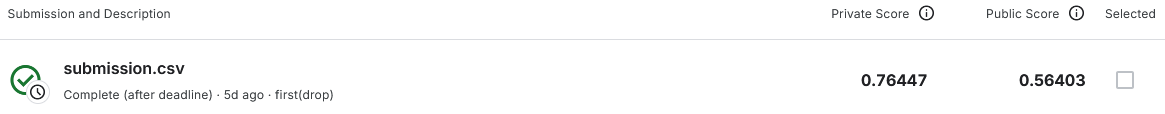

**Sub 2**

 В лучшенной версии добавлен вывод последних строк для контроля целостности сабмита.

```
# пути передаются переменными в функцию
# ============================================================
# 3. ФОРМИРОВАНИЕ САБМИТА (УЛУЧШЕННАЯ ВЕРСИЯ)
# ============================================================

# 3.1 Распаковываем архив (только сейчас, когда понадобился sample_submission)
#    Архив содержит все файлы M5, но нам нужен только sample_submission.csv
zip_path = DRIVE_BASE + 'm5-forecasting-accuracy.zip'
extract_path = '/content/m5_data'

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(color.GREEN + color.BOLD + f"Распаковка завершена! Файлы в: {extract_path}" + color.END)
except:
    print(color.RED + color.BOLD + f"Ошибка при распаковке архива" + color.END)

# Удаляем ненужные файлы (calendar, sales_train_validation, sell_prices)
# Оставляем только sample_submission.csv, чтобы не занимал место
files_to_delete = [
    '/content/m5_data/calendar.csv',
    '/content/m5_data/sales_train_validation.csv',
    '/content/m5_data/sell_prices.csv'
]

for file_path in files_to_delete:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Удалён: {file_path}")

# 3.2 Собираем test и future предсказания из словаря all_results_up
#    test_predictions_df — предсказания на дни 1914-1941 (validation)
#    future_predictions_recursive — предсказания на дни 1942-1969 (evaluation)
test_preds_list = []
future_preds_list = []

for group, data in all_results_up.items():  # ← all_results_up
    if data.get('status') == 'success':
        test_preds_list.append(data['test_predictions_df'])
        future_preds_list.append(data['future_predictions_recursive'])

# Сшиваем все группы по вертикали в один датафрейм
test_preds_full = pd.concat(test_preds_list, ignore_index=True)
future_preds_full = pd.concat(future_preds_list, ignore_index=True)

# Удаляем дубликаты (если есть) — оставляем уникальные пары (id, d)
# Это необходимо для pivot, который не допускает дублирования индексов
test_preds_full = test_preds_full.drop_duplicates(subset=['id', 'd'], keep='first')
future_preds_full = future_preds_full.drop_duplicates(subset=['id', 'd'], keep='first')

print(color.GREEN + color.BOLD + f"Собрано предсказаний:" + color.END)
print(f"   test (1914-1941): {len(test_preds_full):,}")
print(f"   future (1942-1969): {len(future_preds_full):,}")

# 3.3 Преобразуем формат (id, d, pred) -> (id, F1, F2, ..., F28)
#    Делаем pivot: строки = id, колонки = дни, значения = pred
def format_predictions(preds_df):
    """
    Преобразует предсказания из формата (id, d, pred) в формат сабмита (id, F1...F28)
    """
    pivot = preds_df.pivot(index='id', columns='d', values='pred')
    days = sorted(pivot.columns)
    day_to_f = {d: f'F{i+1}' for i, d in enumerate(days)}
    pivot = pivot.rename(columns=day_to_f)
    return pivot.reset_index()

test_preds_formatted = format_predictions(test_preds_full)
future_preds_formatted = format_predictions(future_preds_full)

# 3.4 Переименовываем id для validation
#    В данных все id заканчиваются на _evaluation
#    Для тестового периода (1914-1941) нужно _validation
test_preds_formatted['id'] = test_preds_formatted['id'].str.replace('_evaluation', '_validation')
# future оставляем _evaluation

# 3.5 Загружаем шаблон сабмита
#    В нём все id товаров и колонки F1-F28 с нулями
sample_submission_path = '/content/m5_data/sample_submission.csv'
sample_submission = pd.read_csv(sample_submission_path)

print(color.BLUE + color.BOLD + f"Загружен шаблон сабмита: {sample_submission.shape}" + color.END)

# 3.6 Заполняем шаблон нашими предсказаниями (быстро, без циклов)
#    Создаём копию шаблона, затем по id вставляем наши значения через map
submission_filled = sample_submission.copy()

# Преобразуем предсказания в формат для быстрого map
test_preds_formatted = test_preds_formatted.set_index('id')
future_preds_formatted = future_preds_formatted.set_index('id')

# Заполняем все колонки F1-F28 через map (векторизовано, быстро)
for col in submission_filled.columns[1:]:  # пропускаем 'id'
    # Берём значения из validation, если есть
    if col in test_preds_formatted.columns:
        submission_filled[col] = submission_filled['id'].map(test_preds_formatted[col]).fillna(submission_filled[col])
    # Берём значения из evaluation, если есть
    if col in future_preds_formatted.columns:
        submission_filled[col] = submission_filled['id'].map(future_preds_formatted[col]).fillna(submission_filled[col])

# 3.7 Сохраняем сабмит в папку STUDY_PATH_UP
submission_path = f'{STUDY_PATH_UP}submission_up.csv'  # ← улучшенная версия
submission_filled.to_csv(submission_path, index=False)

print(color.GREEN + color.BOLD + f"Сабмит сохранён: {submission_path}" + color.END)
print(color.BLUE + color.BOLD + f"Размер: {submission_filled.shape}" + color.END)
print(color.BLUE + color.BOLD + f"Первые строки" + color.END)
display(submission_filled.head(15))
print(color.BLUE + color.BOLD + f"Последние строки" + color.END)
display(submission_filled.tail(5))
```
```
Распаковка завершена! Файлы в: /content/m5_data
Удалён: /content/m5_data/calendar.csv
Удалён: /content/m5_data/sales_train_validation.csv
Удалён: /content/m5_data/sell_prices.csv
Собрано предсказаний:
   test (1914-1941): 853,720
   future (1942-1969): 853,720
Загружен шаблон сабмита: (60980, 29)
Сабмит сохранён: /content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Walmart/m5_study_up/submission_up.csv
Размер: (60980, 29)
```

Sub 2 (без дроп) показала метрики на кагле:
- Private Score 0.78082
- Public Score    0.52523

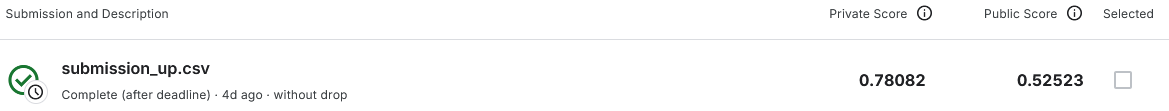

## **Служебный код**

В данном разделе содержится код, способствующий воспроизводимости и подготавливающий проект к выкладке.

Для начала зафиксирую версии использованых библиотек, сохранив в файл requirements, который позже приложу к проекту.

In [6]:
# создаём requirements.txt автоматически
!pip freeze > requirements.txt

print(color.GREEN + color.BOLD + f"V Файл requirements.txt создан!"+ color.END)

V Файл requirements.txt создан!


Так как ГитХаб бывает капризен, почищу ноутбук от различных метаданных для того, чтобы не было проблем с отображением проекта в репозитории.

In [ ]:
# Создаем чистую версию ноутбука
import json
from google.colab import _message

# Получаем текущее содержимое ноутбука
notebook_content = _message.blocking_request('get_ipynb', request='', timeout_sec=120)

# Очищаем метаданные
if 'metadata' in notebook_content['ipynb']:
    if 'widgets' in notebook_content['ipynb']['metadata']:
        del notebook_content['ipynb']['metadata']['widgets']

# Сохраняем очищенную версию
with open('/content/cleaned_notebook.ipynb', 'w') as f:
    json.dump(notebook_content['ipynb'], f, indent=2)

print("Готово! Скачайте файл '/content/cleaned_notebook.ipynb'")


Теперь проект готов к демонстрации.